In [7]:
import numpy as np

def synced_percentage(n, density, modal_damping):
    
    if density < 1:
        n_prime = 10.8 * np.sqrt(n * modal_damping)
    else:
        n_prime = 1.85 * np.sqrt(n)

    percent = (n_prime / n) * 100
    
    return n_prime, percent


# Example
n = 100
density = 1
modal_damping = 0.005

n_prime, percent = synced_percentage(n, density, modal_damping)

print(f"n' = {n_prime:.2f}")
print(f"Synchronized percentage = {percent:.2f}%")


n' = 18.50
Synchronized percentage = 18.50%


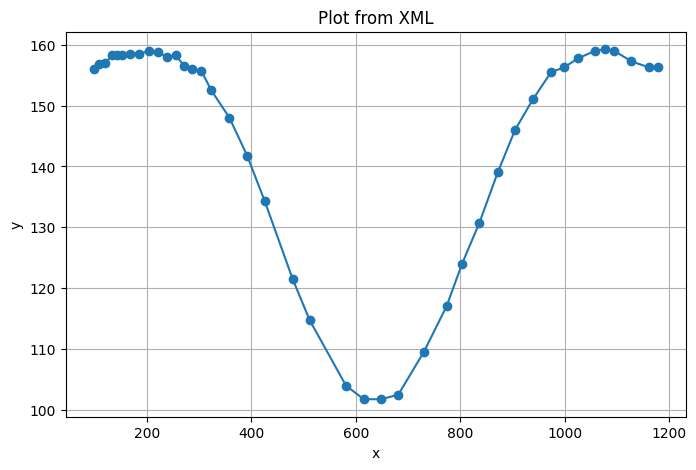

In [11]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

xml_file = "eeklo2.xml"

tree = ET.parse(xml_file)
root = tree.getroot()

x_vals = []
y_vals = []

for point in root.findall(".//point"):
    x = float(point.get("x"))
    y = float(point.get("y"))
    x_vals.append(x)
    y_vals.append(y)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, marker="o")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Plot from XML")
plt.grid(True)
plt.show()

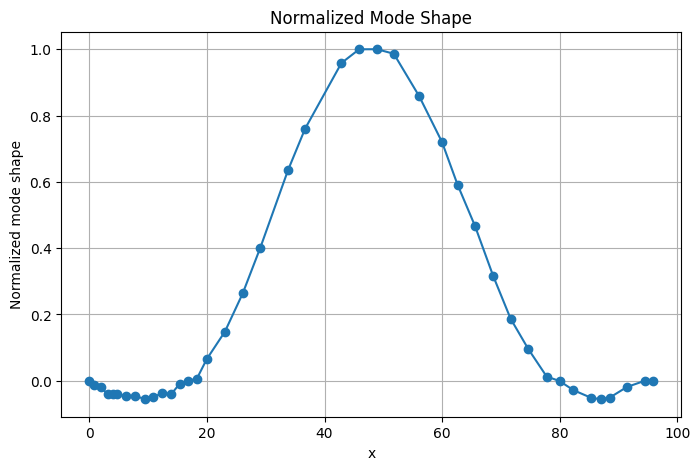

0.000, 0.000000
0.778, -0.013755
1.889, -0.018299
3.134, -0.041227
3.934, -0.041189
4.690, -0.041153
6.201, -0.045678
7.713, -0.045605
9.380, -0.054720
10.869, -0.050051
12.403, -0.036185
13.892, -0.040711
15.381, -0.008458
16.759, 0.000803
18.249, 0.005472
19.960, 0.065322
23.050, 0.148225
26.072, 0.263307
29.073, 0.401375
33.807, 0.636074
36.697, 0.760345
42.876, 0.958333
45.898, 0.999855
48.921, 1.000000
51.789, 0.986345
56.123, 0.857823
59.991, 0.720084
62.636, 0.591481
65.592, 0.467490
68.704, 0.315923
71.661, 0.187335
74.684, 0.095530
77.796, 0.012924
79.996, -0.000763
82.352, -0.028235
85.331, -0.051080
86.976, -0.055598
88.509, -0.050927
91.466, -0.018603
94.489, -0.000068
95.911, 0.000000


In [13]:
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt

xml_file = "eeklo2.xml"

tree = ET.parse(xml_file)
root = tree.getroot()

dx_vals = []
dy_vals = []

for point in root.findall(".//point"):
    dx_vals.append(float(point.get("dx")))
    dy_vals.append(float(point.get("dy")))

x = np.array(dx_vals)
y = np.array(dy_vals)

# -------------------------
# 1. Shift x so it starts at 0
# -------------------------
x_norm = x - x[0]

# -------------------------
# 2. Remove straight baseline between first and last point
#    so curve starts at y=0 and ends at y=0
# -------------------------
baseline = y[0] + (y[-1] - y[0]) * (x - x[0]) / (x[-1] - x[0])
y_shifted = y - baseline

# -------------------------
# 3. Scale y so maximum absolute value becomes 1
# -------------------------
y_norm = y_shifted / np.max(np.abs(y_shifted))

# If you want the peak to be +1 instead of -1, flip sign if needed
if np.max(y_norm) < abs(np.min(y_norm)):
    y_norm = -y_norm

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(x_norm, y_norm, marker='o')
plt.xlabel("x")
plt.ylabel("Normalized mode shape")
plt.title("Normalized Mode Shape")
plt.grid(True)
plt.show()

# Optional: print values
for xi, yi in zip(x_norm, y_norm):
    print(f"{xi:.3f}, {yi:.6f}")

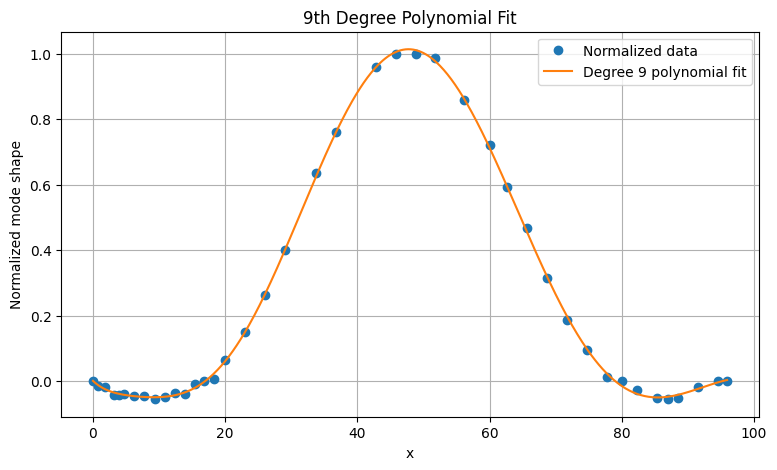

Polynomial coefficients (highest degree first):
[-8.02321495e-16  4.32499733e-13 -9.53553597e-11  1.09530960e-08
 -6.90120316e-07  2.30469265e-05 -3.76429912e-04  3.46209330e-03
 -1.90877156e-02  3.95334984e-04]

Polynomial equation:
            9             8             7             6             5
-8.023e-16 x + 4.325e-13 x - 9.536e-11 x + 1.095e-08 x - 6.901e-07 x
              4             3            2
 + 2.305e-05 x - 0.0003764 x + 0.003462 x - 0.01909 x + 0.0003953


In [17]:
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt

xml_file = "eeklo2.xml"

# -------------------------
# Read XML
# -------------------------
tree = ET.parse(xml_file)
root = tree.getroot()

dx_vals = []
dy_vals = []

for point in root.findall(".//point"):
    dx_vals.append(float(point.get("dx")))
    dy_vals.append(float(point.get("dy")))

x = np.array(dx_vals)
y = np.array(dy_vals)

# -------------------------
# Normalize
# -------------------------
x_norm = x - x[0]

baseline = y[0] + (y[-1] - y[0]) * (x - x[0]) / (x[-1] - x[0])
y_shifted = y - baseline
y_norm = y_shifted / np.max(np.abs(y_shifted))

# Flip sign if you want the main peak upward
if np.max(y_norm) < abs(np.min(y_norm)):
    y_norm = -y_norm

# -------------------------
# Polynomial fit (degree 9)
# -------------------------
degree = 9
coeffs = np.polyfit(x_norm, y_norm, degree)
poly = np.poly1d(coeffs)

# Smooth curve for plotting
x_fit = np.linspace(x_norm.min(), x_norm.max(), 500)
y_fit = poly(x_fit)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(9, 5))
plt.plot(x_norm, y_norm, 'o', label='Normalized data')
plt.plot(x_fit, y_fit, '-', label=f'Degree {degree} polynomial fit')
plt.xlabel("x")
plt.ylabel("Normalized mode shape")
plt.title("9th Degree Polynomial Fit")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------
# Print polynomial
# -------------------------
print("Polynomial coefficients (highest degree first):")
print(coeffs)

print("\nPolynomial equation:")
print(poly)

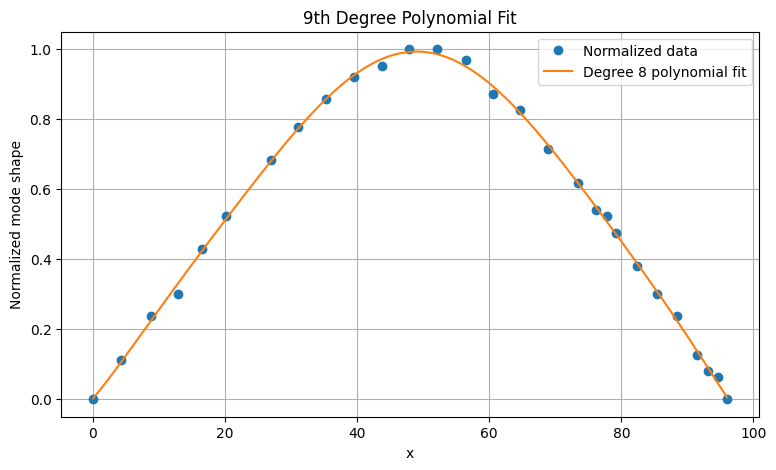

Polynomial coefficients (highest degree first):
[ 1.71144429e-14 -6.76029672e-12  1.05320380e-09 -8.14053964e-08
  3.27033830e-06 -7.15713216e-05  7.95784053e-04  2.20681765e-02
  2.26628021e-03]

Polynomial equation:
           8            7             6             5            4
1.711e-14 x - 6.76e-12 x + 1.053e-09 x - 8.141e-08 x + 3.27e-06 x
              3             2
 - 7.157e-05 x + 0.0007958 x + 0.02207 x + 0.002266


In [22]:
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt

xml_file = "eeklo1.xml"

# -------------------------
# Read XML
# -------------------------
tree = ET.parse(xml_file)
root = tree.getroot()

dx_vals = []
dy_vals = []

for point in root.findall(".//point"):
    dx_vals.append(float(point.get("dx")))
    dy_vals.append(float(point.get("dy")))

x = np.array(dx_vals)
y = np.array(dy_vals)

# -------------------------
# Normalize
# -------------------------
x_norm = x - x[0]

baseline = y[0] + (y[-1] - y[0]) * (x - x[0]) / (x[-1] - x[0])
y_shifted = y - baseline
y_norm = y_shifted / np.max(np.abs(y_shifted))

# Flip sign if you want the main peak upward
if np.max(y_norm) < abs(np.min(y_norm)):
    y_norm = -y_norm

# -------------------------
# Polynomial fit (degree 9)
# -------------------------
degree = 8
coeffs = np.polyfit(x_norm, y_norm, degree)
poly = np.poly1d(coeffs)

# Smooth curve for plotting
x_fit = np.linspace(x_norm.min(), x_norm.max(), 500)
y_fit = poly(x_fit)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(9, 5))
plt.plot(x_norm, y_norm, 'o', label='Normalized data')
plt.plot(x_fit, y_fit, '-', label=f'Degree {degree} polynomial fit')
plt.xlabel("x")
plt.ylabel("Normalized mode shape")
plt.title("9th Degree Polynomial Fit")
plt.grid(True)
plt.legend()
plt.show()

# -------------------------
# Print polynomial
# -------------------------
print("Polynomial coefficients (highest degree first):")
print(coeffs)

print("\nPolynomial equation:")
print(poly)

Elapsed time = 22.1599 s
Average per series = 0.2216 s
all_forces_sum shape = (100, 10000)


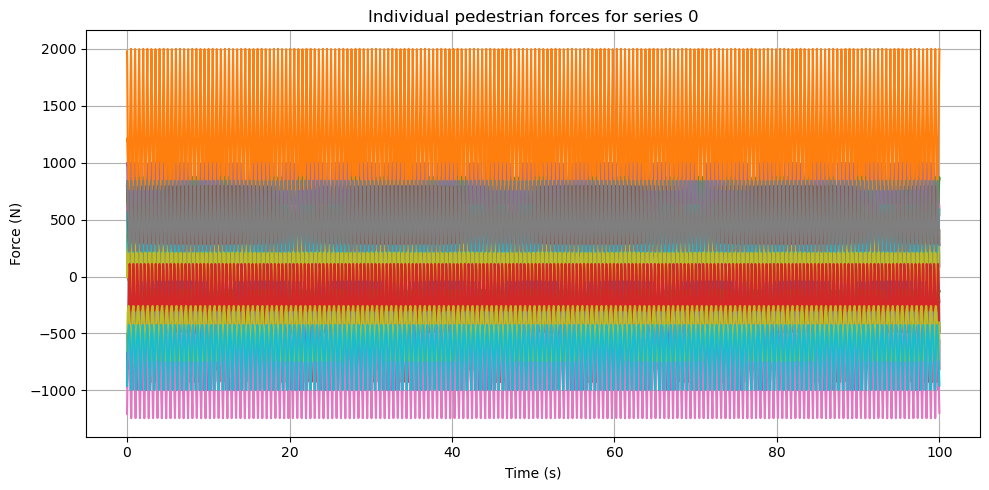

In [3]:
import numpy as np
import time
from pedestrian import Pedestrian, calcPedForce
import matplotlib.pyplot as plt


# -----------------------------
# USER SETTINGS
# -----------------------------
NUM_SERIES = 100       # number of force time series
T_TOTAL = 100.0        # seconds
dt = 0.01              # time step
numped = 20            # number of pedestrians

# -----------------------------
# TIME VECTOR
# -----------------------------
t = np.arange(0, T_TOTAL, dt)
nt = len(t)

# -----------------------------
# EXAMPLE PEDESTRIAN INPUTS
# replace these with your real values if needed
# -----------------------------
# --- random inputs ---
# mass: lognormal with mean = 73.85, sd = 15
mass_mean = 73.85
mass_sd   = 15.0

# convert desired mean/sd of X to underlying normal parameters of ln(X)
sigma_ln = np.sqrt(np.log(1 + (mass_sd**2 / mass_mean**2)))
mu_ln    = np.log(mass_mean) - 0.5 * sigma_ln**2

mass = np.random.lognormal(mean=mu_ln, sigma=sigma_ln, size=numped)

# pace: normal with mean = 2, sd = 0.18
pace = np.random.normal(loc=2.0, scale=0.18, size=numped)

# phase: uniform on [0, 2pi)
phase = np.random.uniform(0.0, 2.0 * np.pi, size=numped)

# dummy values for other Pedestrian args if required by your class
# adjust according to your Pedestrian class definition
velocity = np.ones(numped)
location = np.zeros(numped)
damp = np.zeros(numped)
stiff = np.zeros(numped)

# -----------------------------
# CREATE PEDESTRIAN OBJECT
# -----------------------------

case_pedestrian = Pedestrian(
        mass     = mass,
        damp     = damp,
        stiff    = stiff,
        pace     = pace,
        phase    = phase,
        location = location,
        velocity = velocity,
        iSync    = 0.3
    )
# -----------------------------
# STORAGE
# total force only
# shape = (NUM_SERIES, nt)
# -----------------------------
all_forces_sum = np.zeros((NUM_SERIES, nt))

# -----------------------------
# TIMING + GENERATION
# -----------------------------
start = time.perf_counter()

for i in range(NUM_SERIES):
    case_pedestrian.phase = 2 * np.pi * np.random.rand(numped)

    for j, tj in enumerate(t):
        all_forces_sum[i, j] = np.sum(calcPedForce(case_pedestrian, tj))

end = time.perf_counter()
elapsed = end - start

print(f"Elapsed time = {elapsed:.4f} s")
print(f"Average per series = {elapsed / NUM_SERIES:.4f} s")
print("all_forces_sum shape =", all_forces_sum.shape)

all_forces = np.zeros((NUM_SERIES, nt, numped))

for i in range(NUM_SERIES):
    case_pedestrian.phase = 2 * np.pi * np.random.rand(numped)

    for j, tj in enumerate(t):
        all_forces[i, j, :] = calcPedForce(case_pedestrian, tj)

# plot pedestrians from series 0
plt.figure(figsize=(10, 5))
for p in range(numped):
    plt.plot(t, all_forces[0, :, p], label=f"Ped {p+1}")

plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.title("Individual pedestrian forces for series 0")
plt.grid(True)
plt.tight_layout()
plt.show()

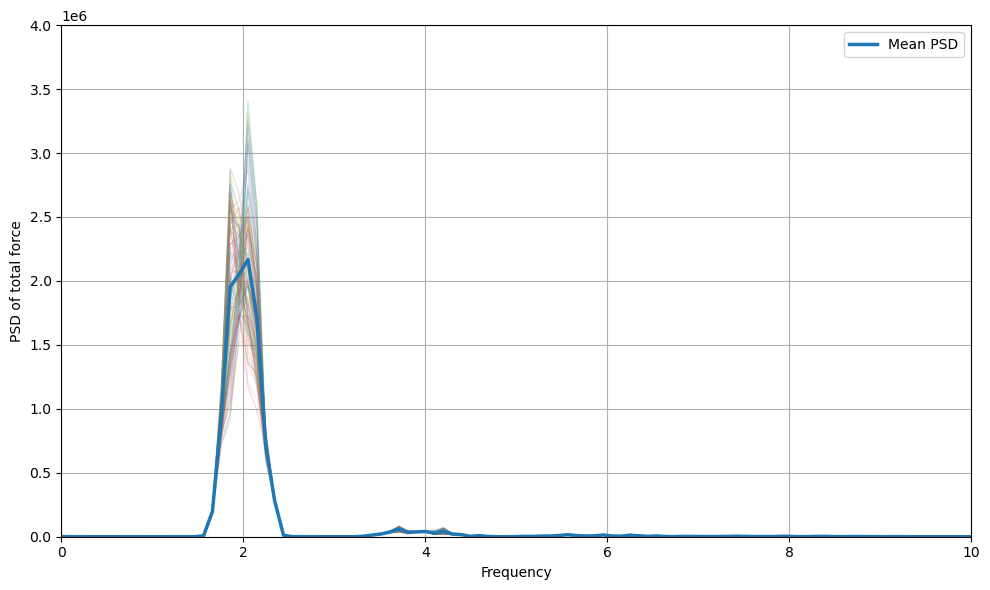

In [37]:
from scipy.signal import welch
# -----------------------------
# PSD of the 100 total force time histories
# -----------------------------
fs = 1.0 / dt
nperseg = min(1024, nt)

psd_all = []
freqs = None

for i in range(NUM_SERIES):
    f, Pxx = welch(
        all_forces_sum[i],
        fs=fs,
        nperseg=nperseg,
        detrend='constant'
    )
    psd_all.append(Pxx)

psd_all = np.array(psd_all)      # shape: (NUM_SERIES, n_freq)
mean_psd = np.mean(psd_all, axis=0)

# plot all PSDs + mean PSD
plt.figure(figsize=(10, 6))
for i in range(NUM_SERIES):
    plt.plot(f, psd_all[i], alpha=0.2, linewidth=0.8)

# vertical lines for actual frequencies 2, 4, 6 Hz
#freq_marks = np.array([1.0, 1.7, 2.1, 2.6, 5.0])
#x_marks = 3.1 / freq_marks

#for fm, xm in zip(freq_marks, x_marks):
#    plt.axvline(x=xm, linestyle='--', linewidth=1.2)
#    plt.text(xm, 1e8, f"{fm:g} Hz", rotation=90,
#             va='top', ha='center')
    
plt.plot(f, mean_psd, linewidth=2.5, label="Mean PSD")
plt.xlabel("Frequency")
plt.xlim(0,10)
plt.ylim(0, 0.4e7)
plt.ylabel("PSD of total force")
#plt.title("PSD of 100 total force time histories")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\slok0019\AppData\Local\Temp\ipykernel_31728\645975543.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.semilogy(3.1/f, psd_all[i], alpha=0.2, linewidth=0.8)
C:\Users\slok0019\AppData\Local\Temp\ipykernel_31728\645975543.py:13: RuntimeWarning: divide by zero encountered in divide
  plt.semilogy(3.1/f, mean_psd, linewidth=2.5, label="Mean PSD")


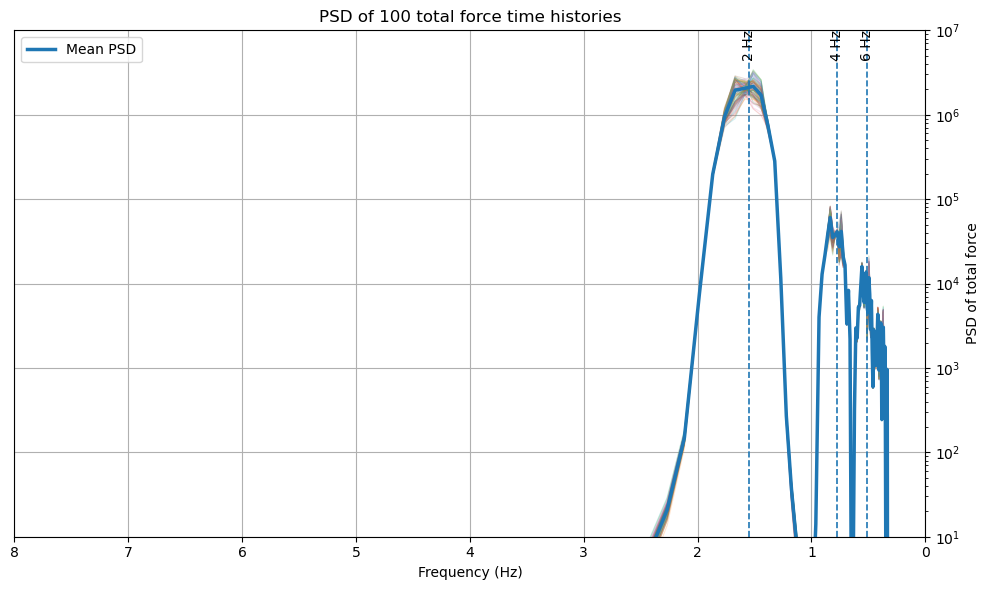

In [26]:
plt.figure(figsize=(10, 6))
for i in range(NUM_SERIES):
    plt.semilogy(3.1/f, psd_all[i], alpha=0.2, linewidth=0.8)

# vertical lines for actual frequencies 2, 4, 6 Hz
freq_marks = np.array([2.0, 4.0, 6.0])
x_marks = 3.1 / freq_marks

for fm, xm in zip(freq_marks, x_marks):
    plt.axvline(x=xm, linestyle='--', linewidth=1.2)
    plt.text(xm, 1e7, f"{fm:g} Hz", rotation=90,
             va='top', ha='center')
plt.semilogy(3.1/f, mean_psd, linewidth=2.5, label="Mean PSD")
plt.xlabel("Frequency (Hz)")
plt.xlim(0, 8)
plt.ylim(1e1, 1e7)
plt.ylabel("PSD of total force")
plt.title("PSD of 100 total force time histories")
plt.grid(True)
plt.legend()

ax = plt.gca()

# y-axis on the right
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

# x-axis start from right side
ax.invert_xaxis()

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import math

def generate_uniform_crowd_xrb(length, width, density, ny=None):
    """
    Generate longitudinal xrb positions for a uniform 2D crowd layout.

    Parameters
    ----------
    length : float
        Bridge length (m)
    width : float
        Bridge width (m)
    density : float
        Crowd density (ped/m^2)
    ny : int or None
        Number of pedestrians across the width.
        If None, chosen automatically.

    Returns
    -------
    xrb : ndarray
        Longitudinal coordinates of all pedestrians
    yrb : ndarray
        Transverse coordinates of all pedestrians
    numped : int
        Total number of pedestrians
    """
    numped = int(round(density * length * width))

    if numped == 0:
        return np.array([]), np.array([]), 0

    if ny is None:
        ny = max(1, int(round(width / 1.0)))   # about 1 m lane spacing

    nx = int(math.ceil(numped / ny))

    x = np.linspace(length/(2*nx), length - length/(2*nx), nx)
    y = np.linspace(width/(2*ny), width - width/(2*ny), ny)

    X, Y = np.meshgrid(x, y)

    xrb = X.ravel()[:numped]
    yrb = Y.ravel()[:numped]

    return xrb, yrb, numped


length = 50
width = 2
density = 0.5

xrb, yrb, numped = generate_uniform_crowd_xrb(length, width, density)

print("numped =", numped)
print("xrb shape =", xrb.shape)
print("first 10 xrb =", xrb)
print("first 10 yrb =", yrb)

numped = 50
xrb shape = (50,)
first 10 xrb = [ 1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21. 23. 25. 27. 29. 31. 33. 35.
 37. 39. 41. 43. 45. 47. 49.  1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21.
 23. 25. 27. 29. 31. 33. 35. 37. 39. 41. 43. 45. 47. 49.]
first 10 yrb = [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5
 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5 1.5]


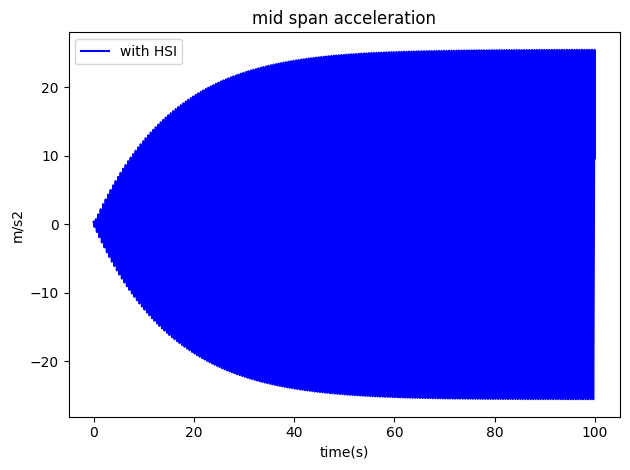

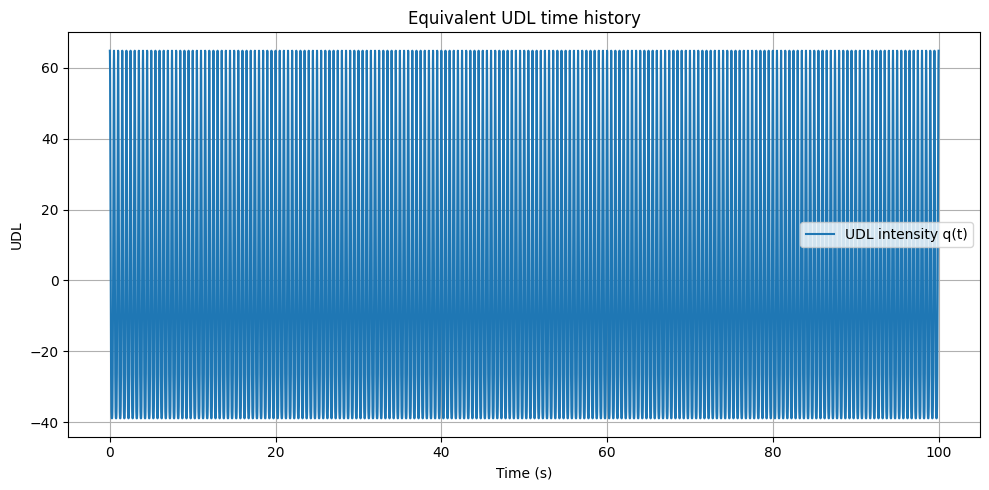

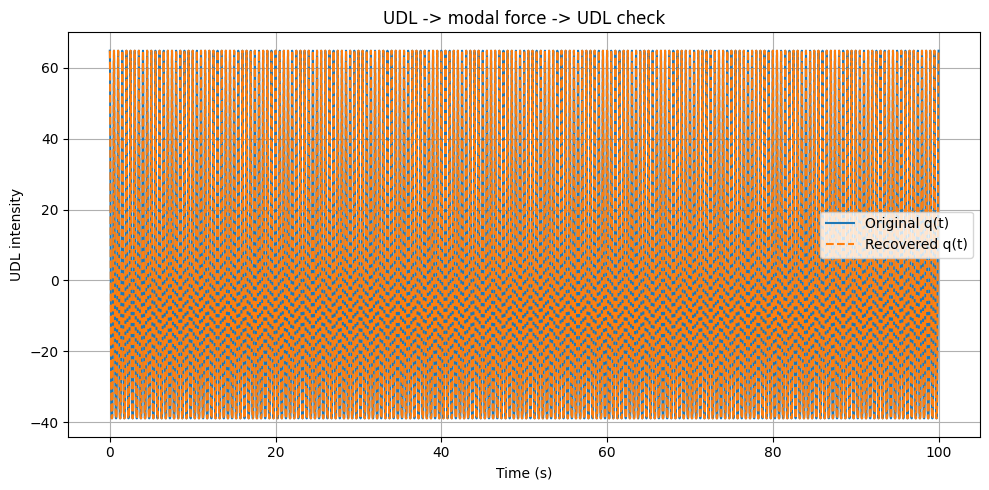

max abs error = 1.331368562773605e-05
mean abs error = 6.981935001993172e-06


In [26]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import math
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq = np.array([2,8])  #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2



numbers = 2 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

ModalMass = linearMass*length/2


def curve1(x):
    return np.sin(np.pi*x/length)

def curve2(x):
    return np.sin(2*np.pi*x/length)

hht = 0.01
t_end = 100 
func_list=[curve1,curve2] 
modalmass = [ModalMass,ModalMass]
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12


Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,
    freq = beamFreq,
      )                   #modes


         
density = 1.0

t, u, du, ddu = Newmarksuper_Code(
    Bridge,
    numbers,
    length,
    hht,
    t_end,
    width,
    beamFreq,        # walking frequency fs
    density,            # density ped/m²
    modalDampingRatio,
    density*length*width,
    length * width, # deck area S
    modalmass,
    func_list
)
accn_hsi = accdyn_super_social(Bridge,ddu ,x_interested,modalmass,func_list)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


plt.plot(t,accn_hsi,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
plt.tight_layout()
#plt.savefig("All In one", format='pdf', dpi=300)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)'''

import numpy as np
import matplotlib.pyplot as plt
from pedestrian import force_2harm

# time vector
t = np.arange(0, t_end + hht, hht)

# UDL intensity q(t)
# units depend on your convention inside force_2harm, then multiplied by width later
q_t = np.array([force_2harm(ti, beamFreq[0], density, modalDampingRatio, length*width)
                for ti in t])

plt.figure(figsize=(10, 5))
plt.plot(t, q_t, label="UDL intensity q(t)")
plt.xlabel("Time (s)")
plt.ylabel("UDL")
plt.title("Equivalent UDL time history")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# original UDL history
q_t = np.array([
    force_2harm(ti, beamFreq[0], density, modalDampingRatio, length*width)
    for ti in t
])

# modal force history from UDL
Q1_t = np.array([
    modal_force_from_udl_2harm(
        ti,
        width,
        beamFreq[0],
        density,
        modalDampingRatio,
        None,
        length * width,
        length,
        [ModalMass],
        [curve1]
    )[0, 0]
    for ti in t
])

# back-convert
alpha_udl, _ = quad(curve1, 0.0, length)
Q1_t_raw = np.sqrt(ModalMass) * Q1_t
q_back = Q1_t_raw / (width * alpha_udl)

# compare
plt.figure(figsize=(10, 5))
plt.plot(t, q_t, label="Original q(t)")
plt.plot(t, q_back, "--", label="Recovered q(t)")
plt.xlabel("Time (s)")
plt.ylabel("UDL intensity")
plt.title("UDL -> modal force -> UDL check")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("max abs error =", np.max(np.abs(q_t - q_back)))
print("mean abs error =", np.mean(np.abs(q_t - q_back)))

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

ModalMass= modal_mass

# original UDL history
q_t = np.array([
    force_2harm(ti, beamFreq[0], density, modalDampingRatio, length*width)
    for ti in t
])

# modal force history from UDL
Q1_t = np.array([
    modal_force_from_udl_2harm(
        ti,
        width,
        beamFreq[0],
        density,
        modalDampingRatio,
        None,
        length * width,
        length,
        [modal_mass],
        [curve1]
    )[0, 0]
    for ti in t
])

# back-convert
alpha_udl, _ = quad(curve1, 0.0, length)
Q1_t_raw = np.sqrt(modal_mass) * Q1_t
q_back = Q1_t_raw / (width * alpha_udl)

# compare
plt.figure(figsize=(10, 5))
plt.plot(t, q_t, label="Original q(t)")
plt.plot(t, q_back, "--", label="Recovered q(t)")
plt.xlabel("Time (s)")
plt.ylabel("UDL intensity")
plt.title("UDL -> modal force -> UDL check")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("max abs error =", np.max(np.abs(q_t - q_back)))
print("mean abs error =", np.mean(np.abs(q_t - q_back)))

NameError: name 'modal_mass' is not defined

In [2]:
import numpy as np
from scipy.interpolate import interp1d

# given data
x = np.array([0.1, 0.2, 0.5, 0.8, 1.0], dtype=float)
y = np.array([0.03, 0.06, 0.15, 0.24, 0.30], dtype=float)

# y values where you want corresponding x values
y_target = np.array([0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30], dtype=float)

# interpolate x as a function of y
f = interp1d(y, x, kind='linear', fill_value='extrapolate')

# get interpolated/extrapolated x values
x_target = f(y_target)

# print results
for yt, xt in zip(y_target, x_target):
    print(f"y = {yt:.2f}  -->  x = {xt:.4f}")

y = 0.01  -->  x = 0.0333
y = 0.05  -->  x = 0.1667
y = 0.10  -->  x = 0.3333
y = 0.15  -->  x = 0.5000
y = 0.20  -->  x = 0.6667
y = 0.25  -->  x = 0.8333
y = 0.30  -->  x = 1.0000


In [7]:
from codeprediction import build_force_factor_model_from_pickle


pkl_path = "force_factors_final2.pkl"

# build factors + interpolation model
factors_all, model = build_force_factor_model_from_pickle(
    pkl_path,
    factor_key="factor_rms",
    invert=True,
    mass_ratio_round=3
)

# ongoing case
bridge_frequency_input = 2.0
mass_ratio_input = 0.0566

# interpolate
x_query, y_query = model["query"](bridge_frequency_input, mass_ratio_input)

print(f"Normalized x = {x_query:.4f}")
print(f"Interpolated force modification factor = {y_query:.4f}")

bf=0.100, density=0.0333, mass_ratio=0.008862, RMS=1.3368
bf=0.100, density=0.1667, mass_ratio=0.052994, RMS=1.4202
bf=0.100, density=0.3333, mass_ratio=0.100386, RMS=1.2957
bf=0.100, density=0.5000, mass_ratio=0.147700, RMS=1.3628
bf=0.100, density=0.6667, mass_ratio=0.200859, RMS=1.2796
bf=0.100, density=0.8333, mass_ratio=0.248128, RMS=1.7695
bf=0.100, density=1.0000, mass_ratio=0.295400, RMS=1.2159
bf=0.250, density=0.0333, mass_ratio=0.008862, RMS=1.0081
bf=0.250, density=0.1667, mass_ratio=0.052994, RMS=1.0855
bf=0.250, density=0.3333, mass_ratio=0.100386, RMS=1.0802
bf=0.250, density=0.5000, mass_ratio=0.147700, RMS=1.1103
bf=0.250, density=0.6667, mass_ratio=0.200859, RMS=1.1019
bf=0.250, density=0.8333, mass_ratio=0.248128, RMS=1.1847
bf=0.250, density=1.0000, mass_ratio=0.295400, RMS=1.2713
bf=0.400, density=0.0333, mass_ratio=0.008862, RMS=1.0118
bf=0.400, density=0.1667, mass_ratio=0.052994, RMS=1.0495
bf=0.400, density=0.3333, mass_ratio=0.100386, RMS=1.0618
bf=0.400, dens

In [6]:
import importlib
import codeprediction

print(codeprediction.__file__)

importlib.reload(codeprediction)

factors_all, model = codeprediction.build_force_factor_model_from_pickle(
    "force_factors_final2.pkl",
    factor_key="factor_rms",
    invert=True,
    mass_ratio_round=3
)

\\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\codeprediction.py
bf=0.100, density=0.0333, mass_ratio=0.008862, RMS=1.3368
bf=0.100, density=0.1667, mass_ratio=0.052994, RMS=1.4202
bf=0.100, density=0.3333, mass_ratio=0.100386, RMS=1.2957
bf=0.100, density=0.5000, mass_ratio=0.147700, RMS=1.3628
bf=0.100, density=0.6667, mass_ratio=0.200859, RMS=1.2796
bf=0.100, density=0.8333, mass_ratio=0.248128, RMS=1.7695
bf=0.100, density=1.0000, mass_ratio=0.295400, RMS=1.2159
bf=0.250, density=0.0333, mass_ratio=0.008862, RMS=1.0081
bf=0.250, density=0.1667, mass_ratio=0.052994, RMS=1.0855
bf=0.250, density=0.3333, mass_ratio=0.100386, RMS=1.0802
bf=0.250, density=0.5000, mass_ratio=0.147700, RMS=1.1103
bf=0.250, density=0.6667, mass_ratio=0.200859, RMS=1.1019
bf=0.250, density=0.8333, mass_ratio=0.248128, RMS=1.1847
bf=0.250, density=1.0000, mass_ratio=0.295400, RMS=1.2713
bf=0.400, density=0.0333, mass_ratio=0.008862, RMS=1.0118
bf=0.400, density=0.1667, mass_ratio=0.052994, RMS

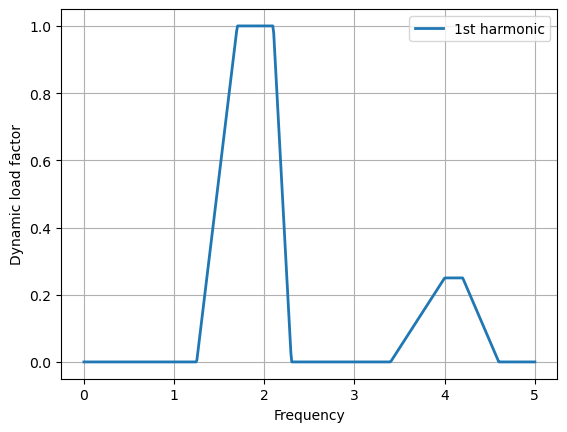

In [8]:
import numpy as np

def psi_h1(f):
    f = np.asarray(f)
    y = np.zeros_like(f, dtype=float)

    mask = (f >= 1.25) & (f < 1.70)
    y[mask] = (f[mask] - 1.25) / (1.70 - 1.25)

    mask = (f >= 1.70) & (f <= 2.10)
    y[mask] = 1.0

    mask = (f > 2.10) & (f <= 2.30)
    y[mask] = (2.30 - f[mask]) / (2.30 - 2.10)

    mask = (f >= 3.40) & (f < 4.00)
    y[mask] = 0.25 * (f[mask] - 3.40) / (4.00 - 3.40)

    mask = (f >= 4.00) & (f <= 4.20)
    y[mask] = 0.25

    mask = (f > 4.20) & (f <= 4.60)
    y[mask] = 0.25 * (4.60 - f[mask]) / (4.60 - 4.20)

    return y


import matplotlib.pyplot as plt

f = np.linspace(0, 5, 500)

plt.plot(f, psi_h1(f), label="1st harmonic", linewidth=2)
#plt.plot(f, psi_h2(f), label="2nd harmonic", linewidth=2)
plt.xlabel("Frequency")
plt.ylabel("Dynamic load factor")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
import numpy as np
from solver import generate_uniform_crowd_xrb

# import your function from wherever it is defined
# from socialforcefunctions import generate_uniform_crowd_xrb

# -----------------------------
# SETTINGS
# -----------------------------
length = 50.0
width = 2.0
density = 0.5
N = 10   # number of repetitions

all_xrb = []
all_yrb = []
all_numped = []

for i in range(N):
    xrb, yrb, numped = generate_uniform_crowd_xrb(length, width, density)

    all_xrb.append(np.array(xrb))
    all_yrb.append(np.array(yrb))
    all_numped.append(numped)

    print(f"\nRun {i+1}")
    print(f"numped = {numped}")
    print(f"xrb = {np.array(xrb)}")

# -----------------------------
# simple checks
# -----------------------------
print("\nSummary of numped over runs:")
print(all_numped)

# compare xrb from consecutive runs
for i in range(1, N):
    same = np.array_equal(all_xrb[0], all_xrb[i])
    print(f"xrb in run 1 == run {i+1}? {same}")


Run 1
numped = 50
xrb = [ 1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21. 23. 25. 27. 29. 31. 33. 35.
 37. 39. 41. 43. 45. 47. 49.  1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21.
 23. 25. 27. 29. 31. 33. 35. 37. 39. 41. 43. 45. 47. 49.]

Run 2
numped = 50
xrb = [ 1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21. 23. 25. 27. 29. 31. 33. 35.
 37. 39. 41. 43. 45. 47. 49.  1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21.
 23. 25. 27. 29. 31. 33. 35. 37. 39. 41. 43. 45. 47. 49.]

Run 3
numped = 50
xrb = [ 1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21. 23. 25. 27. 29. 31. 33. 35.
 37. 39. 41. 43. 45. 47. 49.  1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21.
 23. 25. 27. 29. 31. 33. 35. 37. 39. 41. 43. 45. 47. 49.]

Run 4
numped = 50
xrb = [ 1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21. 23. 25. 27. 29. 31. 33. 35.
 37. 39. 41. 43. 45. 47. 49.  1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21.
 23. 25. 27. 29. 31. 33. 35. 37. 39. 41. 43. 45. 47. 49.]

Run 5
numped = 50
xrb = [ 1.  3.  5.  7.  9. 11. 13. 15. 17. 19. 21. 23. 25. 27. 29

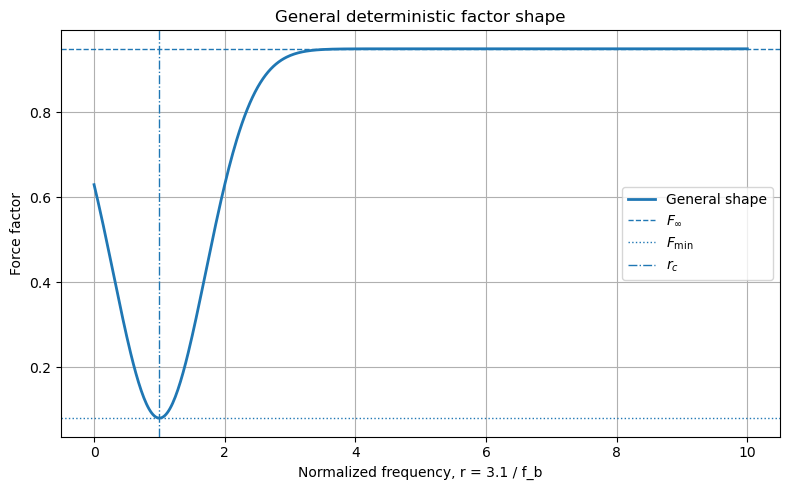

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def factor_shape(r, F_inf, F_min, r_c, width):
    """
    Smooth dip-and-recovery curve.

    Parameters
    ----------
    r : array_like
        Normalized frequency (e.g. 3.1 / f_b)
    F_inf : float
        Plateau value at high normalized frequency
    F_min : float
        Minimum value at the dip
    r_c : float
        Center location of the dip
    width : float
        Controls how wide the dip is

    Returns
    -------
    F : ndarray
        Force factor curve
    """
    r = np.asarray(r, dtype=float)
    F = F_inf - (F_inf - F_min) * np.exp(-((r - r_c) / width)**2)
    return F


# -----------------------------------
# Deterministic parameter values
# -----------------------------------
F_inf = 0.95     # high-frequency limit
F_min = 0.08     # minimum at dip
r_c   = 1.0      # dip near normalized frequency = 1
width = 1     # dip width

# -----------------------------------
# Frequency range
# -----------------------------------
r = np.linspace(0.0, 10.0, 500)

# Calculate factor
F = factor_shape(r, F_inf, F_min, r_c, width)

# -----------------------------------
# Plot
# -----------------------------------
plt.figure(figsize=(8, 5))
plt.plot(r, F, linewidth=2, label="General shape")
plt.axhline(F_inf, linestyle='--', linewidth=1, label=r"$F_\infty$")
plt.axhline(F_min, linestyle=':', linewidth=1, label=r"$F_{\min}$")
plt.axvline(r_c, linestyle='-.', linewidth=1, label=r"$r_c$")

plt.xlabel("Normalized frequency, r = 3.1 / f_b")
plt.ylabel("Force factor")
plt.title("General deterministic factor shape")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
import numpy as np
import torch
import socialforce
import matplotlib.pyplot as plt

# -----------------------------
# basic settings
# -----------------------------
length = 20.0
width = 2.0
hht = 0.05
t = np.arange(0, 10, hht)

# -----------------------------
# initial state: 2 pedestrians
# columns: x, y, vx, vy, ax, ay, dx, dy, tau, preferred_speed
# -----------------------------
initial_state = torch.tensor([
    [2.0, 0.6, 1.0, 0.0, 0.0, 0.0, 30.0, 0.6, 0.5, 1.1],
    [2.0, 1.4, 1.0, 0.0, 0.0, 0.0, 30.0, 1.4, 0.5, 1.1],
], dtype=torch.float32)

# -----------------------------
# corridor walls
# -----------------------------
upper_wall = torch.stack([
    torch.linspace(0, length, 400),
    torch.full((400,), width)
], dim=-1)

lower_wall = torch.stack([
    torch.linspace(0, length, 400),
    torch.zeros(400)
], dim=-1)

# -----------------------------
# moving barrier: short vertical segment
# leaves gaps at top and bottom so people can go around it
# -----------------------------
def make_vertical_barrier(xc, y0=0.5, y1=1.5, n=100):
    return torch.stack([
        torch.full((n,), float(xc)),
        torch.linspace(float(y0), float(y1), n)
    ], dim=-1)

def barrier_x(time):
    # barrier moves left to right slowly
    return 8.0 + 3.0 * np.sin(0.8 * time)

# -----------------------------
# simulator
# -----------------------------
ped_ped = socialforce.potentials.PedPedPotentialDiamond(
    sigma=0.5, asymmetry_angle=-20.0
)

simulator = socialforce.Simulator(
    ped_ped=ped_ped,
    ped_space=None,   # we will update this every step
    delta_t=hht,
    oversampling=1
)

# optional periodic x-boundary
# simulator.integrator = socialforce.simulator.PeriodicBoundary(
#     simulator.integrator, x_boundary=[0, length]
# )

# -----------------------------
# time stepping with moving barrier
# -----------------------------
state = initial_state.clone()
states = [state.clone()]

for tk in t[1:]:
    xb = barrier_x(tk)
    moving_barrier = make_vertical_barrier(xb, y0=0.5, y1=1.5)

    ped_space = socialforce.potentials.PedSpacePotential(
        [upper_wall, lower_wall, moving_barrier]
    )

    simulator.U = ped_space       # update obstacle field
    state = simulator(state)      # one step
    states.append(state.clone())

states = torch.stack(states)  # shape: (nt, nped, nstate)

# -----------------------------
# plot trajectories
# -----------------------------
plt.figure(figsize=(8, 3))

for i in range(states.shape[1]):
    plt.plot(states[:, i, 0].numpy(), states[:, i, 1].numpy(), label=f"ped {i+1}")

# show barrier at a few times
for tk in [0, 3, 6, 9]:
    xb = barrier_x(tk)
    plt.plot([xb, xb], [0.5, 1.5], 'k--', alpha=0.4)

plt.xlim(0, length)
plt.ylim(0, width)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Pedestrians avoiding a moving barrier")
plt.legend()
plt.grid(True)
plt.show()

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

<Figure size 800x300 with 0 Axes>

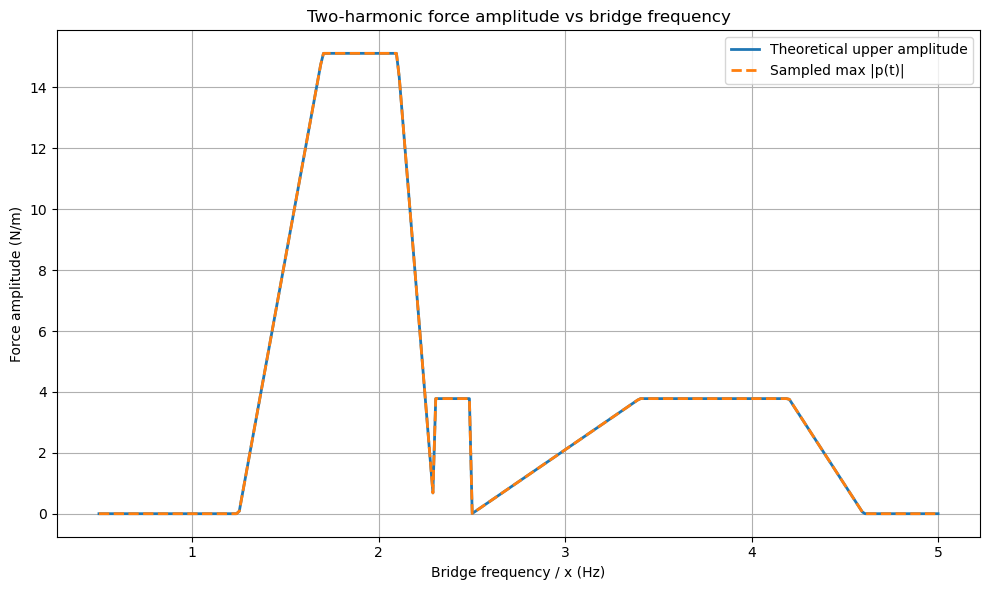

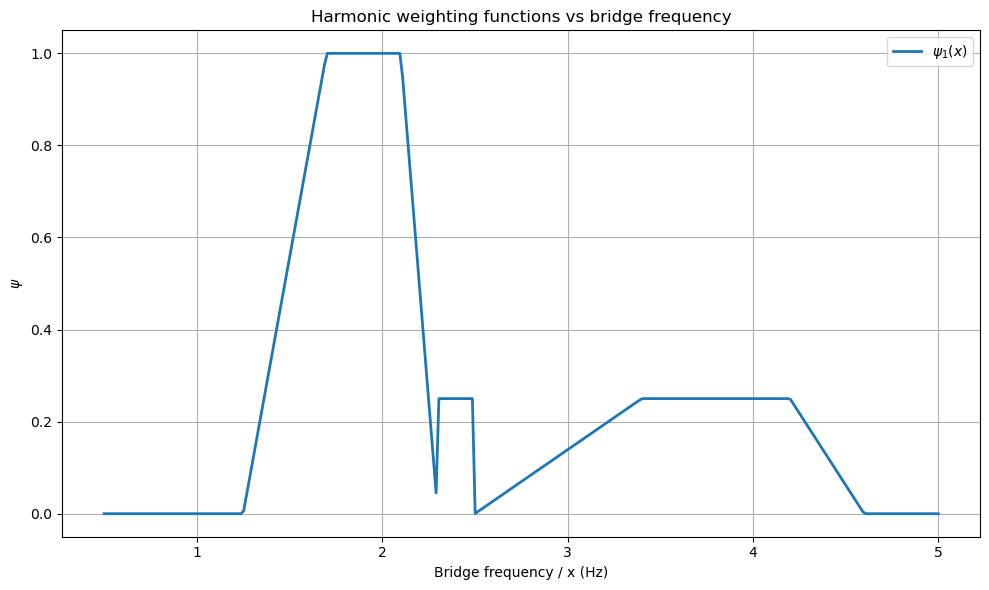

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pedestrian import *
# -------------------------------------------------
# Plot force amplitude from force_2harm
# assuming x = bridge_frequency
# -------------------------------------------------

def plot_force2harm_amplitude_vs_bridge_frequency(
    bridge_frequencies,
    density,
    xi,
    S,
    phase=(0.0, 0.0),
    t_end=10.0,
    dt=0.001
):
    bridge_frequencies = np.asarray(bridge_frequencies, dtype=float)

    # time vector for sampled peak
    t = np.arange(0.0, t_end, dt)

    amp_upper = []     # theoretical upper bound = Pw*n'*(|psi1|+|psi2|)
    amp_sampled = []   # sampled max |p(t)|
    psi1_list = []
    psi2_list = []

    nprime = calc_nprime(density, xi, S)
    pw = 280.0

    for bf in bridge_frequencies:
        x = bf   # <-- if needed, replace this with your walking-frequency model

        psi1 = psi_w_h1(x)
        

        # theoretical maximum possible amplitude
        # since psi1, psi2 are nonnegative in your piecewise functions:
        A_upper = pw * nprime * abs(psi1) 
        # sampled force history
        p_t = np.array([force_2harm(tt, x, density, xi, S, phase=phase) for tt in t])
        A_sampled = np.max(np.abs(p_t))

        amp_upper.append(A_upper)
        amp_sampled.append(A_sampled)
        psi1_list.append(psi1)

    amp_upper = np.array(amp_upper)
    amp_sampled = np.array(amp_sampled)
    psi1_list = np.array(psi1_list)
    psi2_list = np.array(psi2_list)

    # -----------------------------
    # Plot amplitude
    # -----------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(bridge_frequencies, amp_upper, linewidth=2, label="Theoretical upper amplitude")
    plt.plot(bridge_frequencies, amp_sampled, "--", linewidth=2, label="Sampled max |p(t)|")
    plt.xlabel("Bridge frequency / x (Hz)")
    plt.ylabel("Force amplitude (N/m)")
    plt.title("Two-harmonic force amplitude vs bridge frequency")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Plot psi terms too
    # -----------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(bridge_frequencies, psi1_list, linewidth=2, label=r"$\psi_1(x)$")
    #plt.plot(bridge_frequencies, psi2_list, linewidth=2, label=r"$\psi_2(2x)$")
    plt.xlabel("Bridge frequency / x (Hz)")
    plt.ylabel(r"$\psi$")
    plt.title(r"Harmonic weighting functions vs bridge frequency")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "bridge_frequencies": bridge_frequencies,
        "amp_upper": amp_upper,
        "amp_sampled": amp_sampled,
        "psi1": psi1_list,
        "psi2": psi2_list,
    }

bridge_frequencies = np.linspace(0.5, 5.0, 300)

result = plot_force2harm_amplitude_vs_bridge_frequency(
    bridge_frequencies=bridge_frequencies,
    density=0.5,
    xi=0.005,
    S=50 * 2,
    phase=(0.0, 0.0),
    t_end=10.0,
    dt=0.001)

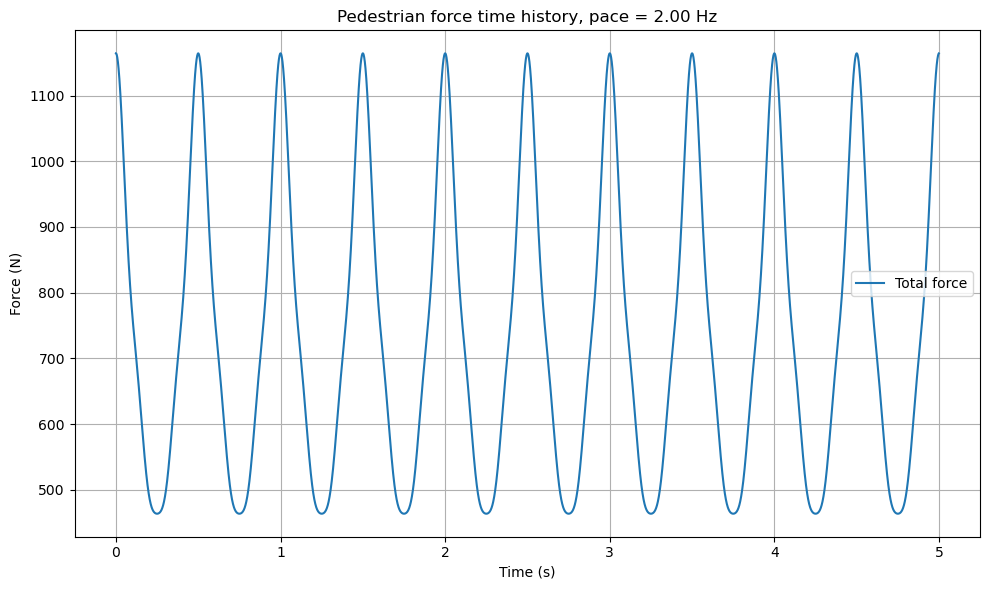

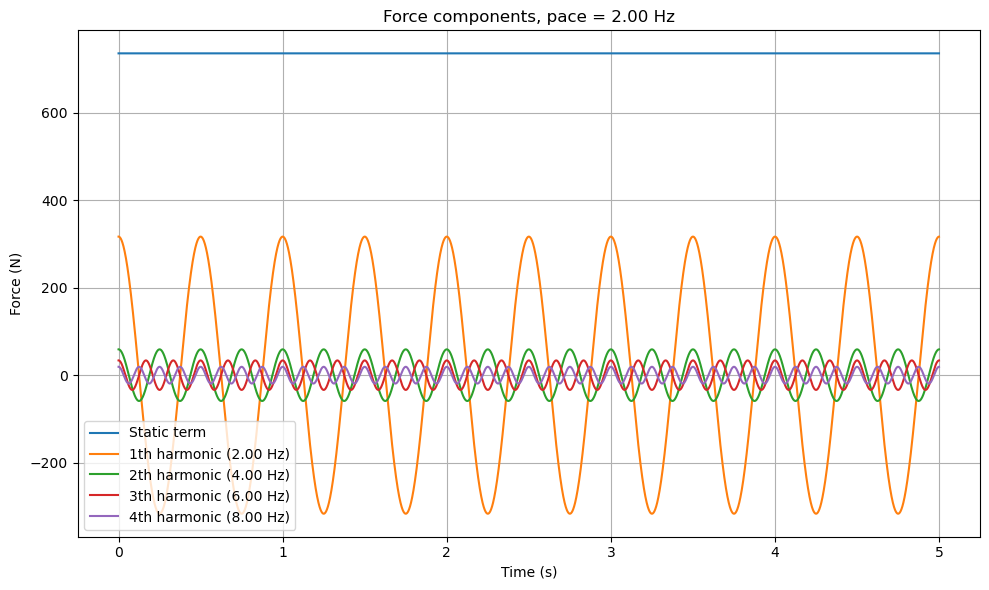

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

def ped_force_time_history(pace, mass=75.0, phase=0.0, t_end=5.0, dt=0.001):
    """
    Time history of the pedestrian force using the same model
    as your calcPedForce function, for one pedestrian.
    """
    g = 9.81
    W = mass * g

    t = np.arange(0.0, t_end, dt)

    # same Young harmonic coefficients
    eta = np.array([
        0.41 * (pace - 0.95),
        0.069 + 0.0056 * pace,
        0.033 + 0.0064 * pace,
        0.013 + 0.0065 * pace
    ], dtype=float)

    # amplitudes: static + 4 harmonics
    F0 = W * np.concatenate(([1.0], eta))

    # frequencies: 0, f, 2f, 3f, 4f
    freqs = pace * np.arange(len(F0), dtype=float)

    # same phase added to all terms, matching your code
    phases = np.full(len(F0), phase, dtype=float)

    # build each component
    components = np.array([
        F0[i] * np.cos(2.0 * np.pi * freqs[i] * t + phases[i])
        for i in range(len(F0))
    ])

    # total force
    Ft = np.sum(components, axis=0)

    return t, Ft, components, freqs, F0


# ---------------------------
# example
# ---------------------------
pace = 2.0      # Hz
mass = 75.0     # kg
phase = 0.0     # rad

t, Ft, components, freqs, amps = ped_force_time_history(
    pace=pace,
    mass=mass,
    phase=phase,
    t_end=5.0,
    dt=0.001
)

# total force
plt.figure(figsize=(10, 6))
plt.plot(t, Ft, label="Total force")
plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.title(f"Pedestrian force time history, pace = {pace:.2f} Hz")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# components
plt.figure(figsize=(10, 6))
for i in range(len(freqs)):
    if i == 0:
        label = "Static term"
    else:
        label = f"{i}th harmonic ({freqs[i]:.2f} Hz)"
    plt.plot(t, components[i], label=label)

plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.title(f"Force components, pace = {pace:.2f} Hz")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Harmonic breakdown:
H1: freq = 2.00 Hz, eta = 0.4305, amplitude = 301.35 N
H2: freq = 4.00 Hz, eta = 0.0802, amplitude = 56.14 N
H3: freq = 6.00 Hz, eta = 0.0458, amplitude = 32.06 N
H4: freq = 8.00 Hz, eta = 0.0260, amplitude = 18.20 N

Total dynamic amplitude upper bound = 407.75 N
Exact total dynamic amplitude        = 407.75 N


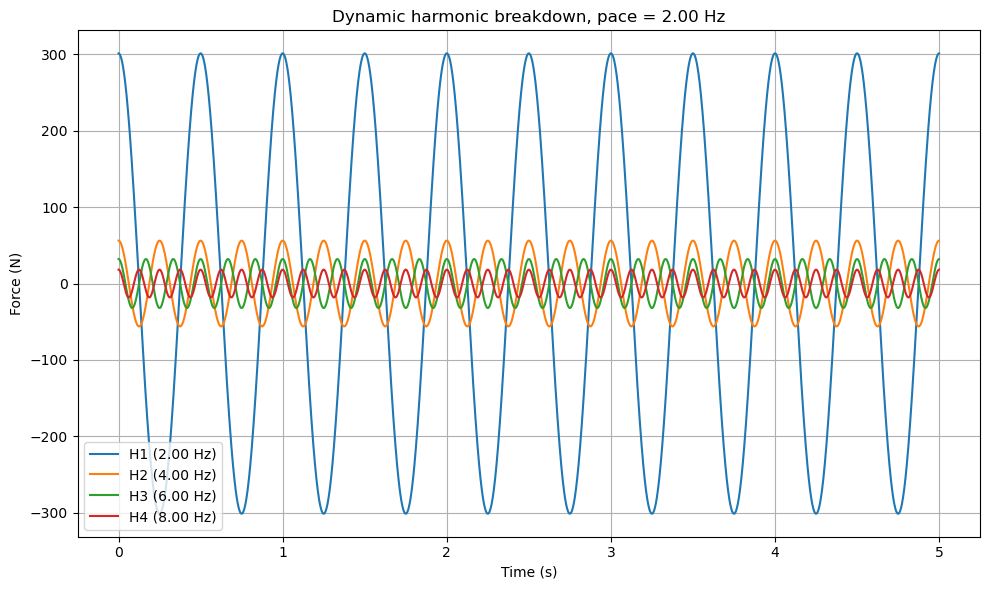

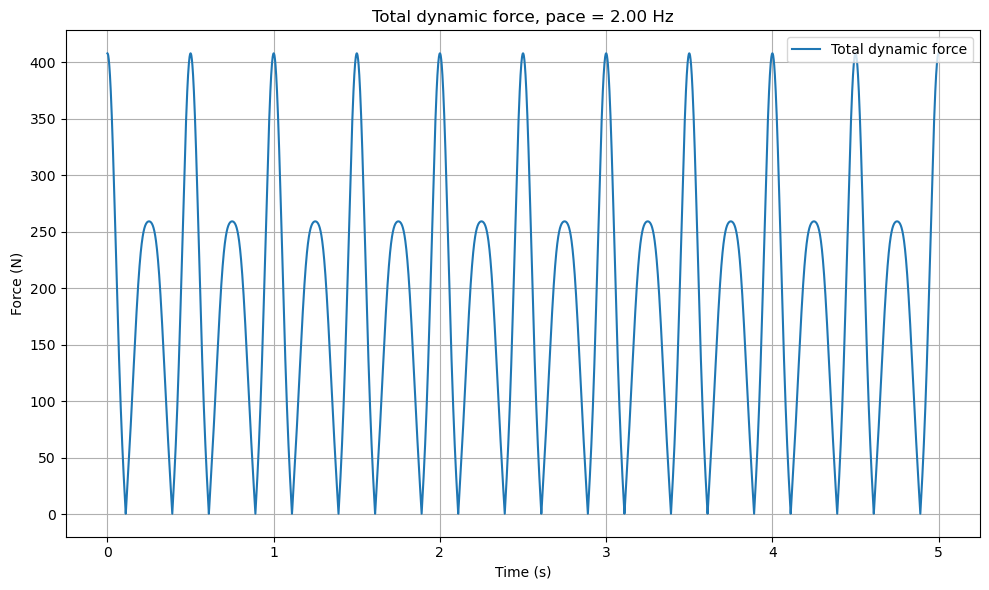

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math

def dynamic_force_breakdown(pace, mass=75.0, phase=0.0, t_end=5.0, dt=0.001):
    g = 9.81
    W = mass * g
    t = np.arange(0.0, t_end, dt)

    # harmonic coefficients
    eta = np.array([
        0.41 * (pace - 0.95),
        0.069 + 0.0056 * pace,
        0.033 + 0.0064 * pace,
        0.013 + 0.0065 * pace
    ], dtype=float)

    harmonics = np.arange(1, 5, dtype=float)   # 1,2,3,4
    freqs = harmonics * pace
    amps = W * eta

    # each dynamic harmonic term
    components = np.array([
        amps[i] * np.cos(2.0 * np.pi * freqs[i] * t + phase)
        for i in range(4)
    ])

    # total dynamic force
    F_dyn = np.sum(components, axis=0)

    # amplitudes
    amp_upper_bound = np.sum(np.abs(amps))
    amp_exact = np.max(np.abs(F_dyn))

    return {
        "t": t,
        "components": components,
        "F_dyn": F_dyn,
        "eta": eta,
        "freqs": freqs,
        "amps": amps,
        "amp_upper_bound": amp_upper_bound,
        "amp_exact": amp_exact
    }


# ---------------- example ----------------
pace = 2.0
mass = 700.0/9.81
phase = 0.0

res = dynamic_force_breakdown(pace=pace, mass=mass, phase=phase, t_end=5.0, dt=0.001)

print("Harmonic breakdown:")
for i in range(4):
    print(f"H{i+1}: freq = {res['freqs'][i]:.2f} Hz, "
          f"eta = {res['eta'][i]:.4f}, "
          f"amplitude = {res['amps'][i]:.2f} N")

print(f"\nTotal dynamic amplitude upper bound = {res['amp_upper_bound']:.2f} N")
print(f"Exact total dynamic amplitude        = {res['amp_exact']:.2f} N")

# plot dynamic harmonic components
plt.figure(figsize=(10, 6))
for i in range(4):
    plt.plot(res["t"], res["components"][i], label=f"H{i+1} ({res['freqs'][i]:.2f} Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.title(f"Dynamic harmonic breakdown, pace = {pace:.2f} Hz")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# plot total dynamic force
plt.figure(figsize=(10, 6))
plt.plot(res["t"], abs(res["F_dyn"]), label="Total dynamic force")
plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.title(f"Total dynamic force, pace = {pace:.2f} Hz")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

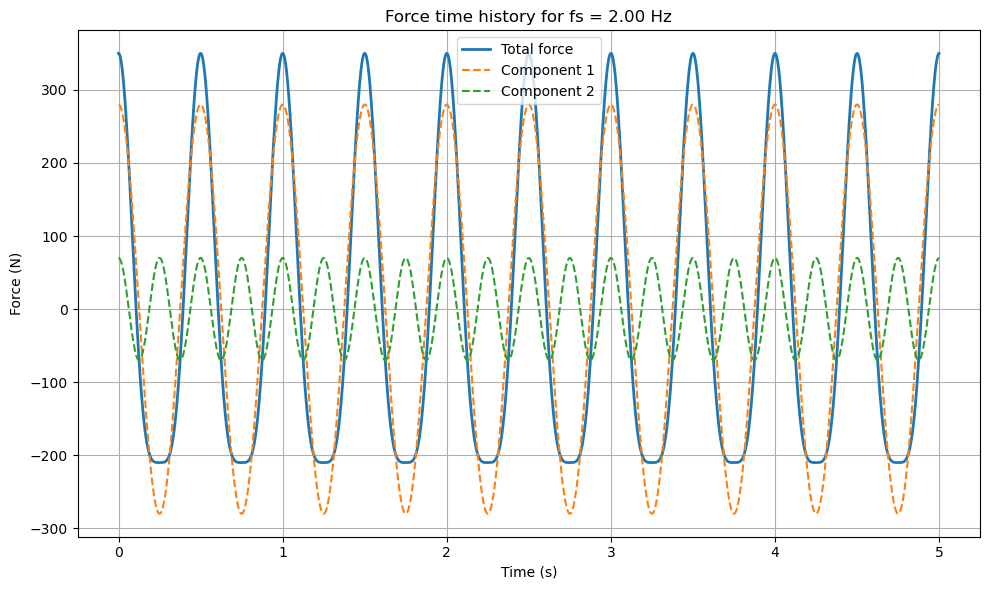

fs = 2.000 Hz
psi(fs/2) = 0.0000
psi(fs)   = 1.0000
psi(2fs)  = 0.2500


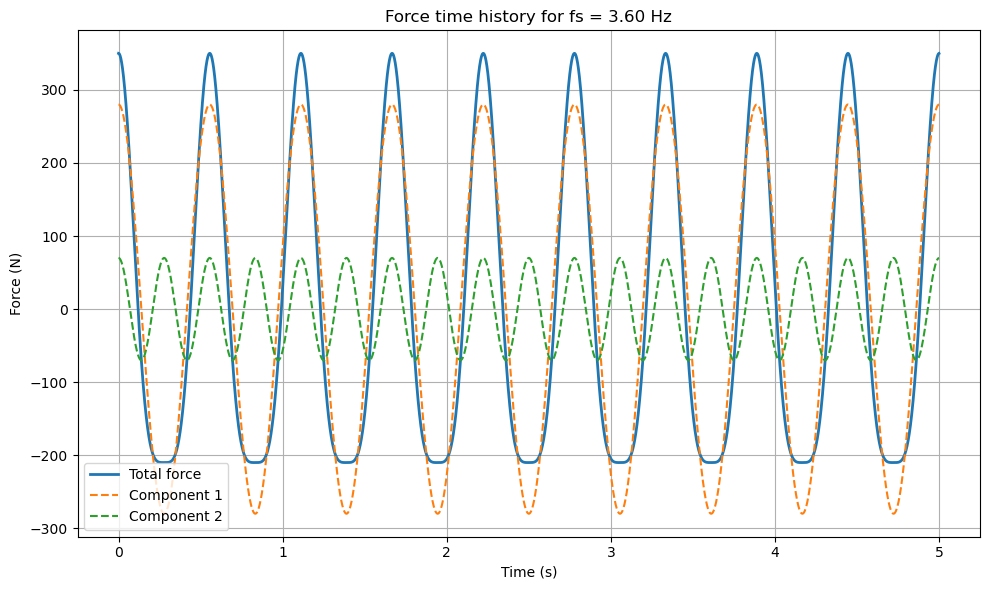

fs = 3.600 Hz
psi(fs/2) = 1.0000
psi(fs)   = 0.2500
psi(2fs)  = 0.0000


In [9]:
import numpy as np
import matplotlib.pyplot as plt

def psi_w(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.30–2.50 : fixed 0.25
    m = (x >= 2.30) & (x <= 2.50)
    psi[m] = 0.25

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    return float(psi) if psi.ndim == 0 else psi


def force_from_given_frequency(t, fs, Pw=280.0):
    """
    Piecewise force model based on the given frequency fs [Hz].

    Case 1: 1.25 < fs < 2.30
        F(t) = 280 cos(2π fs t) * psi(fs)
             + 280 cos(4π fs t) * psi(2 fs)

    Case 2: 2.50 < fs < 4.60
        F(t) = 280 cos(2π (fs/2) t) * psi(fs/2)
             + 280 cos(2π fs t)     * psi(fs)

    Special band: 2.30 <= fs <= 2.50
        I keep the same second expression, which uses psi(fs/2) and psi(fs).
    """
    t = np.asarray(t, dtype=float)
    fs = float(fs)

    if not (1.0 <= fs <= 5.0):
        raise ValueError("fs must be between 1 and 5 Hz.")

    if 1.25 < fs < 2.30:
        comp1 = Pw * np.cos(2.0 * np.pi * fs * t) * psi_w(fs)
        comp2 = Pw * np.cos(4.0 * np.pi * fs * t) * psi_w(2.0 * fs)

    elif 2.30 <= fs <= 4.60:
        comp1 = Pw * np.cos(2.0 * np.pi * (fs / 2.0) * t) * psi_w(fs / 2.0)
        comp2 = Pw * np.cos(2.0 * np.pi * fs * t) * psi_w(fs)

    else:
        comp1 = np.zeros_like(t)
        comp2 = np.zeros_like(t)

    total = comp1 + comp2
    return total, comp1, comp2


def plot_force_from_given_frequency(fs, t_end=5.0, dt=0.001, Pw=280.0):
    t = np.arange(0.0, t_end, dt)
    total, comp1, comp2 = force_from_given_frequency(t, fs, Pw=Pw)

    plt.figure(figsize=(10, 6))
    plt.plot(t, total, label="Total force", linewidth=2)
    plt.plot(t, comp1, "--", label="Component 1")
    plt.plot(t, comp2, "--", label="Component 2")
    plt.xlabel("Time (s)")
    plt.ylabel("Force (N)")
    plt.title(f"Force time history for fs = {fs:.2f} Hz")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"fs = {fs:.3f} Hz")
    print(f"psi(fs/2) = {psi_w(fs/2) if fs/2 >= 1.0 else 0:.4f}")
    print(f"psi(fs)   = {psi_w(fs):.4f}")
    print(f"psi(2fs)  = {psi_w(2*fs) if 2*fs <= 5.0 else 0:.4f}")


# Example
plot_force_from_given_frequency(fs=2.0, t_end=5.0, dt=0.001)
plot_force_from_given_frequency(fs=3.6, t_end=5.0, dt=0.001)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def psi_w(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.30–2.50 : fixed 0.25
    m = (x >= 2.30) & (x <= 2.50)
    psi[m] = 0.25

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    return float(psi) if psi.ndim == 0 else psi


def piecewise_force_breakdown(fs, Pw=280.0, t_end=5.0, dt=0.001):
    """
    Returns time history, component frequencies, amplitudes, and force components
    for the piecewise 2-component model.
    """
    fs = float(fs)
    t = np.arange(0.0, t_end, dt)

    if not (1.0 <= fs <= 5.0):
        raise ValueError("fs must be between 1 and 5 Hz.")

    if 1.25 < fs < 2.30:
        f1 = fs
        f2 = 2.0 * fs
        psi1 = psi_w(fs)
        psi2 = psi_w(2.0 * fs)

    elif 2.30 <= fs <= 4.60:
        f1 = fs / 2.0
        f2 = fs
        psi1 = psi_w(fs / 2.0)
        psi2 = psi_w(fs)

    else:
        # outside active range
        f1 = 0.0
        f2 = 0.0
        psi1 = 0.0
        psi2 = 0.0

    A1 = Pw * psi1
    A2 = Pw * psi2

    comp1 = A1 * np.cos(2.0 * np.pi * f1 * t) if f1 > 0 else np.zeros_like(t)
    comp2 = A2 * np.cos(2.0 * np.pi * f2 * t) if f2 > 0 else np.zeros_like(t)
    total = comp1 + comp2

    return {
        "fs": fs,
        "t": t,
        "f1": f1,
        "f2": f2,
        "psi1": psi1,
        "psi2": psi2,
        "A1": A1,
        "A2": A2,
        "comp1": comp1,
        "comp2": comp2,
        "total": total,
        "A_total_upper": abs(A1) + abs(A2),
        "A_total_exact": np.max(np.abs(total)),
    }


def print_piecewise_breakdown(res):
    print("Harmonic breakdown:")
    print(f"H1: freq = {res['f1']:.2f} Hz, psi = {res['psi1']:.4f}, amplitude = {res['A1']:.2f} N")
    print(f"H2: freq = {res['f2']:.2f} Hz, psi = {res['psi2']:.4f}, amplitude = {res['A2']:.2f} N")
    print(f"\nTotal amplitude upper bound = {res['A_total_upper']:.2f} N")
    print(f"Exact total amplitude       = {res['A_total_exact']:.2f} N")


def plot_piecewise_force(res):
    t = res["t"]

    plt.figure(figsize=(10, 6))
    plt.plot(t, res["total"], label="Total force", linewidth=2)
    plt.plot(t, res["comp1"], "--", label=f"H1 ({res['f1']:.2f} Hz)")
    plt.plot(t, res["comp2"], "--", label=f"H2 ({res['f2']:.2f} Hz)")
    plt.xlabel("Time (s)")
    plt.ylabel("Force (N)")
    plt.title(f"Piecewise force model, fs = {res['fs']:.2f} Hz")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Harmonic breakdown:
H1: freq = 1.70 Hz, psi = 1.0000, amplitude = 280.00 N
H2: freq = 3.40 Hz, psi = 0.2500, amplitude = 70.00 N

Total amplitude upper bound = 350.00 N
Exact total amplitude       = 350.00 N


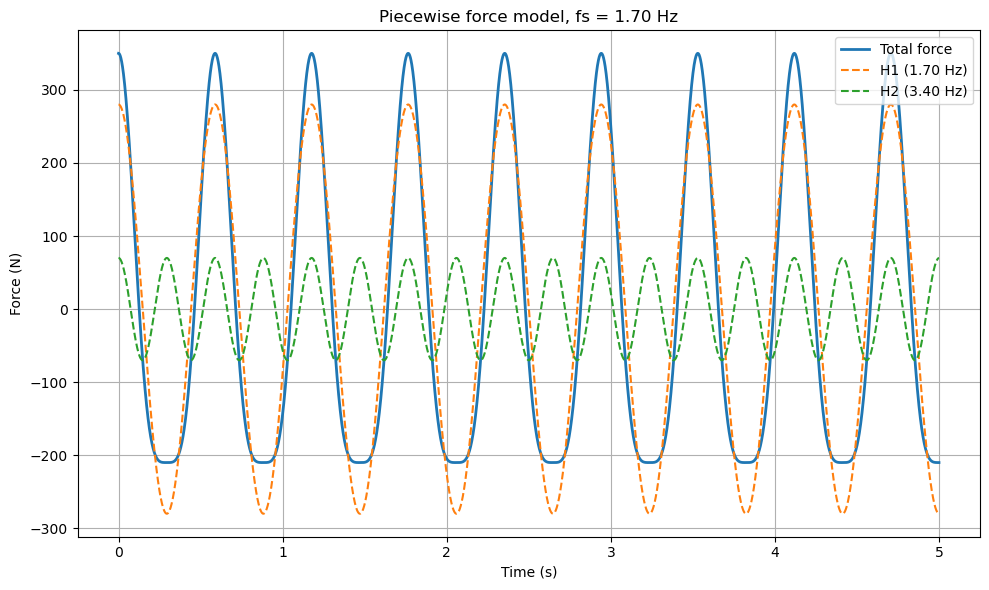

Harmonic breakdown:
H1: freq = 2.10 Hz, psi = 1.0000, amplitude = 280.00 N
H2: freq = 4.20 Hz, psi = 0.2500, amplitude = 70.00 N

Total amplitude upper bound = 350.00 N
Exact total amplitude       = 350.00 N


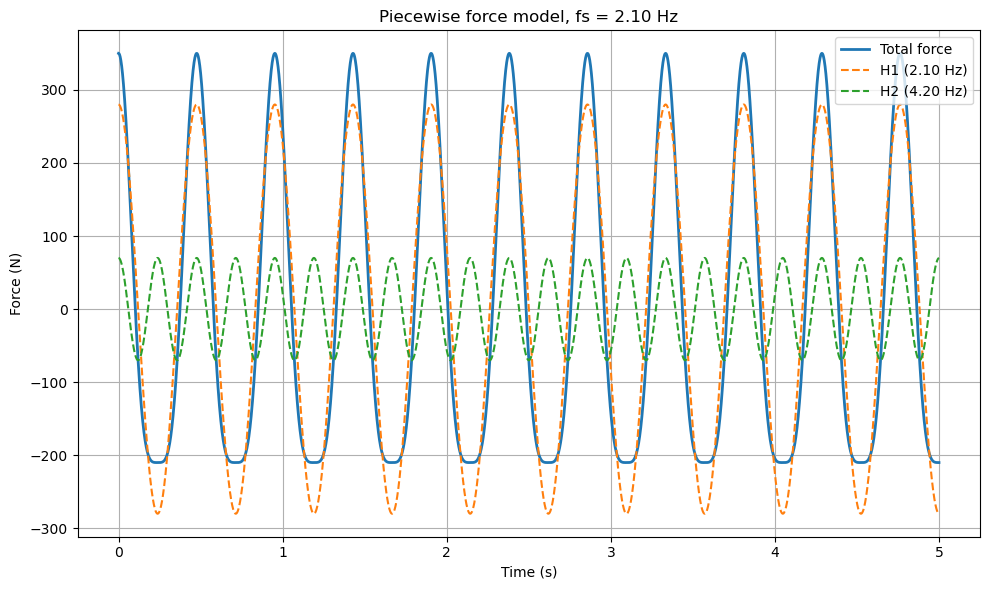

In [13]:
res = piecewise_force_breakdown(fs=1.7, Pw=280.0, t_end=5.0, dt=0.001)
print_piecewise_breakdown(res)
plot_piecewise_force(res)

res = piecewise_force_breakdown(fs=2.1, Pw=280.0, t_end=5.0, dt=0.001)
print_piecewise_breakdown(res)
plot_piecewise_force(res)

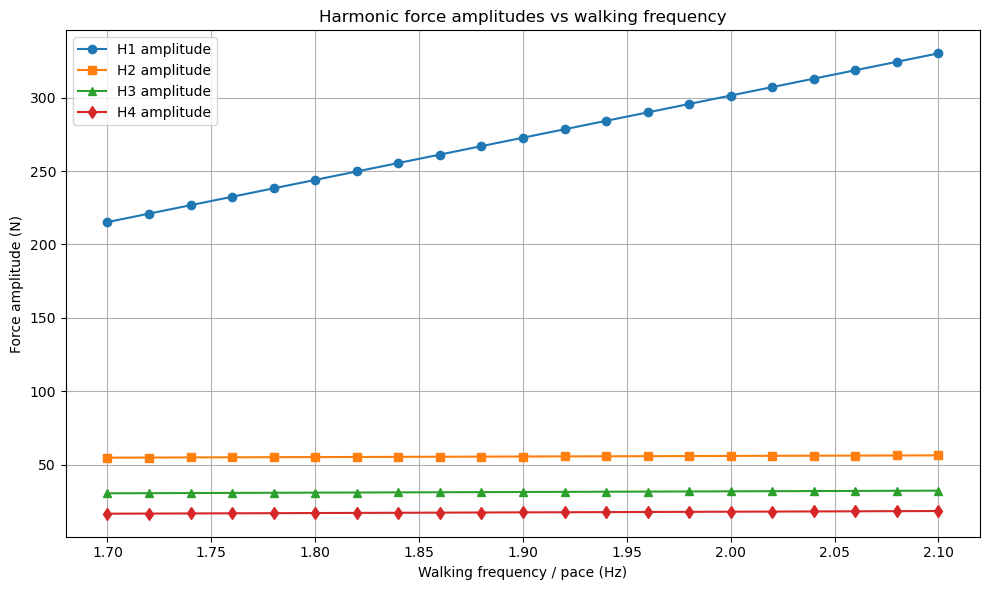

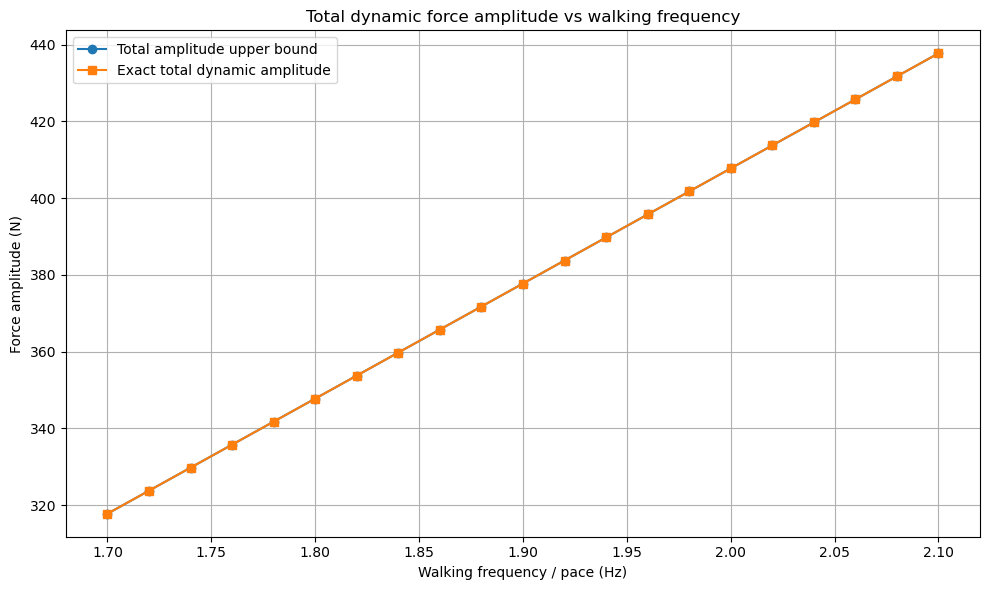

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def dynamic_force_breakdown(pace, mass=75.0, phase=0.0, t_end=5.0, dt=0.001):
    g = 9.81
    W = mass * g
    t = np.arange(0.0, t_end, dt)

    eta = np.array([
        0.41 * (pace - 0.95),
        0.069 + 0.0056 * pace,
        0.033 + 0.0064 * pace,
        0.013 + 0.0065 * pace
    ], dtype=float)

    harmonics = np.arange(1, 5, dtype=float)   # 1,2,3,4
    freqs = harmonics * pace
    amps = W * eta

    components = np.array([
        amps[i] * np.cos(2.0 * np.pi * freqs[i] * t + phase)
        for i in range(4)
    ])

    F_dyn = np.sum(components, axis=0)

    amp_upper_bound = np.sum(np.abs(amps))
    amp_exact = np.max(np.abs(F_dyn))

    return {
        "t": t,
        "components": components,
        "F_dyn": F_dyn,
        "eta": eta,
        "freqs": freqs,
        "amps": amps,
        "amp_upper_bound": amp_upper_bound,
        "amp_exact": amp_exact
    }


# -----------------------------------
# sweep pace from 1.7 to 2.1 Hz
# -----------------------------------
pace_values = np.arange(1.7, 2.1 + 0.0001, 0.02)
mass = 700.0 / 9.81
phase = 0.0

A1_all = []
A2_all = []
A3_all = []
A4_all = []
A_total_upper_all = []
A_total_exact_all = []

for pace in pace_values:
    res = dynamic_force_breakdown(
        pace=pace,
        mass=mass,
        phase=phase,
        t_end=5.0,
        dt=0.001
    )

    A1_all.append(res["amps"][0])
    A2_all.append(res["amps"][1])
    A3_all.append(res["amps"][2])
    A4_all.append(res["amps"][3])
    A_total_upper_all.append(res["amp_upper_bound"])
    A_total_exact_all.append(res["amp_exact"])

A1_all = np.array(A1_all)
A2_all = np.array(A2_all)
A3_all = np.array(A3_all)
A4_all = np.array(A4_all)
A_total_upper_all = np.array(A_total_upper_all)
A_total_exact_all = np.array(A_total_exact_all)

# -----------------------------------
# plot harmonic amplitudes vs pace
# -----------------------------------
plt.figure(figsize=(10, 6))
plt.plot(pace_values, A1_all, marker='o', label="H1 amplitude")
plt.plot(pace_values, A2_all, marker='s', label="H2 amplitude")
plt.plot(pace_values, A3_all, marker='^', label="H3 amplitude")
plt.plot(pace_values, A4_all, marker='d', label="H4 amplitude")
plt.xlabel("Walking frequency / pace (Hz)")
plt.ylabel("Force amplitude (N)")
plt.title("Harmonic force amplitudes vs walking frequency")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------
# plot total dynamic amplitude vs pace
# -----------------------------------
plt.figure(figsize=(10, 6))
plt.plot(pace_values, A_total_upper_all, marker='o', label="Total amplitude upper bound")
plt.plot(pace_values, A_total_exact_all, marker='s', label="Exact total dynamic amplitude")
plt.xlabel("Walking frequency / pace (Hz)")
plt.ylabel("Force amplitude (N)")
plt.title("Total dynamic force amplitude vs walking frequency")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

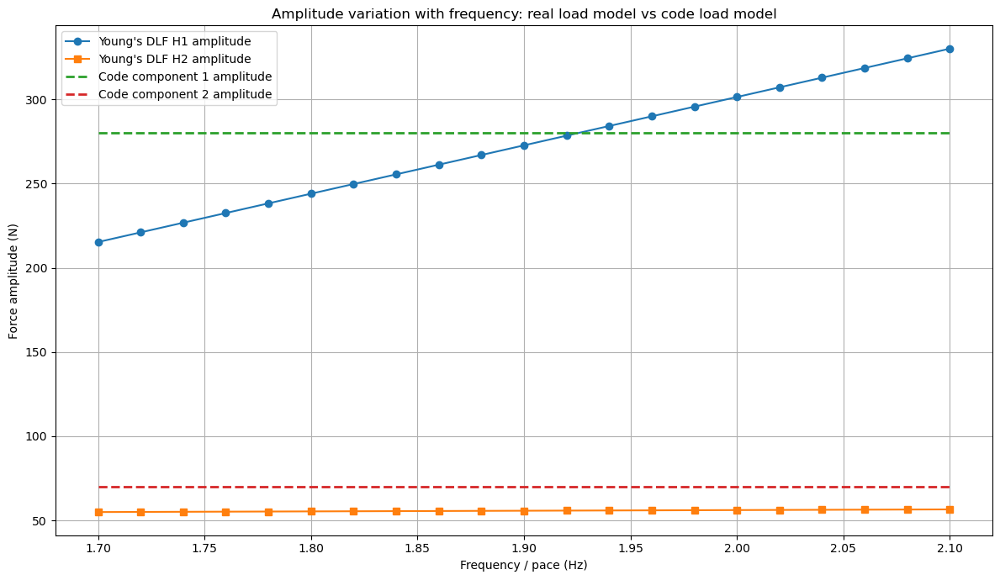

freq    real_H1   real_H2   real_H3   real_H4   real_H234   code_C1   code_C2
1.70     215.25    54.96    30.72    16.83     102.52   280.00    70.00
1.72     220.99    55.04    30.81    16.93     102.77   280.00    70.00
1.74     226.73    55.12    30.90    17.02     103.03   280.00    70.00
1.76     232.47    55.20    30.98    17.11     103.29   280.00    70.00
1.78     238.21    55.28    31.07    17.20     103.55   280.00    70.00
1.80     243.95    55.36    31.16    17.29     103.81   280.00    70.00
1.82     249.69    55.43    31.25    17.38     104.07   280.00    70.00
1.84     255.43    55.51    31.34    17.47     104.33   280.00    70.00
1.86     261.17    55.59    31.43    17.56     104.59   280.00    70.00
1.88     266.91    55.67    31.52    17.65     104.85   280.00    70.00
1.90     272.65    55.75    31.61    17.74     105.11   280.00    70.00
1.92     278.39    55.83    31.70    17.84     105.36   280.00    70.00
1.94     284.13    55.90    31.79    17.93     105.62   28

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# REAL pedestrian force model
# -------------------------------------------------
def dynamic_force_breakdown(pace, mass=75.0, phase=0.0, t_end=5.0, dt=0.001):
    g = 9.81
    W = mass * g
    t = np.arange(0.0, t_end, dt)

    eta = np.array([
        0.41 * (pace - 0.95),
        0.069 + 0.0056 * pace,
        0.033 + 0.0064 * pace,
        0.013 + 0.0065 * pace
    ], dtype=float)

    harmonics = np.arange(1, 5, dtype=float)   # 1,2,3,4
    freqs = harmonics * pace
    amps = W * eta

    components = np.array([
        amps[i] * np.cos(2.0 * np.pi * freqs[i] * t + phase)
        for i in range(4)
    ])

    F_dyn = np.sum(components[:3], axis=0)

    # exact combined amplitude of H2+H3+H4
    F_h234 = np.sum(components[1:], axis=0)
    A_h234_exact = np.max(np.abs(F_h234))
    A_h234_upper = np.sum(np.abs(amps[1:]))

    return {
        "t": t,
        "components": components,
        "F_dyn": F_dyn,
        "eta": eta,
        "freqs": freqs,
        "amps": amps,
        "amp_upper_bound": np.sum(np.abs(amps)),
        "amp_exact": np.max(np.abs(F_dyn)),
        "F_h234": F_h234,
        "A_h234_exact": A_h234_exact,
        "A_h234_upper": A_h234_upper,
    }


# -------------------------------------------------
# CODE load model
# -------------------------------------------------
def psi_w(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.30–2.50 : fixed 0.25
    m = (x >= 2.30) & (x <= 2.50)
    psi[m] = 0.25

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    return float(psi) if psi.ndim == 0 else psi


def piecewise_force_breakdown(fs, Pw=280.0, t_end=5.0, dt=0.001):
    fs = float(fs)
    t = np.arange(0.0, t_end, dt)

    if not (1.0 <= fs <= 5.0):
        raise ValueError("fs must be between 1 and 5 Hz.")

    if 1.25 < fs < 2.30:
        f1 = fs
        f2 = 2.0 * fs
        psi1 = psi_w(fs)
        psi2 = psi_w(2.0 * fs)
    elif 2.30 <= fs <= 4.60:
        f1 = fs / 2.0
        f2 = fs
        psi1 = psi_w(fs / 2.0)
        psi2 = psi_w(fs)
    else:
        f1 = 0.0
        f2 = 0.0
        psi1 = 0.0
        psi2 = 0.0

    A1 = Pw * psi1
    A2 = Pw * psi2

    comp1 = A1 * np.cos(2.0 * np.pi * f1 * t) if f1 > 0 else np.zeros_like(t)
    comp2 = A2 * np.cos(2.0 * np.pi * f2 * t) if f2 > 0 else np.zeros_like(t)
    total = comp1 + comp2

    return {
        "fs": fs,
        "t": t,
        "f1": f1,
        "f2": f2,
        "psi1": psi1,
        "psi2": psi2,
        "A1": A1,
        "A2": A2,
        "comp1": comp1,
        "comp2": comp2,
        "total": total,
        "A_total_upper": abs(A1) + abs(A2),
        "A_total_exact": np.max(np.abs(total)),
    }


# -------------------------------------------------
# SWEEP and COMPARE on same graph
# -------------------------------------------------
pace_values = np.arange(1.7, 2.1 + 1e-12, 0.02)

mass = 700.0 / 9.81   # gives W = 700 N
phase = 0.0

# real model
real_A1 = []
real_A2 = []
real_A3 = []
real_A4 = []
real_total = []
real_h234_exact = []
real_h234_upper = []

# code model
code_A1 = []
code_A2 = []
code_total = []

for fs in pace_values:
    real = dynamic_force_breakdown(
        pace=fs,
        mass=mass,
        phase=phase,
        t_end=5.0,
        dt=0.001
    )

    code = piecewise_force_breakdown(
        fs=fs,
        Pw=280.0,
        t_end=5.0,
        dt=0.001
    )

    real_A1.append(real["amps"][0])
    real_A2.append(real["amps"][1])
    real_A3.append(real["amps"][2])
    real_A4.append(real["amps"][3])
    real_total.append(real["amp_exact"])
    real_h234_exact.append(real["A_h234_exact"])
    real_h234_upper.append(real["A_h234_upper"])

    code_A1.append(code["A1"])
    code_A2.append(code["A2"])
    code_total.append(code["A_total_exact"])

real_A1 = np.array(real_A1)
real_A2 = np.array(real_A2)
real_A3 = np.array(real_A3)
real_A4 = np.array(real_A4)
real_total = np.array(real_total)
real_h234_exact = np.array(real_h234_exact)
real_h234_upper = np.array(real_h234_upper)

code_A1 = np.array(code_A1)
code_A2 = np.array(code_A2)
code_total = np.array(code_total)

# -------------------------------------------------
# Plot all on one graph
# -------------------------------------------------
plt.figure(figsize=(12, 7))

# real model harmonic amplitudes
plt.plot(pace_values, real_A1, marker='o', label="Young's DLF H1 amplitude")
plt.plot(pace_values, real_A2, marker='s', label="Young's DLF H2 amplitude")
#plt.plot(pace_values, real_A3, marker='^', label="Young's DLF H3 amplitude")
#plt.plot(pace_values, real_A4, marker='d', label="Young's DLF H4 amplitude")

# code model component amplitudes
plt.plot(pace_values, code_A1, '--', linewidth=2, label="Code component 1 amplitude")
plt.plot(pace_values, code_A2, '--', linewidth=2, label="Code component 2 amplitude")

# combined higher harmonics in real model
#plt.plot(pace_values, real_h234_exact, linewidth=3, label="Young's DLF combined H2+H3+H4 (exact)")
# optional extra line:
# plt.plot(pace_values, real_h234_upper, ':', linewidth=2, label="Young's DLF combined H2+H3+H4 (upper bound)")

# optional totals
#plt.plot(pace_values, real_total, linewidth=3, label="Young's DLF total dynamic amplitude")
#plt.plot(pace_values, code_total, '--', linewidth=3, label="Code total amplitude")

plt.xlabel("Frequency / pace (Hz)")
plt.ylabel("Force amplitude (N)")
plt.title("Amplitude variation with frequency: real load model vs code load model")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# -------------------------------------------------
# Optional: print a small table
# -------------------------------------------------
print("freq    real_H1   real_H2   real_H3   real_H4   real_H234   code_C1   code_C2")
for i, fs in enumerate(pace_values):
    print(f"{fs:4.2f}   "
          f"{real_A1[i]:8.2f} {real_A2[i]:8.2f} {real_A3[i]:8.2f} {real_A4[i]:8.2f} "
          f"{real_h234_exact[i]:10.2f} {code_A1[i]:8.2f} {code_A2[i]:8.2f}")

In [2]:
# ==================================================
# 2. HELPER FUNCTIONS
# ==================================================

def average_duplicate_x(x, y):
    """
    Average y-values for duplicate x-values.
    Useful because bridge_frequencies may contain duplicate frequencies.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    unique_x = np.unique(x)
    unique_y = np.array([
        np.mean(y[x == xx])
        for xx in unique_x
    ])

    sort_idx = np.argsort(unique_x)

    return unique_x[sort_idx], unique_y[sort_idx]


def get_force_factor_curve(results_all, beamdamp, density, bridge_frequencies, pedBodyF):
    """
    Get force factor/acceleration ratio curve for one damping and one density.

    x = pedBodyF / bridge_frequency
    y = mean acceleration ratio
    """

    x_vals = []
    y_vals = []

    for bf in bridge_frequencies:
        arr = np.asarray(results_all[beamdamp][bf][density]["accel_ratio"], dtype=float)

        x_vals.append(pedBodyF / bf)
        y_vals.append(np.mean(arr))

    x_vals = np.asarray(x_vals)
    y_vals = np.asarray(y_vals)

    x_unique, y_unique = average_duplicate_x(x_vals, y_vals)

    return x_unique, y_unique


def interp_force_factor_exact_damping_density(
    results_all,
    target_bf,
    beamdamp,
    density,
    bridge_frequencies,
    pedBodyF
):
    """
    Interpolate force factor for exact stored damping and density.
    Interpolation is along x = pedBodyF / bridge_frequency.
    """

    x_curve, y_curve = get_force_factor_curve(
        results_all,
        beamdamp,
        density,
        bridge_frequencies,
        pedBodyF
    )

    x_target = pedBodyF / target_bf

    if x_target < x_curve.min() or x_target > x_curve.max():
        raise ValueError(
            f"Target frequency ratio {x_target:.4f} is outside saved range "
            f"[{x_curve.min():.4f}, {x_curve.max():.4f}]"
        )

    force_factor = np.interp(x_target, x_curve, y_curve)

    return x_target, force_factor


def interpolate_force_factor(
    results_all,
    target_bf,
    target_beamdamp,
    target_density,
    bridge_frequencies,
    damping_values,
    densities,
    pedBodyF
):
    """
    Interpolate force factor for:
        target bridge frequency
        target damping ratio
        target density

    Steps:
    1. interpolate along bridge-frequency ratio for each damping and density
    2. interpolate along density
    3. interpolate along damping
    """

    damping_values_sorted = np.sort(np.asarray(damping_values, dtype=float))
    densities_sorted = np.sort(np.asarray(densities, dtype=float))

    if target_beamdamp < damping_values_sorted.min() or target_beamdamp > damping_values_sorted.max():
        raise ValueError(
            f"target_beamdamp={target_beamdamp} is outside saved damping range "
            f"[{damping_values_sorted.min()}, {damping_values_sorted.max()}]"
        )

    if target_density < densities_sorted.min() or target_density > densities_sorted.max():
        raise ValueError(
            f"target_density={target_density} is outside saved density range "
            f"[{densities_sorted.min()}, {densities_sorted.max()}]"
        )

    force_factor_by_damping = []

    for beamdamp in damping_values_sorted:
        force_factor_by_density = []

        for density in densities_sorted:
            _, ff = interp_force_factor_exact_damping_density(
                results_all,
                target_bf,
                beamdamp,
                density,
                bridge_frequencies,
                pedBodyF
            )

            force_factor_by_density.append(ff)

        force_factor_by_density = np.asarray(force_factor_by_density)

        # interpolate across density
        ff_at_density = np.interp(
            target_density,
            densities_sorted,
            force_factor_by_density
        )

        force_factor_by_damping.append(ff_at_density)

    force_factor_by_damping = np.asarray(force_factor_by_damping)

    # interpolate across damping
    force_factor_target = np.interp(
        target_beamdamp,
        damping_values_sorted,
        force_factor_by_damping
    )

    x_target = pedBodyF / target_bf

    return x_target, force_factor_target

Loaded results.
Densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]
Bridge frequencies: [0.31, 0.45, 0.5, 0.55, 0.6, 0.65, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.2, 5.25, 5.5, 5.6, 5.75, 5.8, 5.9, 6.0, 6.15, 6.2, 6.25, 6.3, 6.4, 6.5, 6.6, 6.75, 7.0, 7.25, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 15.0, 20.0, 30.0]
Damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]


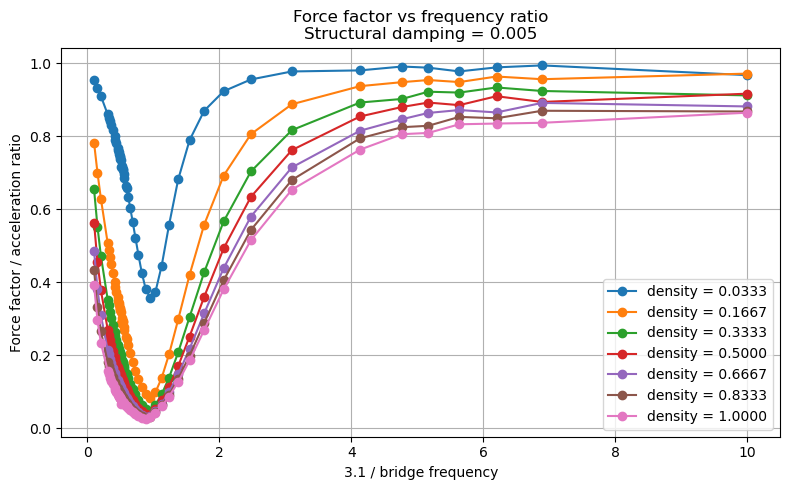

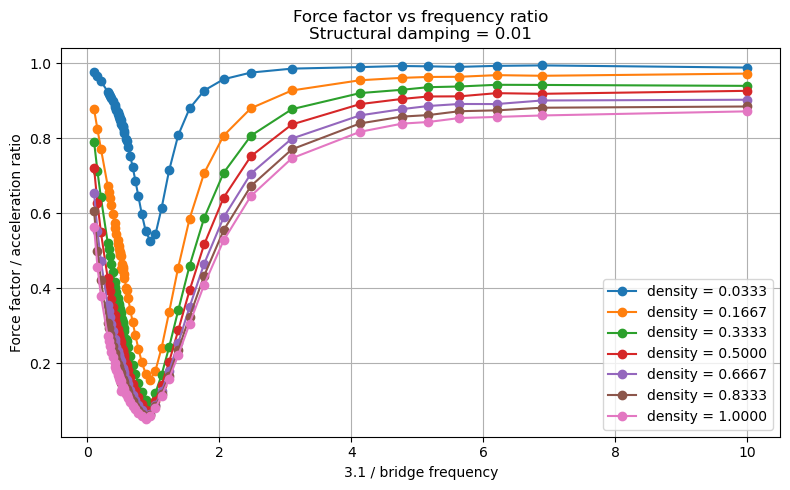

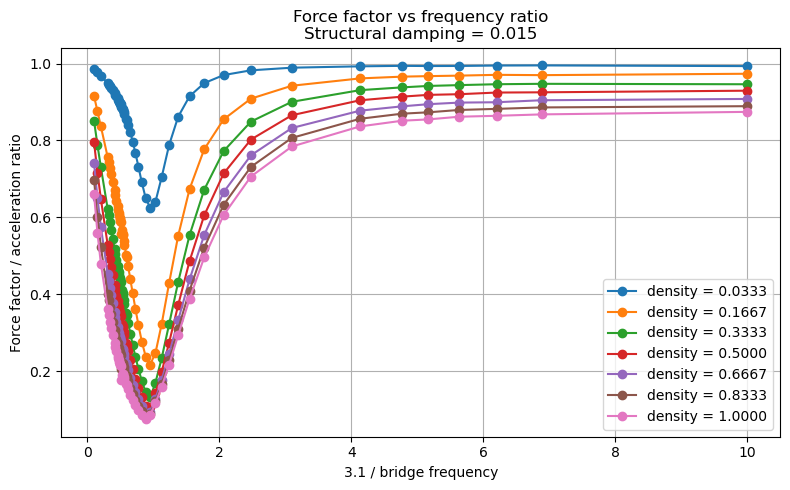

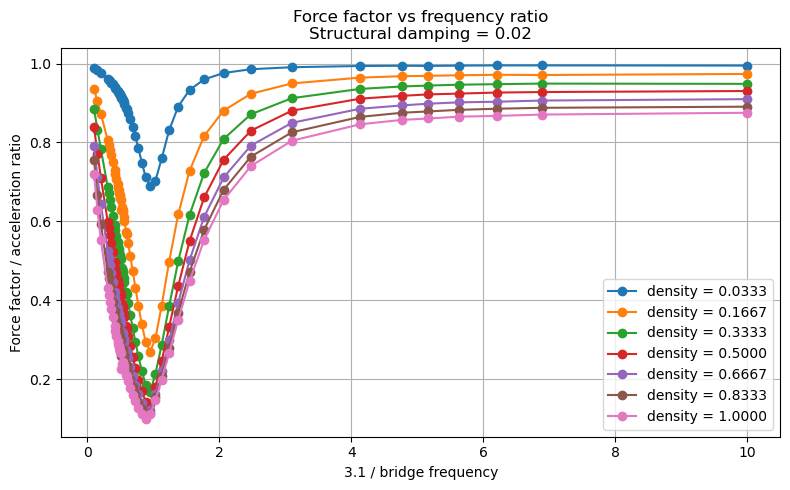

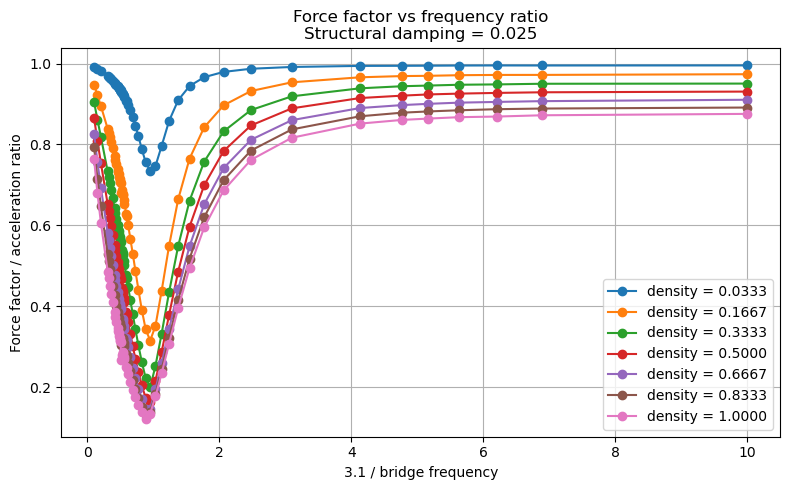

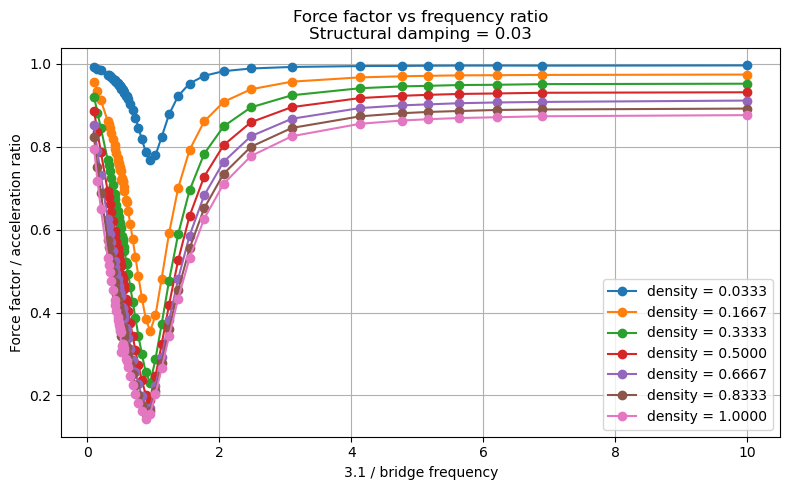

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# 1. LOAD SAVED RESULTS
# ==================================================

with open("forcefactors_bridgeF_bridgedamp.pkl", "rb") as f:
    save_data = pickle.load(f)

results_all = save_data["results_all"]
densities = save_data["densities"]
bridge_frequencies = save_data["bridge_frequencies"]
damping_values = save_data["damping_values"]
length = save_data["length"]
width = save_data["width"]
peddamp = save_data["peddamp"]
pedBodyF = save_data["pedBodyF"]
Linearmass = save_data["Linearmass"]
NUM_SIMULATIONS = save_data["NUM_SIMULATIONS"]

print("Loaded results.")
print("Densities:", densities)
print("Bridge frequencies:", bridge_frequencies)
print("Damping values:", damping_values)

# ==================================================
# 3. PLOT SAVED FORCE-FACTOR CURVES
# ==================================================

for beamdamp in damping_values:
    plt.figure(figsize=(8, 5))

    for density in densities:
        x_curve, y_curve = get_force_factor_curve(
            results_all,
            beamdamp,
            density,
            bridge_frequencies,
            pedBodyF
        )

        plt.plot(
            x_curve,
            y_curve,
            marker="o",
            label=f"density = {density:.4f}"
        )

    plt.xlabel("3.1 / bridge frequency")
    plt.ylabel("Force factor / acceleration ratio")
    plt.title(f"Force factor vs frequency ratio\nStructural damping = {beamdamp}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Target bridge frequency        = 2.35
Target frequency ratio 3.1/fb  = 1.3191489361702127
Target damping ratio           = 0.012
Target density                 = 1.0
Interpolated force factor      = 0.2209244467876117


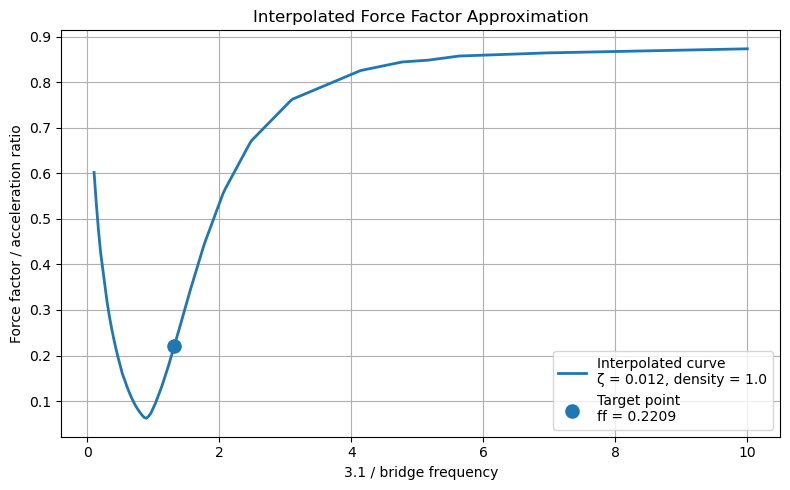

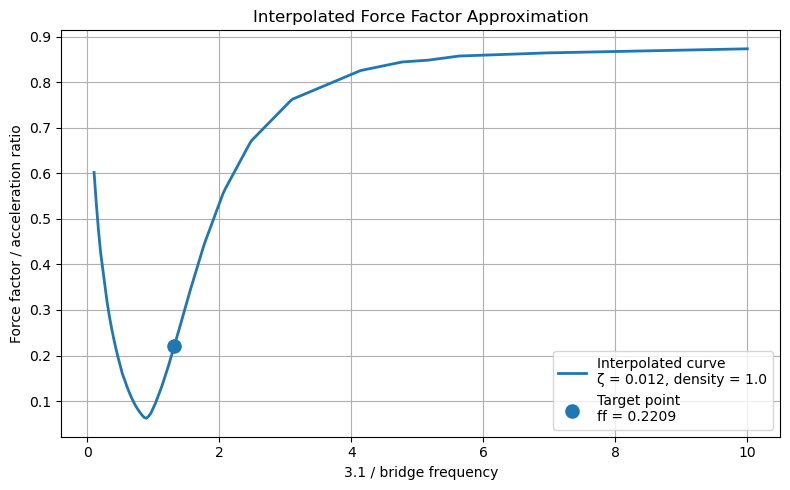

In [4]:
# ==================================================
# 4. TARGET INPUTS FOR INTERPOLATION
# ==================================================

target_bf = 2.35          # target bridge frequency in Hz
target_beamdamp = 0.012   # target structural damping ratio
target_density = 1.0      # target density

# Example if you want density from pedestrian numbers:
# Tocity = 50
# Outcity = 50
# target_density = (Tocity + Outcity) / (width * length)

x_target, force_factor_target = interpolate_force_factor(
    results_all=results_all,
    target_bf=target_bf,
    target_beamdamp=target_beamdamp,
    target_density=target_density,
    bridge_frequencies=bridge_frequencies,
    damping_values=damping_values,
    densities=densities,
    pedBodyF=pedBodyF
)

print("Target bridge frequency        =", target_bf)
print("Target frequency ratio 3.1/fb  =", x_target)
print("Target damping ratio           =", target_beamdamp)
print("Target density                 =", target_density)
print("Interpolated force factor      =", force_factor_target)

# ==================================================
# 5. PLOT INTERPOLATED APPROXIMATION CURVE
# ==================================================

x_min = pedBodyF / max(bridge_frequencies)
x_max = pedBodyF / min(bridge_frequencies)

x_grid = np.linspace(x_min, x_max, 300)

force_factor_grid = []

for x in x_grid:
    bf_from_x = pedBodyF / x

    _, ff = interpolate_force_factor(
        results_all=results_all,
        target_bf=bf_from_x,
        target_beamdamp=target_beamdamp,
        target_density=target_density,
        bridge_frequencies=bridge_frequencies,
        damping_values=damping_values,
        densities=densities,
        pedBodyF=pedBodyF
    )

    force_factor_grid.append(ff)

force_factor_grid = np.asarray(force_factor_grid)

plt.figure(figsize=(8, 5))

plt.plot(
    x_grid,
    force_factor_grid,
    linewidth=2,
    label=f"Interpolated curve\nζ = {target_beamdamp}, density = {target_density}"
)

plt.scatter(
    x_target,
    force_factor_target,
    s=90,
    zorder=5,
    label=f"Target point\nff = {force_factor_target:.4f}"
)

plt.xlabel("3.1 / bridge frequency")
plt.ylabel("Force factor / acceleration ratio")
plt.title("Interpolated Force Factor Approximation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# 5. PLOT INTERPOLATED APPROXIMATION CURVE
# ==================================================

x_min = pedBodyF / max(bridge_frequencies)
x_max = pedBodyF / min(bridge_frequencies)

x_grid = np.linspace(x_min, x_max, 300)

force_factor_grid = []

for x in x_grid:
    bf_from_x = pedBodyF / x

    _, ff = interpolate_force_factor(
        results_all=results_all,
        target_bf=bf_from_x,
        target_beamdamp=target_beamdamp,
        target_density=target_density,
        bridge_frequencies=bridge_frequencies,
        damping_values=damping_values,
        densities=densities,
        pedBodyF=pedBodyF
    )

    force_factor_grid.append(ff)

force_factor_grid = np.asarray(force_factor_grid)

plt.figure(figsize=(8, 5))

plt.plot(
    x_grid,
    force_factor_grid,
    linewidth=2,
    label=f"Interpolated curve\nζ = {target_beamdamp}, density = {target_density}"
)

plt.scatter(
    x_target,
    force_factor_target,
    s=90,
    zorder=5,
    label=f"Target point\nff = {force_factor_target:.4f}"
)

plt.xlabel("3.1 / bridge frequency")
plt.ylabel("Force factor / acceleration ratio")
plt.title("Interpolated Force Factor Approximation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def average_duplicate_x(x, y):
    """
    Average y-values where x-values are duplicated.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    unique_x = np.unique(x)
    unique_y = np.array([
        np.mean(y[x == xx])
        for xx in unique_x
    ])

    idx = np.argsort(unique_x)
    return unique_x[idx], unique_y[idx]


def get_curve_for_density(results_all, beamdamp, density, bridge_frequencies, pedBodyF):
    """
    For one damping and one original density case, return:
        x_curve = pedBodyF / bridge_frequency
        ff_curve = mean acceleration ratio
        mr_curve = mean modal mass ratio
    """

    x_vals = []
    ff_vals = []
    mr_vals = []

    for bf in bridge_frequencies:
        x_vals.append(pedBodyF / bf)

        ff_arr = np.asarray(
            results_all[beamdamp][bf][density]["accel_ratio"],
            dtype=float
        )

        mr_arr = np.asarray(
            results_all[beamdamp][bf][density]["modalpedmass_i"],
            dtype=float
        )

        ff_vals.append(np.mean(ff_arr))
        mr_vals.append(np.mean(mr_arr))

    x_vals = np.asarray(x_vals)
    ff_vals = np.asarray(ff_vals)
    mr_vals = np.asarray(mr_vals)

    # remove duplicate bridge-frequency-ratio values
    x_ff, ff_curve = average_duplicate_x(x_vals, ff_vals)
    x_mr, mr_curve = average_duplicate_x(x_vals, mr_vals)

    return x_ff, ff_curve, mr_curve


def interpolate_at_frequency_for_one_damping(
    results_all,
    beamdamp,
    target_bf,
    target_mass_ratio,
    densities,
    bridge_frequencies,
    pedBodyF
):
    """
    For one damping ratio:
    1. Interpolate force factor along x = pedBodyF / bridge frequency
       for each original density curve.
    2. Convert each density curve to its corresponding mass ratio.
    3. Interpolate force factor across mass ratio.
    """

    x_target = pedBodyF / target_bf

    mass_ratios_at_target = []
    force_factors_at_target = []

    for density in densities:
        x_curve, ff_curve, mr_curve = get_curve_for_density(
            results_all,
            beamdamp,
            density,
            bridge_frequencies,
            pedBodyF
        )

        if x_target < x_curve.min() or x_target > x_curve.max():
            raise ValueError(
                f"x_target={x_target:.4f} is outside saved x range "
                f"[{x_curve.min():.4f}, {x_curve.max():.4f}]"
            )

        # force factor at target bridge frequency for this density curve
        ff_at_x = np.interp(x_target, x_curve, ff_curve)

        # mass ratio corresponding to target bridge frequency for this density curve
        mr_at_x = np.interp(x_target, x_curve, mr_curve)

        mass_ratios_at_target.append(mr_at_x)
        force_factors_at_target.append(ff_at_x)

    mass_ratios_at_target = np.asarray(mass_ratios_at_target)
    force_factors_at_target = np.asarray(force_factors_at_target)

    # sort by mass ratio
    sort_idx = np.argsort(mass_ratios_at_target)
    mr_sorted = mass_ratios_at_target[sort_idx]
    ff_sorted = force_factors_at_target[sort_idx]

    # remove duplicate/near-identical mass ratios by averaging
    mr_unique, ff_unique = average_duplicate_x(mr_sorted, ff_sorted)

    if target_mass_ratio < mr_unique.min() or target_mass_ratio > mr_unique.max():
        raise ValueError(
            f"target_mass_ratio={target_mass_ratio:.4f} is outside saved mass-ratio range "
            f"[{mr_unique.min():.4f}, {mr_unique.max():.4f}] "
            f"for damping={beamdamp} and bridge frequency={target_bf} Hz."
        )

    ff_target = np.interp(target_mass_ratio, mr_unique, ff_unique)

    return x_target, ff_target, mr_unique, ff_unique


def interpolate_force_factor_mass_ratio(
    results_all,
    target_bf,
    target_beamdamp,
    target_mass_ratio,
    damping_values,
    densities,
    bridge_frequencies,
    pedBodyF
):
    """
    Interpolate force factor using:
        x = pedBodyF / bridge frequency
        damping ratio
        modal mass ratio

    This does NOT interpolate over density directly.
    Density is only used as the original grid that produced different mass ratios.
    """

    damping_values = np.asarray(damping_values, dtype=float)
    damping_sorted = np.sort(damping_values)

    if target_beamdamp < damping_sorted.min() or target_beamdamp > damping_sorted.max():
        raise ValueError(
            f"target_beamdamp={target_beamdamp:.4f} is outside damping range "
            f"[{damping_sorted.min():.4f}, {damping_sorted.max():.4f}]"
        )

    ff_by_damping = []

    for beamdamp in damping_sorted:
        _, ff_at_damping, _, _ = interpolate_at_frequency_for_one_damping(
            results_all=results_all,
            beamdamp=beamdamp,
            target_bf=target_bf,
            target_mass_ratio=target_mass_ratio,
            densities=densities,
            bridge_frequencies=bridge_frequencies,
            pedBodyF=pedBodyF
        )

        ff_by_damping.append(ff_at_damping)

    ff_by_damping = np.asarray(ff_by_damping)

    ff_target = np.interp(
        target_beamdamp,
        damping_sorted,
        ff_by_damping
    )

    x_target = pedBodyF / target_bf

    return x_target, ff_target

import numpy as np
import matplotlib.pyplot as plt

def plot_interpolated_force_factor_curve_mass_ratio(
    results_all,
    target_mass_ratio,
    target_beamdamp,
    damping_values,
    densities,
    bridge_frequencies,
    pedBodyF=3.10,
    show_source_curves=True
):
    """
    Plot evolving interpolated force-factor curve:
        x-axis = pedBodyF / bridge_frequency
        y-axis = force factor

    for a chosen target modal mass ratio and target damping ratio.

    Parameters
    ----------
    target_mass_ratio : float
        Desired modal mass ratio, e.g. 0.05

    target_beamdamp : float
        Desired structural damping ratio, e.g. 0.012

    show_source_curves : bool
        If True, also plot the two neighbouring damping curves used for interpolation.
    """

    # sort and find neighbouring damping ratios
    damping_sorted = np.sort(np.asarray(damping_values, dtype=float))

    if target_beamdamp < damping_sorted.min() or target_beamdamp > damping_sorted.max():
        raise ValueError(
            f"target_beamdamp={target_beamdamp:.4f} is outside damping range "
            f"[{damping_sorted.min():.4f}, {damping_sorted.max():.4f}]"
        )

    # lower and upper damping bounds
    idx_upper = np.searchsorted(damping_sorted, target_beamdamp)

    if idx_upper == 0:
        lower_damp = upper_damp = damping_sorted[0]
    elif idx_upper == len(damping_sorted):
        lower_damp = upper_damp = damping_sorted[-1]
    else:
        upper_damp = damping_sorted[idx_upper]
        lower_damp = damping_sorted[idx_upper - 1]

    # unique x-grid from saved bridge frequencies
    x_raw = pedBodyF / np.asarray(bridge_frequencies, dtype=float)
    x_grid = np.sort(np.unique(x_raw))

    # corresponding bridge-frequency grid
    bf_grid = pedBodyF / x_grid

    # interpolated target curve
    ff_target_curve = []

    # optional source curves at the two neighbouring damping ratios
    ff_lower_curve = []
    ff_upper_curve = []

    for bf in bf_grid:
        # final target curve
        _, ff_target = interpolate_force_factor_mass_ratio(
            results_all=results_all,
            target_bf=bf,
            target_beamdamp=target_beamdamp,
            target_mass_ratio=target_mass_ratio,
            damping_values=damping_values,
            densities=densities,
            bridge_frequencies=bridge_frequencies,
            pedBodyF=pedBodyF
        )
        ff_target_curve.append(ff_target)

        # neighbouring damping curves
        _, ff_lower, _, _ = interpolate_at_frequency_for_one_damping(
            results_all=results_all,
            beamdamp=lower_damp,
            target_bf=bf,
            target_mass_ratio=target_mass_ratio,
            densities=densities,
            bridge_frequencies=bridge_frequencies,
            pedBodyF=pedBodyF
        )
        ff_lower_curve.append(ff_lower)

        _, ff_upper, _, _ = interpolate_at_frequency_for_one_damping(
            results_all=results_all,
            beamdamp=upper_damp,
            target_bf=bf,
            target_mass_ratio=target_mass_ratio,
            densities=densities,
            bridge_frequencies=bridge_frequencies,
            pedBodyF=pedBodyF
        )
        ff_upper_curve.append(ff_upper)

    ff_target_curve = np.asarray(ff_target_curve)
    ff_lower_curve = np.asarray(ff_lower_curve)
    ff_upper_curve = np.asarray(ff_upper_curve)

    # plot
    plt.figure(figsize=(8, 5))

    if show_source_curves:
        plt.plot(
            x_grid,
            ff_lower_curve,
            marker="o",
            linestyle="--",
            label=f"source curve at ζ = {lower_damp:.3f}"
        )

        if upper_damp != lower_damp:
            plt.plot(
                x_grid,
                ff_upper_curve,
                marker="s",
                linestyle="--",
                label=f"source curve at ζ = {upper_damp:.3f}"
            )

    plt.plot(
        x_grid,
        ff_target_curve,
        marker="o",
        linewidth=2.5,
        label=f"interpolated curve at ζ = {target_beamdamp:.3f}, mr = {target_mass_ratio:.4f}"
    )

    plt.xlabel("3.1 / bridge frequency")
    plt.ylabel("Force factor")
    plt.title(
        f"Interpolated force-factor curve\n"
        f"target damping = {target_beamdamp:.3f}, target mass ratio = {target_mass_ratio:.4f}"
    )
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return x_grid, ff_target_curve, ff_lower_curve, ff_upper_curve, lower_damp, upper_damp

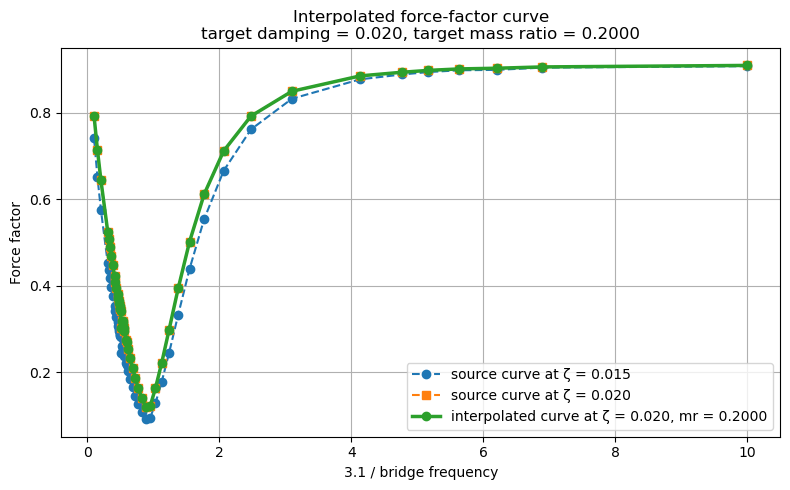

x_target = 3.1 / fb = 1.3191489361702127
Interpolated force factor at target point = 0.35325403423767715


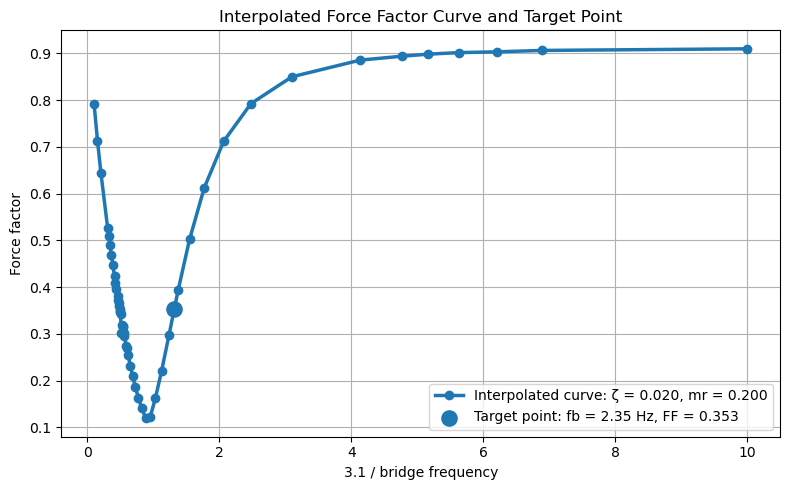

In [16]:
target_bf = 2.35
target_mass_ratio = 0.2
target_beamdamp = 0.02

x_grid, ff_target_curve, ff_lower_curve, ff_upper_curve, lower_damp, upper_damp = \
    plot_interpolated_force_factor_curve_mass_ratio(
        results_all=results_all,
        target_mass_ratio=target_mass_ratio,
        target_beamdamp=target_beamdamp,
        damping_values=damping_values,
        densities=densities,
        bridge_frequencies=bridge_frequencies,
        pedBodyF=pedBodyF,
        show_source_curves=True
    )
x_target, ff_target_point = interpolate_force_factor_mass_ratio(
    results_all=results_all,
    target_bf=target_bf,
    target_beamdamp=target_beamdamp,
    target_mass_ratio=target_mass_ratio,
    damping_values=damping_values,
    densities=densities,
    bridge_frequencies=bridge_frequencies,
    pedBodyF=pedBodyF
)

print("x_target = 3.1 / fb =", x_target)
print("Interpolated force factor at target point =", ff_target_point)

plt.figure(figsize=(8, 5))

plt.plot(
    x_grid,
    ff_target_curve,
    marker="o",
    linewidth=2.5,
    label=f"Interpolated curve: ζ = {target_beamdamp:.3f}, mr = {target_mass_ratio:.3f}"
)

plt.scatter(
    x_target,
    ff_target_point,
    s=120,
    zorder=5,
    label=f"Target point: fb = {target_bf:.2f} Hz, FF = {ff_target_point:.3f}"
)

plt.xlabel("3.1 / bridge frequency")
plt.ylabel("Force factor")
plt.title("Interpolated Force Factor Curve and Target Point")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
def average_duplicate_x(x, *ys):
    """
    Average y-values when duplicate x-values exist.
    Useful because bridge_frequencies may contain duplicate values.
    """
    x = np.asarray(x, dtype=float)
    ys = [np.asarray(y, dtype=float) for y in ys]

    unique_x = np.unique(x)

    averaged_ys = []
    for y in ys:
        averaged_y = np.array([
            np.mean(y[x == xx])
            for xx in unique_x
        ])
        averaged_ys.append(averaged_y)

    sort_idx = np.argsort(unique_x)
    unique_x = unique_x[sort_idx]
    averaged_ys = [y[sort_idx] for y in averaged_ys]

    return (unique_x, *averaged_ys)


def bracket_values(grid, target, name="value"):
    """
    Find lower and upper grid values around target.
    If target exactly exists, lower = upper = target.
    """
    grid = np.asarray(sorted(grid), dtype=float)

    if target < grid.min() or target > grid.max():
        raise ValueError(
            f"{name} = {target} is outside saved range "
            f"[{grid.min()}, {grid.max()}]"
        )

    exact = np.where(np.isclose(grid, target, rtol=0, atol=1e-12))[0]
    if len(exact) > 0:
        val = grid[exact[0]]
        return val, val

    idx_upper = np.searchsorted(grid, target)
    lower = grid[idx_upper - 1]
    upper = grid[idx_upper]

    return lower, upper


def get_curve_for_one_density(
    results_all,
    beamdamp,
    density,
    bridge_frequencies,
    pedBodyF
):
    """
    For one damping and one original density case, extract:

    x = pedBodyF / bridge_frequency
    y = force factor = mean acceleration ratio
    mr = mean modal mass ratio
    """

    x_vals = []
    ff_vals = []
    mr_vals = []

    for bf in bridge_frequencies:
        data = results_all[beamdamp][bf][density]

        accel_ratio_arr = np.asarray(data["accel_ratio"], dtype=float)
        modal_mass_arr = np.asarray(data["modalpedmass_i"], dtype=float)

        x_vals.append(pedBodyF / bf)
        ff_vals.append(np.mean(accel_ratio_arr))
        mr_vals.append(np.mean(modal_mass_arr))

    x_vals = np.asarray(x_vals)
    ff_vals = np.asarray(ff_vals)
    mr_vals = np.asarray(mr_vals)

    # remove duplicate x values
    x_unique, ff_unique, mr_unique = average_duplicate_x(
        x_vals,
        ff_vals,
        mr_vals
    )

    return x_unique, ff_unique, mr_unique


def interpolate_force_factor_one_damping(
    results_all,
    target_bf,
    target_mass_ratio,
    beamdamp,
    densities,
    bridge_frequencies,
    pedBodyF
):
    """
    For one damping value:

    1. Convert target bridge frequency to x = pedBodyF / target_bf.
    2. For each original density curve, interpolate force factor at x.
    3. Also interpolate modal mass ratio at x.
    4. Interpolate force factor across modal mass ratio.
    """

    x_target = pedBodyF / target_bf

    mass_ratio_points = []
    force_factor_points = []

    for density in densities:
        x_curve, ff_curve, mr_curve = get_curve_for_one_density(
            results_all=results_all,
            beamdamp=beamdamp,
            density=density,
            bridge_frequencies=bridge_frequencies,
            pedBodyF=pedBodyF
        )

        if x_target < x_curve.min() or x_target > x_curve.max():
            raise ValueError(
                f"x_target = {x_target:.4f} is outside saved x range "
                f"[{x_curve.min():.4f}, {x_curve.max():.4f}]"
            )

        ff_at_x = np.interp(x_target, x_curve, ff_curve)
        mr_at_x = np.interp(x_target, x_curve, mr_curve)

        force_factor_points.append(ff_at_x)
        mass_ratio_points.append(mr_at_x)

    mass_ratio_points = np.asarray(mass_ratio_points)
    force_factor_points = np.asarray(force_factor_points)

    # sort by mass ratio
    sort_idx = np.argsort(mass_ratio_points)
    mr_sorted = mass_ratio_points[sort_idx]
    ff_sorted = force_factor_points[sort_idx]

    # remove duplicate mass-ratio points if any
    mr_unique, ff_unique = average_duplicate_x(mr_sorted, ff_sorted)

    if target_mass_ratio < mr_unique.min() or target_mass_ratio > mr_unique.max():
        raise ValueError(
            f"target_mass_ratio = {target_mass_ratio:.4f} is outside saved "
            f"mass-ratio range [{mr_unique.min():.4f}, {mr_unique.max():.4f}] "
            f"at damping = {beamdamp} and bridge frequency = {target_bf} Hz."
        )

    ff_at_mass_ratio = np.interp(
        target_mass_ratio,
        mr_unique,
        ff_unique
    )

    return x_target, ff_at_mass_ratio, mr_unique, ff_unique


def interpolate_force_factor_exact_point(
    results_all,
    target_bf,
    target_beamdamp,
    target_mass_ratio,
    damping_values,
    densities,
    bridge_frequencies,
    pedBodyF
):
    """
    Interpolate exact force factor at:

        target bridge frequency
        target damping ratio
        target modal mass ratio

    Final output:
        x_target = pedBodyF / target_bf
        force_factor_target
    """

    lower_damp, upper_damp = bracket_values(
        damping_values,
        target_beamdamp,
        name="target_beamdamp"
    )

    # If damping exactly exists in saved results
    if np.isclose(lower_damp, upper_damp):
        x_target, ff_target, mr_grid, ff_grid = interpolate_force_factor_one_damping(
            results_all=results_all,
            target_bf=target_bf,
            target_mass_ratio=target_mass_ratio,
            beamdamp=lower_damp,
            densities=densities,
            bridge_frequencies=bridge_frequencies,
            pedBodyF=pedBodyF
        )

        details = {
            "lower_damp": lower_damp,
            "upper_damp": upper_damp,
            "ff_lower": ff_target,
            "ff_upper": ff_target,
            "damping_weight": 0.0,
            "mr_grid_lower": mr_grid,
            "ff_grid_lower": ff_grid,
            "mr_grid_upper": mr_grid,
            "ff_grid_upper": ff_grid,
        }

        return x_target, ff_target, details

    # Interpolate at lower damping
    x_target, ff_lower, mr_grid_lower, ff_grid_lower = interpolate_force_factor_one_damping(
        results_all=results_all,
        target_bf=target_bf,
        target_mass_ratio=target_mass_ratio,
        beamdamp=lower_damp,
        densities=densities,
        bridge_frequencies=bridge_frequencies,
        pedBodyF=pedBodyF
    )

    # Interpolate at upper damping
    _, ff_upper, mr_grid_upper, ff_grid_upper = interpolate_force_factor_one_damping(
        results_all=results_all,
        target_bf=target_bf,
        target_mass_ratio=target_mass_ratio,
        beamdamp=upper_damp,
        densities=densities,
        bridge_frequencies=bridge_frequencies,
        pedBodyF=pedBodyF
    )

    # Linear interpolation between damping curves
    w = (target_beamdamp - lower_damp) / (upper_damp - lower_damp)

    ff_target = (1.0 - w) * ff_lower + w * ff_upper

    details = {
        "lower_damp": lower_damp,
        "upper_damp": upper_damp,
        "ff_lower": ff_lower,
        "ff_upper": ff_upper,
        "damping_weight": w,
        "mr_grid_lower": mr_grid_lower,
        "ff_grid_lower": ff_grid_lower,
        "mr_grid_upper": mr_grid_upper,
        "ff_grid_upper": ff_grid_upper,
    }

    return x_target, ff_target, details

In [18]:
target_bf = 2.35
target_mass_ratio = 0.132
target_beamdamp = 0.017

x_target, force_factor_target, details = interpolate_force_factor_exact_point(
    results_all=results_all,
    target_bf=target_bf,
    target_beamdamp=target_beamdamp,
    target_mass_ratio=target_mass_ratio,
    damping_values=damping_values,
    densities=densities,
    bridge_frequencies=bridge_frequencies,
    pedBodyF=pedBodyF
)

print("Target bridge frequency       =", target_bf)
print("Target frequency ratio 3.1/fb =", x_target)
print("Target damping ratio          =", target_beamdamp)
print("Target modal mass ratio       =", target_mass_ratio)
print("Interpolated force factor     =", force_factor_target)

print("\nInterpolation details:")
print("Lower damping used            =", details["lower_damp"])
print("Upper damping used            =", details["upper_damp"])
print("Force factor at lower damping =", details["ff_lower"])
print("Force factor at upper damping =", details["ff_upper"])
print("Damping interpolation weight  =", details["damping_weight"])

Target bridge frequency       = 2.35
Target frequency ratio 3.1/fb = 1.3191489361702127
Target damping ratio          = 0.017
Target modal mass ratio       = 0.132
Interpolated force factor     = 0.37326224488013854

Interpolation details:
Lower damping used            = 0.015
Upper damping used            = 0.02
Force factor at lower damping = 0.34829986450416084
Force factor at upper damping = 0.41070581544410506
Damping interpolation weight  = 0.4000000000000003


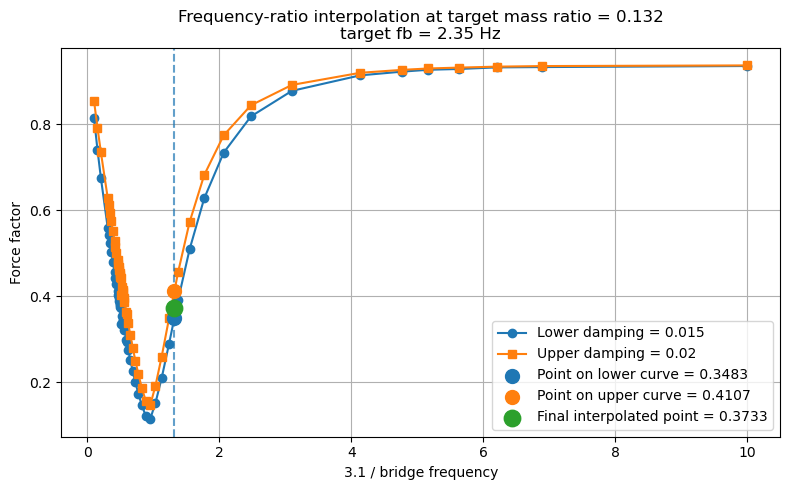

In [19]:
# --------------------------------------------------
# Plot 1: Force factor vs 3.1 / bridge frequency
# for lower and upper damping, at target mass ratio
# --------------------------------------------------

lower_damp = details["lower_damp"]
upper_damp = details["upper_damp"]

# unique x-grid from saved bridge frequencies
x_grid = np.sort(np.unique(pedBodyF / np.asarray(bridge_frequencies, dtype=float)))
bf_grid = pedBodyF / x_grid

ff_curve_lower = []
ff_curve_upper = []

for bf in bf_grid:
    _, ff_lower, _, _ = interpolate_force_factor_one_damping(
        results_all=results_all,
        target_bf=bf,
        target_mass_ratio=target_mass_ratio,
        beamdamp=lower_damp,
        densities=densities,
        bridge_frequencies=bridge_frequencies,
        pedBodyF=pedBodyF
    )
    ff_curve_lower.append(ff_lower)

    _, ff_upper, _, _ = interpolate_force_factor_one_damping(
        results_all=results_all,
        target_bf=bf,
        target_mass_ratio=target_mass_ratio,
        beamdamp=upper_damp,
        densities=densities,
        bridge_frequencies=bridge_frequencies,
        pedBodyF=pedBodyF
    )
    ff_curve_upper.append(ff_upper)

ff_curve_lower = np.asarray(ff_curve_lower)
ff_curve_upper = np.asarray(ff_curve_upper)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, ff_curve_lower, marker='o', label=f"Lower damping = {lower_damp}")
plt.plot(x_grid, ff_curve_upper, marker='s', label=f"Upper damping = {upper_damp}")

plt.scatter(
    x_target, details["ff_lower"],
    s=100, zorder=5, label=f"Point on lower curve = {details['ff_lower']:.4f}"
)
plt.scatter(
    x_target, details["ff_upper"],
    s=100, zorder=5, label=f"Point on upper curve = {details['ff_upper']:.4f}"
)
plt.scatter(
    x_target, force_factor_target,
    s=140, zorder=6, label=f"Final interpolated point = {force_factor_target:.4f}"
)

plt.axvline(x_target, linestyle='--', alpha=0.7)
plt.xlabel("3.1 / bridge frequency")
plt.ylabel("Force factor")
plt.title(
    f"Frequency-ratio interpolation at target mass ratio = {target_mass_ratio}\n"
    f"target fb = {target_bf} Hz"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

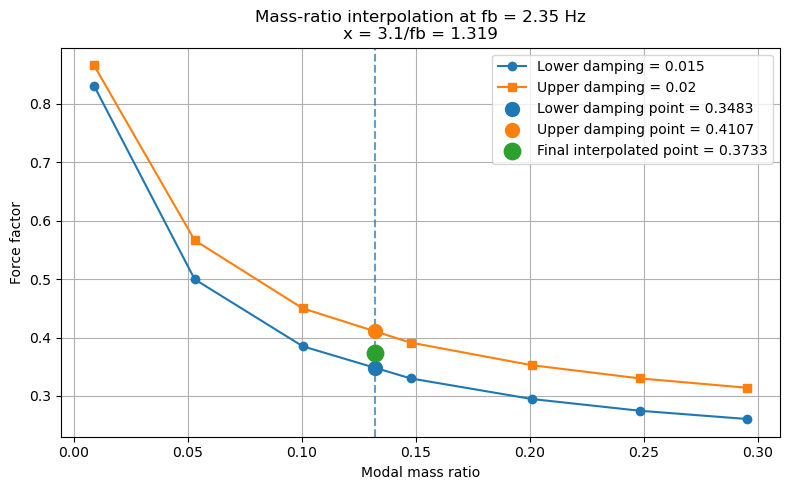

In [20]:
# --------------------------------------------------
# Plot 2: Force factor vs modal mass ratio
# at target bridge frequency
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    details["mr_grid_lower"],
    details["ff_grid_lower"],
    marker='o',
    label=f"Lower damping = {lower_damp}"
)

if not np.isclose(lower_damp, upper_damp):
    plt.plot(
        details["mr_grid_upper"],
        details["ff_grid_upper"],
        marker='s',
        label=f"Upper damping = {upper_damp}"
    )

plt.scatter(
    target_mass_ratio,
    details["ff_lower"],
    s=100,
    zorder=5,
    label=f"Lower damping point = {details['ff_lower']:.4f}"
)

plt.scatter(
    target_mass_ratio,
    details["ff_upper"],
    s=100,
    zorder=5,
    label=f"Upper damping point = {details['ff_upper']:.4f}"
)

plt.scatter(
    target_mass_ratio,
    force_factor_target,
    s=140,
    zorder=6,
    label=f"Final interpolated point = {force_factor_target:.4f}"
)

plt.axvline(target_mass_ratio, linestyle='--', alpha=0.7)
plt.xlabel("Modal mass ratio")
plt.ylabel("Force factor")
plt.title(
    f"Mass-ratio interpolation at fb = {target_bf} Hz\n"
    f"x = 3.1/fb = {x_target:.3f}"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

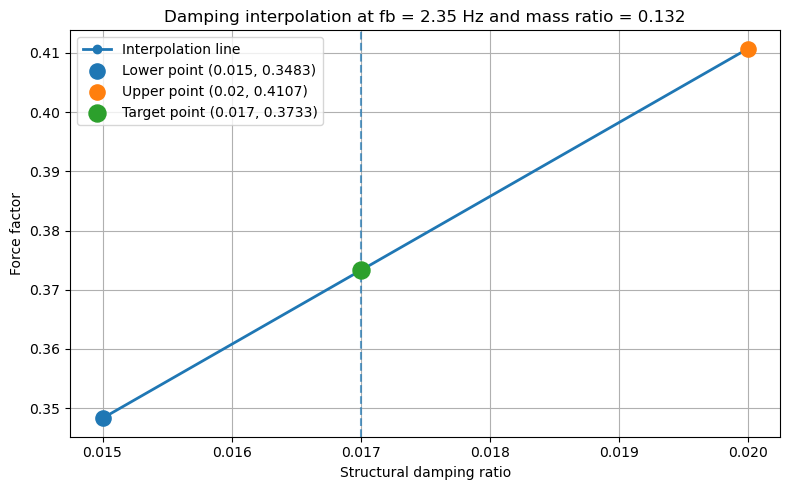

In [21]:
# --------------------------------------------------
# Plot 3: Damping interpolation
# --------------------------------------------------

damp_points = np.array([details["lower_damp"], details["upper_damp"]], dtype=float)
ff_points = np.array([details["ff_lower"], details["ff_upper"]], dtype=float)

plt.figure(figsize=(8, 5))
plt.plot(damp_points, ff_points, marker='o', linewidth=2, label="Interpolation line")

plt.scatter(
    details["lower_damp"], details["ff_lower"],
    s=120, zorder=5,
    label=f"Lower point ({details['lower_damp']}, {details['ff_lower']:.4f})"
)

plt.scatter(
    details["upper_damp"], details["ff_upper"],
    s=120, zorder=5,
    label=f"Upper point ({details['upper_damp']}, {details['ff_upper']:.4f})"
)

plt.scatter(
    target_beamdamp, force_factor_target,
    s=150, zorder=6,
    label=f"Target point ({target_beamdamp}, {force_factor_target:.4f})"
)

plt.axvline(target_beamdamp, linestyle='--', alpha=0.7)
plt.xlabel("Structural damping ratio")
plt.ylabel("Force factor")
plt.title(
    f"Damping interpolation at fb = {target_bf} Hz and mass ratio = {target_mass_ratio}"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Bridge frequency = 3.5
Target density   = 0.5
Actual density   = 0.5
Total peds       = 50
Tocity, Outcity  = 25 25
Acceleration array shape = (48, 10001)
Mean modal mass ratio    = 0.1461828710052099
Mean peak 1-sec RMS = 0.260075245635956
Std peak 1-sec RMS  = 0.04536973173580039
5% peak RMS         = 0.19536074601332395
95% peak RMS        = 0.36117790136057576


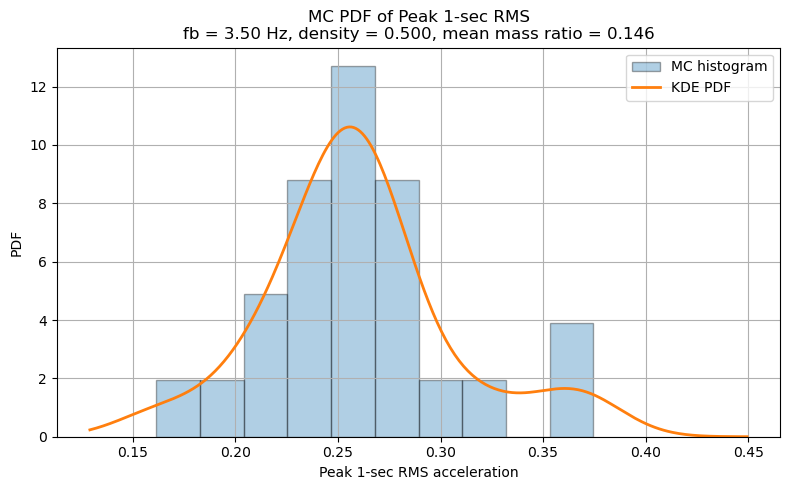

In [37]:
# ==================================================
# MC ONLY: one bridge frequency + one density
# Plot distribution/PDF of peak 1-sec RMS
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
from scipy.stats import gaussian_kde

from bias import run_simulation
from biascodefunction import peak_rms_distribution

# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 48
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

target_bf = 3.5        # bridge first frequency
target_beamdamp = 0.005
density = 0.5000         # selected density

# --------------------------------------------------
# Convert density to pedestrian numbers
# --------------------------------------------------
BeamFreq = np.array([target_bf, 4 * target_bf])
Beamdamp = np.array([target_beamdamp])

total_peds_float = density * Length * Width
total_peds_int = int(round(total_peds_float))
total_peds_int = max(1, total_peds_int)

Tocity = total_peds_int // 2
Outcity = total_peds_int - Tocity

actual_density = (Tocity + Outcity) / (Length * Width)

print("Bridge frequency =", target_bf)
print("Target density   =", density)
print("Actual density   =", actual_density)
print("Total peds       =", total_peds_int)
print("Tocity, Outcity  =", Tocity, Outcity)

# --------------------------------------------------
# Run MC reference simulations
# --------------------------------------------------
rng = np.random.default_rng(12345)
seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

args_list = [
    (
        int(seeds[i]),
        peddamp,
        pedBodyF,
        BeamFreq,
        Beamdamp,
        Tocity,
        Outcity,
        Length,
        Width
    )
    for i in range(NUM_SIMULATIONS)
]

try:
    mp.set_start_method("spawn")
except RuntimeError:
    pass

ctx = mp.get_context("spawn")

with ctx.Pool(processes=NUM_PROCESSES) as pool:
    results = pool.map(run_simulation, args_list)

# --------------------------------------------------
# Extract acceleration histories and mass ratios
# --------------------------------------------------
accelerations = np.array([r[0] for r in results])
mean_mass_ratios = np.array([r[1] for r in results])

overall_mean_mass_ratio = np.mean(mean_mass_ratios)

print("Acceleration array shape =", accelerations.shape)
print("Mean modal mass ratio    =", overall_mean_mass_ratio)

# --------------------------------------------------
# Remove initial transient
# --------------------------------------------------
steady_start_idx = int(round(steady_start_time / hht))

if steady_start_idx >= accelerations.shape[1]:
    raise ValueError("steady_start_time is longer than acceleration time history.")

accelerations_ss = accelerations[:, steady_start_idx:]

# --------------------------------------------------
# Calculate peak 1-sec RMS distribution
# --------------------------------------------------
rms_histories, peak_rms_values = peak_rms_distribution(
    accelerations_ss,
    dt=hht,
    window_sec=1.0
)

print("Mean peak 1-sec RMS =", np.mean(peak_rms_values))
print("Std peak 1-sec RMS  =", np.std(peak_rms_values))
print("5% peak RMS         =", np.percentile(peak_rms_values, 5))
print("95% peak RMS        =", np.percentile(peak_rms_values, 95))

# --------------------------------------------------
# Plot PDF of peak 1-sec RMS
# --------------------------------------------------
Y = np.asarray(peak_rms_values, dtype=float)
Y = Y[np.isfinite(Y)]

plt.figure(figsize=(8, 5))

plt.hist(
    Y,
    bins=10,
    density=True,
    alpha=0.35,
    edgecolor="black",
    label="MC histogram"
)

if len(Y) >= 2 and np.std(Y) > 0:
    kde = gaussian_kde(Y)
    x_grid = np.linspace(max(0.0, Y.min() * 0.8), Y.max() * 1.2, 300)
    plt.plot(x_grid, kde(x_grid), linewidth=2, label="KDE PDF")

plt.xlabel("Peak 1-sec RMS acceleration")
plt.ylabel("PDF")
plt.title(
    f"MC PDF of Peak 1-sec RMS\n"
    f"fb = {target_bf:.2f} Hz, density = {actual_density:.3f}, "
    f"mean mass ratio = {overall_mean_mass_ratio:.3f}"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Loaded force-factor database.
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]

RUNNING BRIDGE FREQUENCY = 2.4 Hz

Running density = 0.8333
  total pedestrians = 83
  Tocity = 41, Outcity = 42
  actual density = 0.8300
  MC mean mass ratio       = 0.2675
  mass ratio used for x    = 0.2675

--- Simplified direct force factor rule ---
Bridge frequency              = 2.4
Interpolated x factor          = 0.10624864579534186
Force reduction factor used    = 0.10624864579534186
Density kept unchanged?        = True

Response measure = peak_rms
  code mean bias       = 0.9298
  code 5-95% bias      = [0.6948, 1.1908]
  simplified mean bias = 6.9038
  simplified 5-95%     = [5.1592, 8.8418]

Response measure = peak_abs
  code mean bias       = 0.9701
  code 5-95% bias      = [0.7235, 1.2434]
  simplified mean bias = 7.2033
  simplified 5-95%     = [5.3720, 9.2324]

Response measure = p95_acc
  code mean bias       = 0.6114
  code 5-95% bias      = [0.4749, 0.7004]
  simplifie

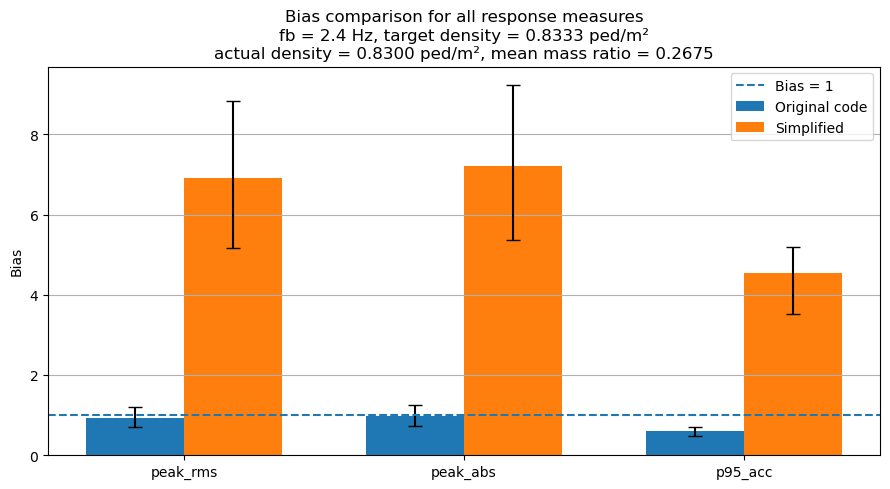


Selected case bias summary
--------------------------
Bridge frequency       = 2.400 Hz
Target density         = 0.8333 ped/m²
Actual density         = 0.8300 ped/m²
Mean modal mass ratio  = 0.2675

Response measure: peak_rms
  Code bias mean        = 0.9298
  Code bias 5–95%       = [0.6948, 1.1908]
  Simplified bias mean  = 6.9038
  Simplified bias 5–95% = [5.1592, 8.8418]

Response measure: peak_abs
  Code bias mean        = 0.9701
  Code bias 5–95%       = [0.7235, 1.2434]
  Simplified bias mean  = 7.2033
  Simplified bias 5–95% = [5.3720, 9.2324]

Response measure: p95_acc
  Code bias mean        = 0.6114
  Code bias 5–95%       = [0.4749, 0.7004]
  Simplified bias mean  = 4.5398
  Simplified bias 5–95% = [3.5260, 5.2007]


In [39]:
# ==================================================
# FULL WORKFLOW:
# Bias vs mean modal mass ratio
# for multiple bridge frequencies
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt
import pickle

from bias_trial import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    interpolate_force_factor_exact_point
)

# ==================================================
# SETTINGS
# ==================================================

NUM_SIMULATIONS = 48
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

# Selected case only
selected_bf = 2.4
selected_density = 0.8333

bridge_frequencies_to_run = [selected_bf]
densities = [selected_density]

# Fixed damping ratio for this study
target_beamdamp = 0.005

# Choose response measure:
# "peak_rms" = peak 1-sec RMS
# "peak_abs" = peak absolute acceleration
# "p95_acc"  = 95th percentile absolute acceleration
response_measures = ["peak_rms", "peak_abs", "p95_acc"]

# Force-factor database
FORCE_FACTOR_FILE = "forcefactors_bridgeF_bridgedamp.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29

eps = 1e-12


# ==================================================
# RESPONSE MEASURE SETTINGS
# ==================================================

measure_specs = {
    "peak_rms": {
        "scalar_key": "peak_1sec_rms",
        "y_label": "Bias in peak 1-sec RMS",
        "plot_title": "Bias vs Mean Modal Mass Ratio (Peak 1-sec RMS)"
    },
    "peak_abs": {
        "scalar_key": "peak_abs_acc",
        "y_label": "Bias in peak absolute acceleration",
        "plot_title": "Bias vs Mean Modal Mass Ratio (Peak Absolute Acceleration)"
    },
    "p95_acc": {
        "scalar_key": "p95_abs_acc",
        "y_label": "Bias in 95% acceleration",
        "plot_title": "Bias vs Mean Modal Mass Ratio (95% Acceleration)"
    }
}
for rm in response_measures:
    if rm not in measure_specs:
        raise ValueError("response_measures must only contain 'peak_rms', 'peak_abs', or 'p95_acc'")

# ==================================================
# HELPER FUNCTIONS
# ==================================================

def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    """
    Keep mass ratio inside interpolation database range.
    """
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


def print_case_summary(target_bf, density, actual_density, mr, B_code, B_simp):
    print(f"\nfb = {target_bf:.3f} Hz | density target = {density:.4f}")
    print(f"  actual density       = {actual_density:.4f}")
    print(f"  mean modal mass ratio = {mr:.4f}")
    print(f"  code mean bias        = {np.mean(B_code):.4f}")
    print(f"  simplified mean bias  = {np.mean(B_simp):.4f}")


# ==================================================
# LOAD FORCE-FACTOR DATABASE
# ==================================================

with open(FORCE_FACTOR_FILE, "rb") as f:
    ff_data = pickle.load(f)

ff_results_all = ff_data["results_all"]
ff_densities = ff_data["densities"]
ff_bridge_frequencies = ff_data["bridge_frequencies"]
ff_damping_values = ff_data["damping_values"]
ff_pedBodyF = ff_data["pedBodyF"]

print("Loaded force-factor database.")
print("Available damping values:", ff_damping_values)


# ==================================================
# MAIN LOOP
# ==================================================

if __name__ == "__main__":

    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    ctx = mp.get_context("spawn")
    rng = np.random.default_rng(12345)

    summary_by_freq = {}

    with ctx.Pool(processes=NUM_PROCESSES) as pool:

        for target_bf in bridge_frequencies_to_run:

            print("\n" + "=" * 80)
            print(f"RUNNING BRIDGE FREQUENCY = {target_bf} Hz")
            print("=" * 80)

            BeamFreq = np.array([target_bf, 4*target_bf])
            Beamdamp = np.array([target_beamdamp])

            # storage for this bridge frequency
            mass_ratio_x = []
            density_used_list = []

            bias_stats = {}

            for rm in response_measures:
                bias_stats[rm] = {
                    "code_mean": [],
                    "code_p5": [],
                    "code_p95": [],

                    "simp_mean": [],
                    "simp_p5": [],
                    "simp_p95": [],
                }

            for density in densities:

                # --------------------------------------------------
                # Convert density to integer pedestrian counts
                # --------------------------------------------------
                total_peds_float = density * Length * Width
                total_peds_int = int(round(total_peds_float))
                total_peds_int = max(1, total_peds_int)

                Tocity = total_peds_int // 2
                Outcity = total_peds_int - Tocity

                actual_density = (Tocity + Outcity) / (Length * Width)

                print(f"\nRunning density = {density:.4f}")
                print(f"  total pedestrians = {total_peds_int}")
                print(f"  Tocity = {Tocity}, Outcity = {Outcity}")
                print(f"  actual density = {actual_density:.4f}")

                # --------------------------------------------------
                # Run MC reference system
                # --------------------------------------------------
                seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

                args_list = [
                    (
                        int(seeds[i]),
                        peddamp,
                        pedBodyF,
                        BeamFreq,
                        Beamdamp,
                        Tocity,
                        Outcity,
                        Length,
                        Width
                    )
                    for i in range(NUM_SIMULATIONS)
                ]

                results = pool.map(run_simulation, args_list)

                accelerations = np.array([r[0] for r in results])
                mean_mass_ratios = np.array([r[1] for r in results])

                overall_mean_mass_ratio = np.mean(mean_mass_ratios)

                # --------------------------------------------------
                # Trim first 10 seconds
                # --------------------------------------------------
                steady_start_idx = int(round(steady_start_time / hht))

                if steady_start_idx >= accelerations.shape[1]:
                    raise ValueError("steady_start_time is longer than acceleration time history.")

                accelerations_ss = accelerations[:, steady_start_idx:]

                # --------------------------------------------------
                # MC response distributions
                # --------------------------------------------------
                rms_histories, peak_rms_values = peak_rms_distribution(
                    accelerations_ss,
                    dt=hht,
                    window_sec=1.0
                )

                acc_95_values = percentile_acc_distribution(
                    accelerations_ss,
                    percentile=95,
                    use_abs=True
                )

                peak_abs_acc_values = peak_abs_acc_distribution(
                    accelerations_ss
                )

                Y_ref_by_measure = {
                    "peak_rms": peak_rms_values,
                    "peak_abs": peak_abs_acc_values,
                    "p95_acc": acc_95_values,
                }

                # --------------------------------------------------
                # Original deterministic/code model
                # --------------------------------------------------
                t_end = accelerations.shape[1] * hht

                code_result, code_measures = run_code_response_from_mc_inputs(
                    Tocity=Tocity,
                    Outcity=Outcity,
                    Length=Length,
                    Width=Width,
                    BeamFreq=BeamFreq,
                    Beamdamp=Beamdamp,
                    linear_mass=linear_mass,
                    hht=hht,
                    t_end=t_end,
                    mean_mass_ratio=overall_mean_mass_ratio,
                    mass_ratio_limit=0.05,
                    steady_start_time=steady_start_time,
                    numbers=1,
                    modify_both_modes=False
                )

                # --------------------------------------------------
                # Interpolate force factor x for simplified model
                # --------------------------------------------------
                target_mass_ratio_used = cap_mass_ratio_for_interpolation(
                    overall_mean_mass_ratio
                )

                print(f"  MC mean mass ratio       = {overall_mean_mass_ratio:.4f}")
                print(f"  mass ratio used for x    = {target_mass_ratio_used:.4f}")

                x_freq_ratio, x_factor, interp_details = interpolate_force_factor_exact_point(
                    results_all=ff_results_all,
                    target_bf=target_bf,
                    target_beamdamp=target_beamdamp,
                    target_mass_ratio=target_mass_ratio_used,
                    damping_values=ff_damping_values,
                    densities=ff_densities,
                    bridge_frequencies=ff_bridge_frequencies,
                    pedBodyF=ff_pedBodyF
                )

                # --------------------------------------------------
                # Simplified model
                # Apply direct force modification factor x.
                # Density and pedestrian count are kept unchanged.
                # --------------------------------------------------
                force_reduction_factor_used = x_factor               
                

                Tocity_simplified = Tocity 
                Outcity_simplified = Outcity 

                print("\n--- Simplified direct force factor rule ---")
                print("Bridge frequency              =", target_bf)
                print("Interpolated x factor          =", x_factor)
                print("Force reduction factor used    =", force_reduction_factor_used)
                print("Density kept unchanged?        =", True)

                simplified_result, simplified_measures = run_code_response_from_mc_inputs(
                    Tocity=Tocity_simplified,
                    Outcity=Outcity_simplified,
                    Length=Length,
                    Width=Width,
                    BeamFreq=BeamFreq,
                    Beamdamp=Beamdamp,
                    linear_mass=linear_mass,
                    hht=hht,
                    t_end=t_end,
                    mean_mass_ratio=0.0,# overall_mean_mass_ratio, # Use zero here since we're applying the force reduction factor directly, instead of modifying the mass ratio.
                    mass_ratio_limit=0.05,
                    steady_start_time=steady_start_time,
                    numbers=1,
                    modify_both_modes=False,
                    force_reduction_factor=force_reduction_factor_used
                )

                # --------------------------------------------------
                # Bias distributions
                # --------------------------------------------------
                for rm in response_measures:

                    scalar_key = measure_specs[rm]["scalar_key"]

                    Y_ref = Y_ref_by_measure[rm]

                    B_code = Y_ref / max(code_measures[scalar_key], eps)
                    B_simp = Y_ref / max(simplified_measures[scalar_key], eps)

                    bias_stats[rm]["code_mean"].append(np.mean(B_code))
                    bias_stats[rm]["code_p5"].append(np.percentile(B_code, 5))
                    bias_stats[rm]["code_p95"].append(np.percentile(B_code, 95))

                    bias_stats[rm]["simp_mean"].append(np.mean(B_simp))
                    bias_stats[rm]["simp_p5"].append(np.percentile(B_simp, 5))
                    bias_stats[rm]["simp_p95"].append(np.percentile(B_simp, 95))

                    print(f"\nResponse measure = {rm}")
                    print(f"  code mean bias       = {np.mean(B_code):.4f}")
                    print(f"  code 5-95% bias      = [{np.percentile(B_code, 5):.4f}, {np.percentile(B_code, 95):.4f}]")
                    print(f"  simplified mean bias = {np.mean(B_simp):.4f}")
                    print(f"  simplified 5-95%     = [{np.percentile(B_simp, 5):.4f}, {np.percentile(B_simp, 95):.4f}]")

                # --------------------------------------------------
                # Store summary statistics
                # --------------------------------------------------
                mass_ratio_x.append(overall_mean_mass_ratio)
                density_used_list.append(actual_density)


                print_case_summary(
                    target_bf,
                    density,
                    actual_density,
                    overall_mean_mass_ratio,
                    B_code,
                    B_simp
                )

            # --------------------------------------------------
            # Sort results by mass ratio for this bridge frequency
            # --------------------------------------------------
            mass_ratio_x = np.asarray(mass_ratio_x)
            density_used_list = np.asarray(density_used_list)

            sort_idx = np.argsort(mass_ratio_x)

            summary_by_freq[target_bf] = {
                "mass_ratio": mass_ratio_x[sort_idx],
                "density": density_used_list[sort_idx],
                "bias": {}
            }

            for rm in response_measures:

                summary_by_freq[target_bf]["bias"][rm] = {
                    "code_mean": np.asarray(bias_stats[rm]["code_mean"])[sort_idx],
                    "code_p5":   np.asarray(bias_stats[rm]["code_p5"])[sort_idx],
                    "code_p95":  np.asarray(bias_stats[rm]["code_p95"])[sort_idx],

                    "simp_mean": np.asarray(bias_stats[rm]["simp_mean"])[sort_idx],
                    "simp_p5":   np.asarray(bias_stats[rm]["simp_p5"])[sort_idx],
                    "simp_p95":  np.asarray(bias_stats[rm]["simp_p95"])[sort_idx],
                }

    # ==================================================
    # SAVE SUMMARY RESULTS
    # ==================================================

    save_summary = {
        "summary_by_freq": summary_by_freq,
        "bridge_frequencies_to_run": bridge_frequencies_to_run,
        "target_beamdamp": target_beamdamp,
        "densities": densities,
        "response_measure": response_measures,
        "NUM_SIMULATIONS": NUM_SIMULATIONS,
        "steady_start_time": steady_start_time,
        "Length": Length,
        "Width": Width,
    }

    #with open("bias_vs_mass_ratio_multi_frequency.pkl", "wb") as f:
    #   pickle.dump(save_summary, f, protocol=pickle.HIGHEST_PROTOCOL)

    #print("\nSaved summary to bias_vs_mass_ratio_multi_frequency.pkl")

# ==================================================
# PLOT: ALL RESPONSE MEASURES FOR SELECTED CASE
# ==================================================

target_bf = selected_bf
target_density = selected_density

data = summary_by_freq[target_bf]

# Since only one density was run, index 0 is the selected case
idx = 0

actual_density = data["density"][idx]
mean_mass_ratio = data["mass_ratio"][idx]

labels = []
code_means = []
code_p5s = []
code_p95s = []

simp_means = []
simp_p5s = []
simp_p95s = []

for rm in response_measures:

    labels.append(rm)

    code_means.append(data["bias"][rm]["code_mean"][idx])
    code_p5s.append(data["bias"][rm]["code_p5"][idx])
    code_p95s.append(data["bias"][rm]["code_p95"][idx])

    simp_means.append(data["bias"][rm]["simp_mean"][idx])
    simp_p5s.append(data["bias"][rm]["simp_p5"][idx])
    simp_p95s.append(data["bias"][rm]["simp_p95"][idx])

code_means = np.asarray(code_means)
code_p5s = np.asarray(code_p5s)
code_p95s = np.asarray(code_p95s)

simp_means = np.asarray(simp_means)
simp_p5s = np.asarray(simp_p5s)
simp_p95s = np.asarray(simp_p95s)

x = np.arange(len(response_measures))
width = 0.35

code_yerr = np.vstack([
    code_means - code_p5s,
    code_p95s - code_means
])

simp_yerr = np.vstack([
    simp_means - simp_p5s,
    simp_p95s - simp_means
])

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    code_means,
    width,
    yerr=code_yerr,
    capsize=5,
    label="Original code"
)

plt.bar(
    x + width/2,
    simp_means,
    width,
    yerr=simp_yerr,
    capsize=5,
    label="Simplified"
)

plt.axhline(1.0, linestyle="--", linewidth=1.5, label="Bias = 1")

plt.xticks(x, labels)
plt.ylabel("Bias")

plt.title(
    f"Bias comparison for all response measures\n"
    f"fb = {target_bf} Hz, target density = {target_density:.4f} ped/m²\n"
    f"actual density = {actual_density:.4f} ped/m², mean mass ratio = {mean_mass_ratio:.4f}"
)

plt.grid(True, axis="y")
plt.legend()
plt.tight_layout()
plt.show()

print("\nSelected case bias summary")
print("--------------------------")
print(f"Bridge frequency       = {target_bf:.3f} Hz")
print(f"Target density         = {target_density:.4f} ped/m²")
print(f"Actual density         = {actual_density:.4f} ped/m²")
print(f"Mean modal mass ratio  = {mean_mass_ratio:.4f}")

for i, rm in enumerate(response_measures):
    print(f"\nResponse measure: {rm}")
    print(f"  Code bias mean        = {code_means[i]:.4f}")
    print(f"  Code bias 5–95%       = [{code_p5s[i]:.4f}, {code_p95s[i]:.4f}]")
    print(f"  Simplified bias mean  = {simp_means[i]:.4f}")
    print(f"  Simplified bias 5–95% = [{simp_p5s[i]:.4f}, {simp_p95s[i]:.4f}]")

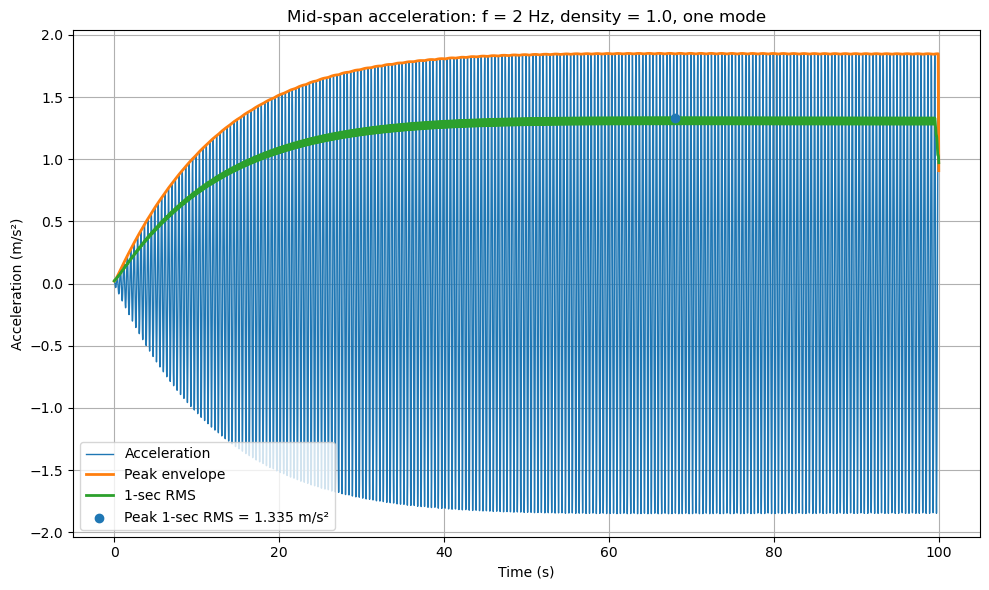

Peak absolute acceleration = 1.8516928198985037
Peak envelope              = 1.8516928198985037
Max 1-sec RMS from result  = 1.3347665024512358
Max 1-sec RMS calculated   = 1.3347665024512358
Time of peak 1-sec RMS     = 68.06
Modified modal mass        = 16000.0


In [44]:
import matplotlib.pyplot as plt
import math
import numpy as np
from biascodefunction import *
# run deterministic/code response

result = run_code_response(
    density=0.86,
    mass_ratio=0.28,              # example mass ratio from stochastic simulation
    length=50.0,
    width=2.0,
    beam_freq=np.array([2.4]),                # first mode = 2 Hz
    modal_damping_ratio=np.array([0.005]),
    linear_mass=500.0,
    hht=0.01,
    t_end=100.0,
    numbers=1,                    # only one mode
    modify_both_modes=False,       # irrelevant here since only one mode
    force_reduction_factor=1
)

t = result["t"]
acc = result["acceleration"]
env = result["envelope"]

# calculate 1-sec RMS
dt = 0.01
rms_1s = sliding_rms(acc, dt=dt, window_sec=1.0)

# peak 1-sec RMS
peak_rms_1s = np.max(rms_1s)
idx_peak_rms = np.argmax(rms_1s)

# plot acceleration, envelope, and RMS
plt.figure(figsize=(10, 6))
plt.plot(t, acc, label="Acceleration", linewidth=1.0)
plt.plot(t, env, label="Peak envelope", linewidth=2.0)
plt.plot(t, rms_1s, label="1-sec RMS", linewidth=2.0)

plt.scatter(
    t[idx_peak_rms],
    rms_1s[idx_peak_rms],
    zorder=5,
    label=f"Peak 1-sec RMS = {peak_rms_1s:.3f} m/s²"
)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.title("Mid-span acceleration: f = 2 Hz, density = 1.0, one mode")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# print useful scalar values
print("Peak absolute acceleration =", result["peak_abs_acceleration"])
print("Peak envelope              =", result["peak_envelope"])
print("Max 1-sec RMS from result  =", result["max_rms_1s"])
print("Max 1-sec RMS calculated   =", peak_rms_1s)
print("Time of peak 1-sec RMS     =", t[idx_peak_rms])
print("Modified modal mass        =", result["modified_modal_mass"])

In [ ]:
# ==================================================
# MC ONLY: one bridge frequency + one density
# Plot distribution/PDF of peak 1-sec RMS
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
from scipy.stats import gaussian_kde

from bias import run_simulation
from biascodefunction import peak_rms_distribution

# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 48
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

target_bf = 2.4        # bridge first frequency
target_beamdamp = 0.005
density = 0.866        # selected density

# --------------------------------------------------
# Convert density to pedestrian numbers
# --------------------------------------------------
BeamFreq = np.array([target_bf, 4 * target_bf])
Beamdamp = np.array([target_beamdamp])

total_peds_float = density * Length * Width
total_peds_int = int(round(total_peds_float))
total_peds_int = max(1, total_peds_int)

Tocity = total_peds_int // 2
Outcity = total_peds_int - Tocity

actual_density = (Tocity + Outcity) / (Length * Width)

print("Bridge frequency =", target_bf)
print("Target density   =", density)
print("Actual density   =", actual_density)
print("Total peds       =", total_peds_int)
print("Tocity, Outcity  =", Tocity, Outcity)

# --------------------------------------------------
# Run MC reference simulations
# --------------------------------------------------
rng = np.random.default_rng(12345)
seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

args_list = [
    (
        int(seeds[i]),
        peddamp,
        pedBodyF,
        BeamFreq,
        Beamdamp,
        Tocity,
        Outcity,
        Length,
        Width
    )
    for i in range(NUM_SIMULATIONS)
]

try:
    mp.set_start_method("spawn")
except RuntimeError:
    pass

ctx = mp.get_context("spawn")

with ctx.Pool(processes=NUM_PROCESSES) as pool:
    results = pool.map(run_simulation, args_list)

# --------------------------------------------------
# Extract acceleration histories and mass ratios
# --------------------------------------------------
accelerations = np.array([r[0] for r in results])
mean_mass_ratios = np.array([r[1] for r in results])

overall_mean_mass_ratio = np.mean(mean_mass_ratios)

print("Acceleration array shape =", accelerations.shape)
print("Mean modal mass ratio    =", overall_mean_mass_ratio)

# --------------------------------------------------
# Remove initial transient
# --------------------------------------------------
steady_start_idx = int(round(steady_start_time / hht))

if steady_start_idx >= accelerations.shape[1]:
    raise ValueError("steady_start_time is longer than acceleration time history.")

accelerations_ss = accelerations[:, steady_start_idx:]

# --------------------------------------------------
# Calculate peak 1-sec RMS distribution
# --------------------------------------------------
rms_histories, peak_rms_values = peak_rms_distribution(
    accelerations_ss,
    dt=hht,
    window_sec=1.0
)

print("Mean peak 1-sec RMS =", np.mean(peak_rms_values))
print("Std peak 1-sec RMS  =", np.std(peak_rms_values))
print("5% peak RMS         =", np.percentile(peak_rms_values, 5))
print("95% peak RMS        =", np.percentile(peak_rms_values, 95))

# --------------------------------------------------
# Plot PDF of peak 1-sec RMS
# --------------------------------------------------
Y = np.asarray(peak_rms_values, dtype=float)
Y = Y[np.isfinite(Y)]

plt.figure(figsize=(8, 5))

plt.hist(
    Y,
    bins=10,
    density=True,
    alpha=0.35,
    edgecolor="black",
    label="MC histogram"
)

if len(Y) >= 2 and np.std(Y) > 0:
    kde = gaussian_kde(Y)
    x_grid = np.linspace(max(0.0, Y.min() * 0.8), Y.max() * 1.2, 300)
    plt.plot(x_grid, kde(x_grid), linewidth=2, label="KDE PDF")

plt.xlabel("Peak 1-sec RMS acceleration")
plt.ylabel("PDF")
plt.title(
    f"MC PDF of Peak 1-sec RMS\n"
    f"fb = {target_bf:.2f} Hz, density = {actual_density:.3f}, "
    f"mean mass ratio = {overall_mean_mass_ratio:.3f}"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
import importlib
import inspect
import os
import time
import bias_trial

importlib.reload(pedestrian)

print("Loaded file:")
print(pedestrian.__file__)

print("\nLast modified:")
print(time.ctime(os.path.getmtime(pedestrian.__file__)))



Loaded file:
\\ad.monash.edu\home\User029\slok0019\Documents\BSEN1990 2023\pedestrian.py

Last modified:
Thu Apr 30 20:37:42 2026



Selected case
-------------
Bridge frequency = 2.400 Hz
Target density   = 0.8330 ped/m²
Actual density   = 0.8300 ped/m²
Total peds       = 83
Tocity, Outcity  = 41, 42

MC output
---------
Acceleration array shape = (24, 10001)
Mean modal mass ratio    = 0.220820

Response statistics
-------------------

Peak 1-sec RMS
  MC mean            = 2.704167
  MC std             = 0.454593
  MC 5%              = 1.876618
  MC median          = 2.786218
  MC 95%             = 3.304841
  Code prediction    = 1.374844
  Mean bias          = 1.966890
  5% bias            = 1.364968
  95% bias           = 2.403793

Peak absolute acceleration
  MC mean            = 3.933265
  MC std             = 0.639878
  MC 5%              = 2.846536
  MC median          = 4.034861
  MC 95%             = 4.865761
  Code prediction    = 1.907292
  Mean bias          = 2.062225
  5% bias            = 1.492449
  95% bias           = 2.551136

95% absolute acceleration
  MC mean            = 2.885559
  MC std     

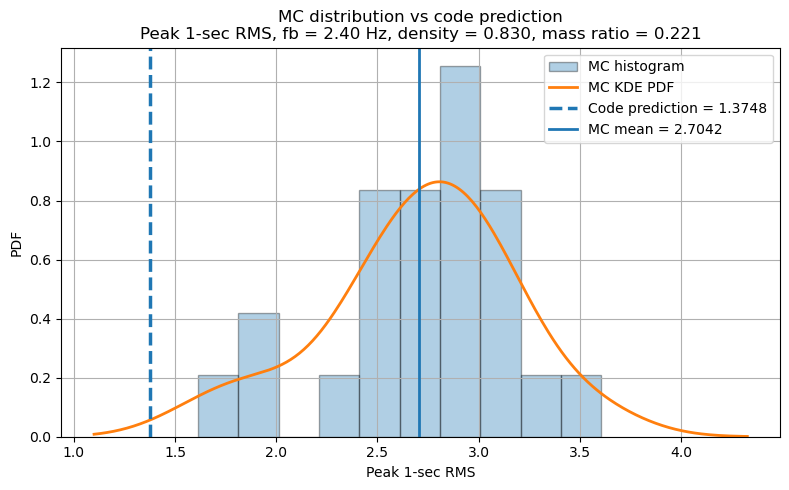

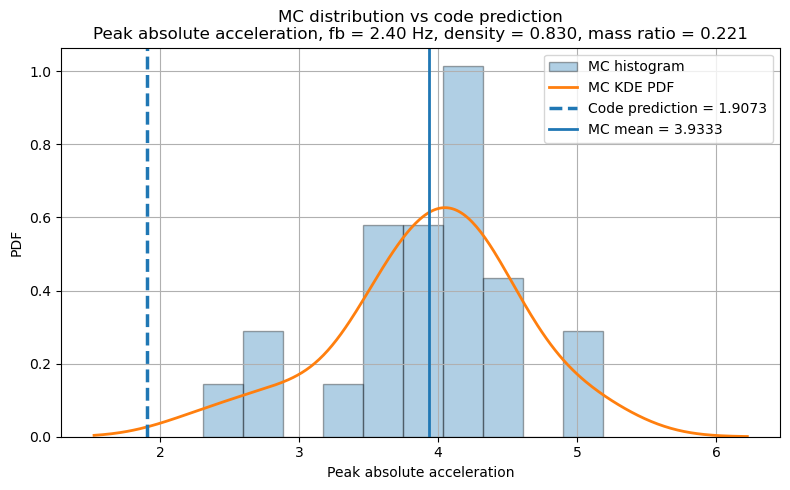

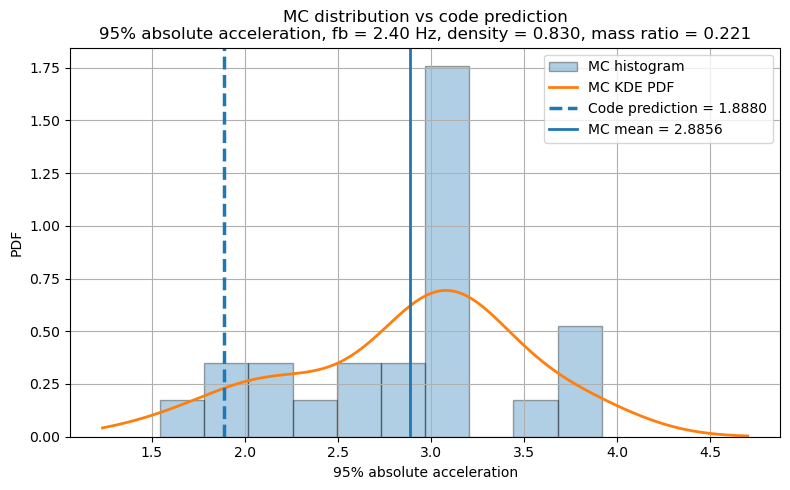

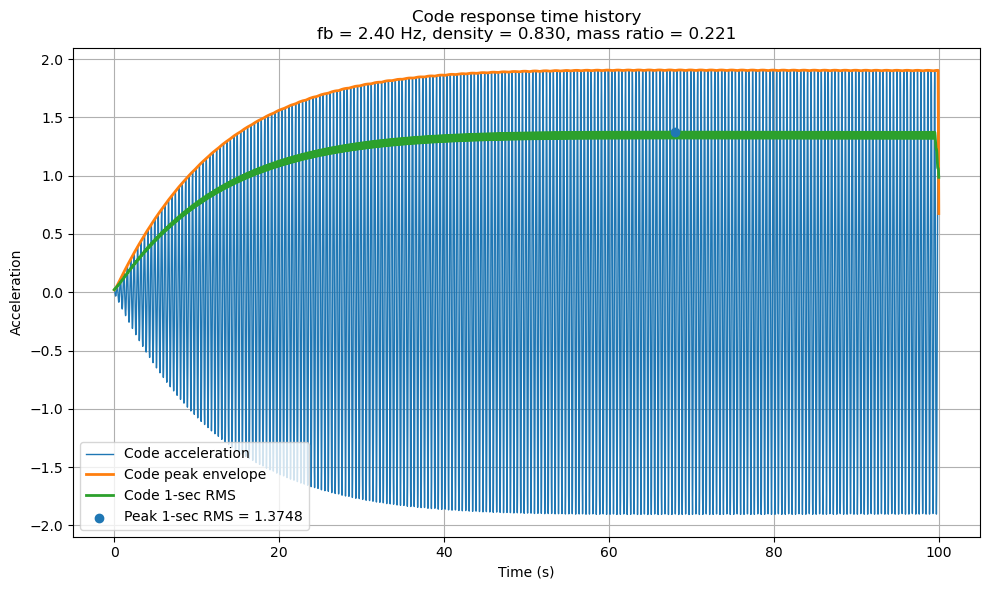

In [48]:
# ==================================================
# MC DISTRIBUTIONS + CODE PREDICTION
# Selected bridge frequency and density
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
from scipy.stats import gaussian_kde

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    sliding_rms
)

# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 24
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

target_bf = 2.4
target_beamdamp = 0.005
density = 0.833

eps = 1e-12

# --------------------------------------------------
# Convert density to pedestrian numbers
# --------------------------------------------------
BeamFreq = np.array([target_bf, 4 * target_bf])
Beamdamp = np.array([target_beamdamp])

total_peds_float = density * Length * Width
total_peds_int = int(round(total_peds_float))
total_peds_int = max(1, total_peds_int)

Tocity = total_peds_int // 2
Outcity = total_peds_int - Tocity

actual_density = (Tocity + Outcity) / (Length * Width)

print("\nSelected case")
print("-------------")
print(f"Bridge frequency = {target_bf:.3f} Hz")
print(f"Target density   = {density:.4f} ped/m²")
print(f"Actual density   = {actual_density:.4f} ped/m²")
print(f"Total peds       = {total_peds_int}")
print(f"Tocity, Outcity  = {Tocity}, {Outcity}")

# --------------------------------------------------
# Run MC reference simulations
# --------------------------------------------------
rng = np.random.default_rng(12345)
seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

args_list = [
    (
        int(seeds[i]),
        peddamp,
        pedBodyF,
        BeamFreq,
        Beamdamp,
        Tocity,
        Outcity,
        Length,
        Width
    )
    for i in range(NUM_SIMULATIONS)
]

try:
    mp.set_start_method("spawn")
except RuntimeError:
    pass

ctx = mp.get_context("spawn")

with ctx.Pool(processes=NUM_PROCESSES) as pool:
    results = pool.map(run_simulation, args_list)

# --------------------------------------------------
# Extract MC acceleration histories and mass ratios
# --------------------------------------------------
accelerations = np.array([r[0] for r in results])
mean_mass_ratios = np.array([r[1] for r in results])

overall_mean_mass_ratio = np.mean(mean_mass_ratios)

print("\nMC output")
print("---------")
print("Acceleration array shape =", accelerations.shape)
print(f"Mean modal mass ratio    = {overall_mean_mass_ratio:.6f}")

# --------------------------------------------------
# Remove initial transient
# --------------------------------------------------
steady_start_idx = int(round(steady_start_time / hht))

if steady_start_idx >= accelerations.shape[1]:
    raise ValueError("steady_start_time is longer than acceleration time history.")

accelerations_ss = accelerations[:, steady_start_idx:]

# --------------------------------------------------
# MC response distributions
# --------------------------------------------------
rms_histories, peak_rms_values = peak_rms_distribution(
    accelerations_ss,
    dt=hht,
    window_sec=1.0
)

peak_abs_values = peak_abs_acc_distribution(
    accelerations_ss
)

p95_abs_values = percentile_acc_distribution(
    accelerations_ss,
    percentile=95,
    use_abs=True
)

mc_distributions = {
    "Peak 1-sec RMS": peak_rms_values,
    "Peak absolute acceleration": peak_abs_values,
    "95% absolute acceleration": p95_abs_values,
}

# --------------------------------------------------
# Run deterministic/code response using same case
# --------------------------------------------------
t_end = accelerations.shape[1] * hht

code_result, code_measures = run_code_response_from_mc_inputs(
    Tocity=Tocity,
    Outcity=Outcity,
    Length=Length,
    Width=Width,
    BeamFreq=BeamFreq,
    Beamdamp=Beamdamp,
    linear_mass=linear_mass,
    hht=hht,
    t_end=t_end,
    mean_mass_ratio=overall_mean_mass_ratio,
    mass_ratio_limit=0.05,
    steady_start_time=steady_start_time,
    numbers=1,
    modify_both_modes=False,
    force_reduction_factor=1.0
)

code_values = {
    "Peak 1-sec RMS": code_measures["peak_1sec_rms"],
    "Peak absolute acceleration": code_measures["peak_abs_acc"],
    "95% absolute acceleration": code_measures["p95_abs_acc"],
}

# --------------------------------------------------
# Print statistics and bias
# Bias = MC response / code response
# --------------------------------------------------
print("\nResponse statistics")
print("-------------------")

for name, Y in mc_distributions.items():

    Y = np.asarray(Y, dtype=float)
    Y = Y[np.isfinite(Y)]

    code_val = code_values[name]

    mc_mean = np.mean(Y)
    mc_std = np.std(Y)
    mc_p5 = np.percentile(Y, 5)
    mc_p50 = np.percentile(Y, 50)
    mc_p95 = np.percentile(Y, 95)

    bias_samples = Y / max(code_val, eps)

    print(f"\n{name}")
    print(f"  MC mean            = {mc_mean:.6f}")
    print(f"  MC std             = {mc_std:.6f}")
    print(f"  MC 5%              = {mc_p5:.6f}")
    print(f"  MC median          = {mc_p50:.6f}")
    print(f"  MC 95%             = {mc_p95:.6f}")
    print(f"  Code prediction    = {code_val:.6f}")
    print(f"  Mean bias          = {np.mean(bias_samples):.6f}")
    print(f"  5% bias            = {np.percentile(bias_samples, 5):.6f}")
    print(f"  95% bias           = {np.percentile(bias_samples, 95):.6f}")

# --------------------------------------------------
# Plot MC distributions with code prediction line
# --------------------------------------------------
for name, Y in mc_distributions.items():

    Y = np.asarray(Y, dtype=float)
    Y = Y[np.isfinite(Y)]

    code_val = code_values[name]

    plt.figure(figsize=(8, 5))

    plt.hist(
        Y,
        bins=10,
        density=True,
        alpha=0.35,
        edgecolor="black",
        label="MC histogram"
    )

    if len(Y) >= 2 and np.std(Y) > 0:
        kde = gaussian_kde(Y)
        x_min = max(0.0, min(Y.min(), code_val) * 0.8)
        x_max = max(Y.max(), code_val) * 1.2
        x_grid = np.linspace(x_min, x_max, 300)
        plt.plot(
            x_grid,
            kde(x_grid),
            linewidth=2,
            label="MC KDE PDF"
        )

    plt.axvline(
        code_val,
        linestyle="--",
        linewidth=2.5,
        label=f"Code prediction = {code_val:.4f}"
    )

    plt.axvline(
        np.mean(Y),
        linestyle="-",
        linewidth=2,
        label=f"MC mean = {np.mean(Y):.4f}"
    )

    plt.xlabel(name)
    plt.ylabel("PDF")
    plt.title(
        f"MC distribution vs code prediction\n"
        f"{name}, fb = {target_bf:.2f} Hz, density = {actual_density:.3f}, "
        f"mass ratio = {overall_mean_mass_ratio:.3f}"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --------------------------------------------------
# Plot deterministic/code time history
# --------------------------------------------------
t = code_result["t"]
acc = code_result["acceleration"]
env = code_result["envelope"]

rms_1s = sliding_rms(acc, dt=hht, window_sec=1.0)

peak_rms_1s = np.max(rms_1s)
idx_peak_rms = np.argmax(rms_1s)

plt.figure(figsize=(10, 6))

plt.plot(t, acc, label="Code acceleration", linewidth=1.0)
plt.plot(t, env, label="Code peak envelope", linewidth=2.0)
plt.plot(t, rms_1s, label="Code 1-sec RMS", linewidth=2.0)

plt.scatter(
    t[idx_peak_rms],
    rms_1s[idx_peak_rms],
    zorder=5,
    label=f"Peak 1-sec RMS = {peak_rms_1s:.4f}"
)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.title(
    f"Code response time history\n"
    f"fb = {target_bf:.2f} Hz, density = {actual_density:.3f}, "
    f"mass ratio = {overall_mean_mass_ratio:.3f}"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

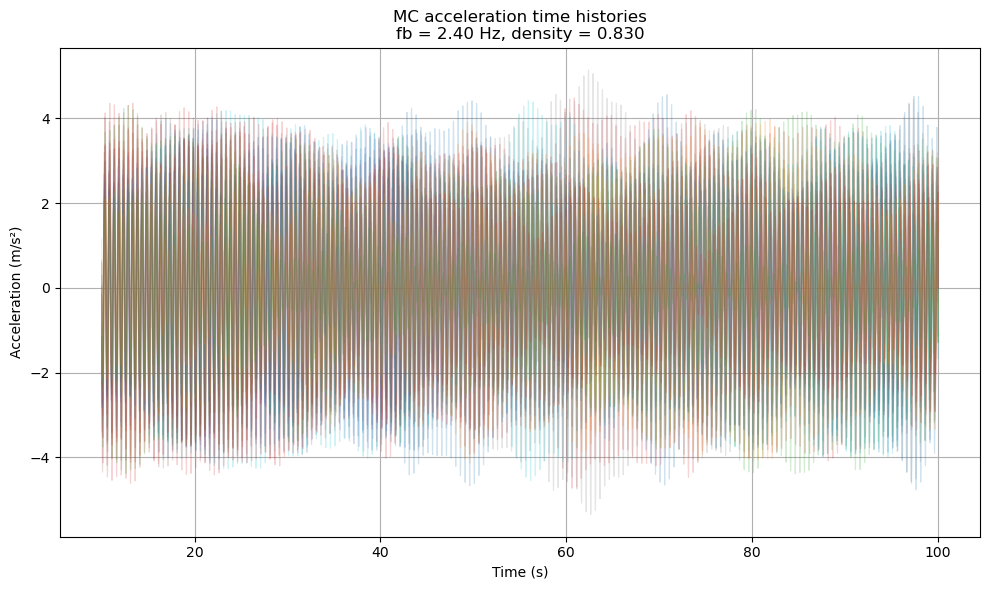

In [69]:
# --------------------------------------------------
# Plot all MC acceleration time histories
# --------------------------------------------------
t_full = np.arange(accelerations.shape[1]) * hht
t_ss = t_full[steady_start_idx:]

plt.figure(figsize=(10, 6))

for i in range(accelerations_ss.shape[0]):
    plt.plot(
        t_ss,
        accelerations_ss[i],
        linewidth=0.8,
        alpha=0.2
    )

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.title(
    f"MC acceleration time histories\n"
    f"fb = {target_bf:.2f} Hz, density = {actual_density:.3f}"
)
plt.grid(True)
plt.tight_layout()
plt.show()

RMS histories shape = (24, 9001)
Total number of 1-sec RMS samples = 216024
Mean of full 1-sec RMS distribution = 1.5725376489104637
Std of full 1-sec RMS distribution  = 0.7365063929533499
5% of full RMS distribution         = 0.2675424306923343
50% of full RMS distribution        = 1.6053586431951985
95% of full RMS distribution        = 2.7286147666776612
99% of full RMS distribution        = 3.038137569567951


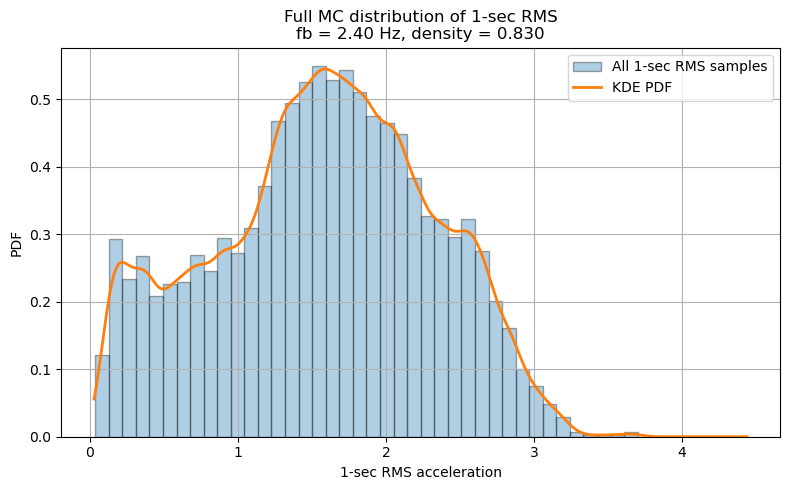

In [70]:
rms_histories, peak_rms_values = peak_rms_distribution(
    accelerations_ss,
    dt=hht,
    window_sec=1.0
)

# --------------------------------------------------
# Construct full 1-sec RMS distribution
# using all N time histories and all time points
# --------------------------------------------------
rms_histories = np.asarray(rms_histories, dtype=float)

print("RMS histories shape =", rms_histories.shape)
# shape = (number of MC simulations, number of RMS time points)

# Flatten all RMS values into one sample
rms_all = rms_histories.ravel()
rms_all = rms_all[np.isfinite(rms_all)]

print("Total number of 1-sec RMS samples =", len(rms_all))

# Summary statistics of the full RMS distribution
print("Mean of full 1-sec RMS distribution =", np.mean(rms_all))
print("Std of full 1-sec RMS distribution  =", np.std(rms_all))
print("5% of full RMS distribution         =", np.percentile(rms_all, 5))
print("50% of full RMS distribution        =", np.percentile(rms_all, 50))
print("95% of full RMS distribution        =", np.percentile(rms_all, 95))
print("99% of full RMS distribution        =", np.percentile(rms_all, 99))

# --------------------------------------------------
# Plot full distribution of 1-sec RMS
# --------------------------------------------------
from scipy.stats import gaussian_kde

Y = np.asarray(rms_all, dtype=float)
Y = Y[np.isfinite(Y)]

plt.figure(figsize=(8, 5))

plt.hist(
    Y,
    bins=40,
    density=True,
    alpha=0.35,
    edgecolor="black",
    label="All 1-sec RMS samples"
)

if len(Y) >= 2 and np.std(Y) > 0:
    kde = gaussian_kde(Y)
    x_grid = np.linspace(max(0.0, Y.min() * 0.8), Y.max() * 1.2, 400)
    plt.plot(x_grid, kde(x_grid), linewidth=2, label="KDE PDF")

plt.xlabel("1-sec RMS acceleration")
plt.ylabel("PDF")
plt.title(
    f"Full MC distribution of 1-sec RMS\n"
    f"fb = {target_bf:.2f} Hz, density = {actual_density:.3f}"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Code 1-sec RMS distribution
---------------------------
Number of RMS samples = 9002
Mean RMS              = 1.253762
Std RMS               = 0.132007
5% RMS                = 0.930204
50% RMS               = 1.303315
95% RMS               = 1.347616
Peak RMS              = 1.350034


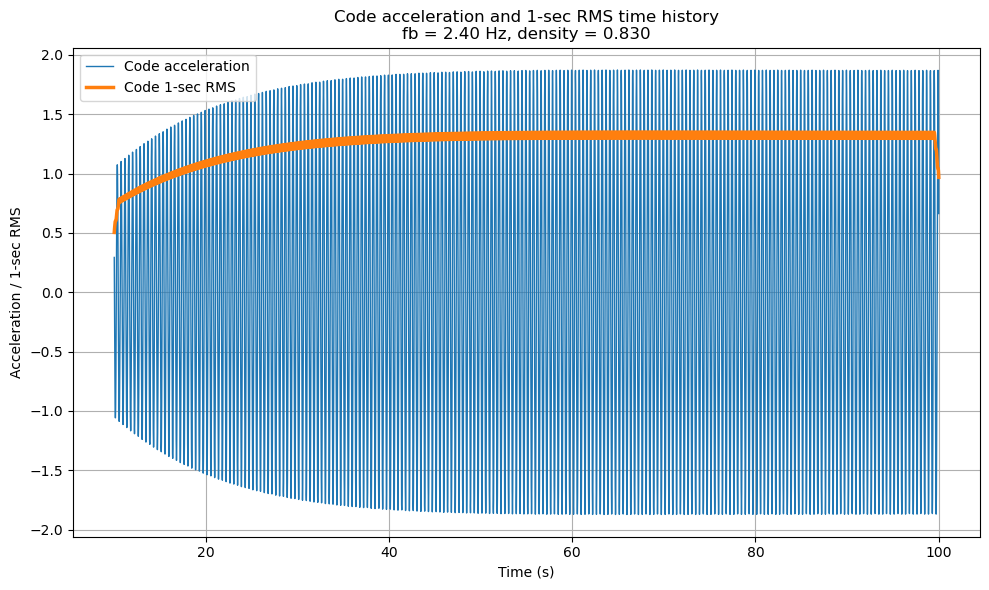

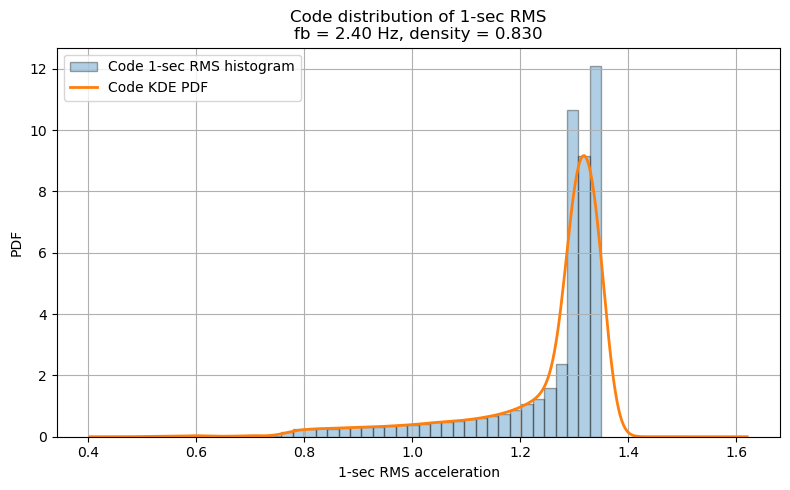

In [71]:
# ==================================================
# CODE MODEL: 1-sec RMS TIME HISTORY AND DISTRIBUTION
# ==================================================

from scipy.stats import gaussian_kde

# Extract code acceleration time history
t_code = code_result["t"]
acc_code = code_result["acceleration"]

# Remove same initial transient from code response
steady_start_idx_code = int(round(steady_start_time / hht))

t_code_ss = t_code[steady_start_idx_code:]
acc_code_ss = acc_code[steady_start_idx_code:]

# Calculate 1-sec RMS time history for code response
rms_code_1s = sliding_rms(
    acc_code_ss,
    dt=hht,
    window_sec=1.0
)

# Time vector for code RMS
t_code_rms = t_code_ss[:len(rms_code_1s)]

# Full code 1-sec RMS distribution
rms_code_all = np.asarray(rms_code_1s, dtype=float)
rms_code_all = rms_code_all[np.isfinite(rms_code_all)]

print("\nCode 1-sec RMS distribution")
print("---------------------------")
print(f"Number of RMS samples = {len(rms_code_all)}")
print(f"Mean RMS              = {np.mean(rms_code_all):.6f}")
print(f"Std RMS               = {np.std(rms_code_all):.6f}")
print(f"5% RMS                = {np.percentile(rms_code_all, 5):.6f}")
print(f"50% RMS               = {np.percentile(rms_code_all, 50):.6f}")
print(f"95% RMS               = {np.percentile(rms_code_all, 95):.6f}")
print(f"Peak RMS              = {np.max(rms_code_all):.6f}")

# --------------------------------------------------
# Plot code acceleration and 1-sec RMS time history
# --------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(
    t_code_ss,
    acc_code_ss,
    linewidth=1.0,
    label="Code acceleration"
)

plt.plot(
    t_code_rms,
    rms_code_1s,
    linewidth=2.5,
    label="Code 1-sec RMS"
)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration / 1-sec RMS")
plt.title(
    f"Code acceleration and 1-sec RMS time history\n"
    f"fb = {target_bf:.2f} Hz, density = {actual_density:.3f}"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot code 1-sec RMS distribution
# --------------------------------------------------
Y_code = rms_code_all

plt.figure(figsize=(8, 5))

plt.hist(
    Y_code,
    bins=40,
    density=True,
    alpha=0.35,
    edgecolor="black",
    label="Code 1-sec RMS histogram"
)

if len(Y_code) >= 2 and np.std(Y_code) > 0:
    kde_code = gaussian_kde(Y_code)
    x_grid = np.linspace(
        max(0.0, Y_code.min() * 0.8),
        Y_code.max() * 1.2,
        400
    )

    plt.plot(
        x_grid,
        kde_code(x_grid),
        linewidth=2,
        label="Code KDE PDF"
    )

plt.xlabel("1-sec RMS acceleration")
plt.ylabel("PDF")
plt.title(
    f"Code distribution of 1-sec RMS\n"
    f"fb = {target_bf:.2f} Hz, density = {actual_density:.3f}"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

RMS histories shape = (24, 9001)


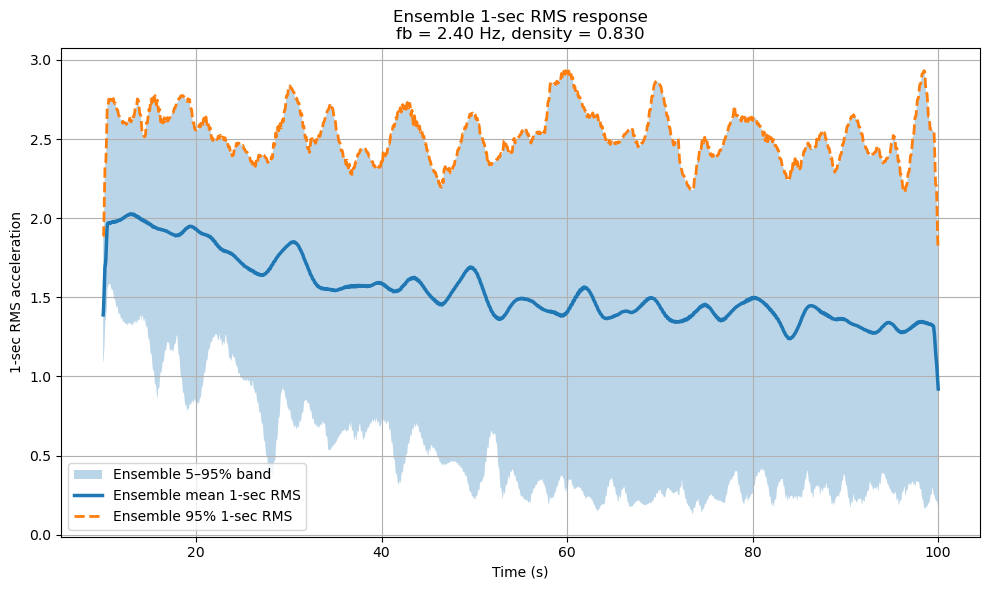


Ensemble RMS summary
--------------------
Mean of ensemble mean RMS      = 1.543003
Peak of ensemble mean RMS      = 2.026887
Mean of ensemble 95% RMS       = 2.526198
Peak of ensemble 95% RMS       = 2.936235
Peak of individual peak RMSes  = 3.606056
Mean of individual peak RMSes  = 2.704167
95% of individual peak RMSes   = 3.304841


In [51]:
# ==================================================
# ENSEMBLE MEAN AND 95% OF 1-SEC RMS TIME HISTORIES
# ==================================================

# If you already have rms_histories from:
# rms_histories, peak_rms_values = peak_rms_distribution(...)
# then use it directly.

rms_histories = np.asarray(rms_histories)

# Shape should be:
# number of simulations x number of time points
print("RMS histories shape =", rms_histories.shape)

# Ensemble statistics at each time instant
rms_mean_time = np.mean(rms_histories, axis=0)
rms_p5_time   = np.percentile(rms_histories, 5, axis=0)
rms_p95_time  = np.percentile(rms_histories, 95, axis=0)

# Time vector for RMS histories
n_rms = rms_histories.shape[1]
t_rms = np.arange(n_rms) * hht

# If RMS histories are based on accelerations_ss, shift time by steady_start_time
t_rms = t_rms + steady_start_time

# --------------------------------------------------
# Plot ensemble mean and 95% band
# --------------------------------------------------
plt.figure(figsize=(10, 6))

plt.fill_between(
    t_rms,
    rms_p5_time,
    rms_p95_time,
    alpha=0.30,
    label="Ensemble 5–95% band"
)

plt.plot(
    t_rms,
    rms_mean_time,
    linewidth=2.5,
    label="Ensemble mean 1-sec RMS"
)

plt.plot(
    t_rms,
    rms_p95_time,
    linestyle="--",
    linewidth=2,
    label="Ensemble 95% 1-sec RMS"
)

plt.xlabel("Time (s)")
plt.ylabel("1-sec RMS acceleration")
plt.title(
    f"Ensemble 1-sec RMS response\n"
    f"fb = {target_bf:.2f} Hz, density = {actual_density:.3f}"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Useful scalar summaries
# --------------------------------------------------
print("\nEnsemble RMS summary")
print("--------------------")
print(f"Mean of ensemble mean RMS      = {np.mean(rms_mean_time):.6f}")
print(f"Peak of ensemble mean RMS      = {np.max(rms_mean_time):.6f}")
print(f"Mean of ensemble 95% RMS       = {np.mean(rms_p95_time):.6f}")
print(f"Peak of ensemble 95% RMS       = {np.max(rms_p95_time):.6f}")
print(f"Peak of individual peak RMSes  = {np.max(peak_rms_values):.6f}")
print(f"Mean of individual peak RMSes  = {np.mean(peak_rms_values):.6f}")
print(f"95% of individual peak RMSes   = {np.percentile(peak_rms_values, 95):.6f}")

In [89]:
import importlib
import pedestrian

importlib.reload(pedestrian)

<module 'pedestrian' from '\\\\ad.monash.edu\\home\\User029\\slok0019\\Documents\\BSEN1990 2023\\pedestrian.py'>

Loaded force-factor database.
Available damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]

Selected case
-------------
Bridge frequency = 4.100 Hz
Target density   = 0.8300 ped/m²
Actual density   = 0.8300 ped/m²
Total peds       = 83
Tocity, Outcity  = 41, 42

MC output
---------
Acceleration array shape = (24, 10001)
Mean modal mass ratio    = 0.218889

Force-factor interpolation input
--------------------------------
MC mean modal mass ratio      = 0.218889
Mass ratio used for x-factor  = 0.218889

--- Simplified direct force factor rule ---
Bridge frequency              = 4.100000 Hz
Interpolated x_freq_ratio     = 1.512195
Interpolated x factor         = 0.196288
Force reduction factor used   = 0.196288
Density kept unchanged?       = True
Tocity, Outcity               = 41, 42

Response statistics
-------------------

Peak 1-sec RMS
  MC mean                 = 0.342637
  MC std                  = 0.031680
  MC 5%                   = 0.307953
  MC median               = 0.34

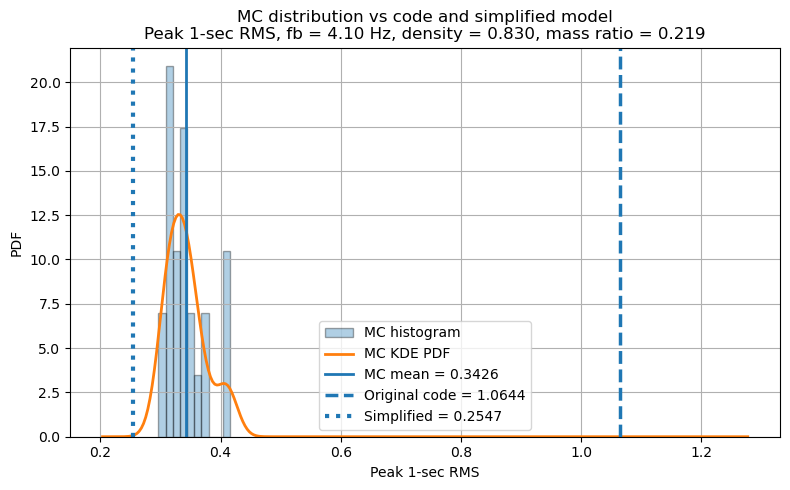

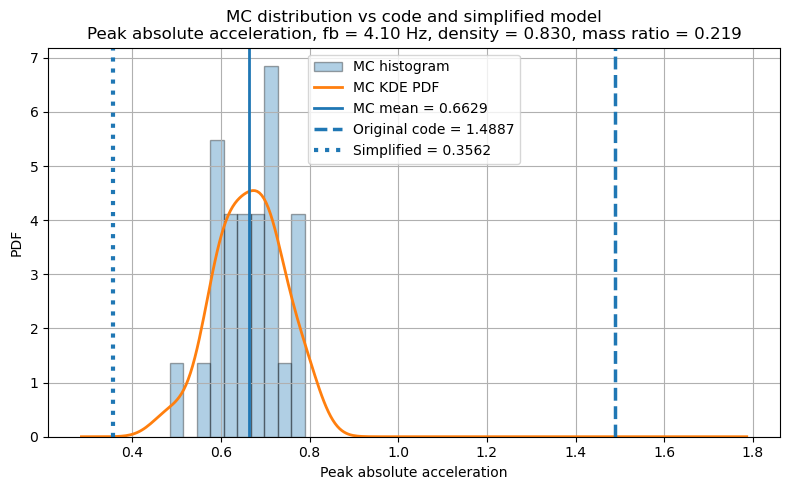

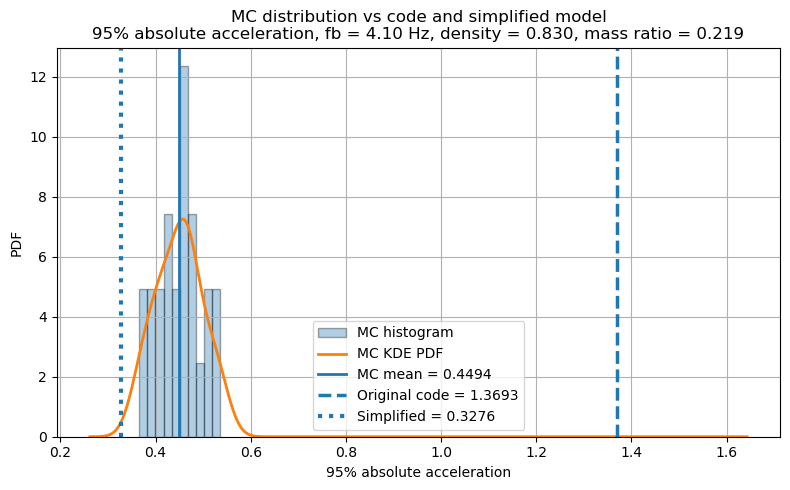

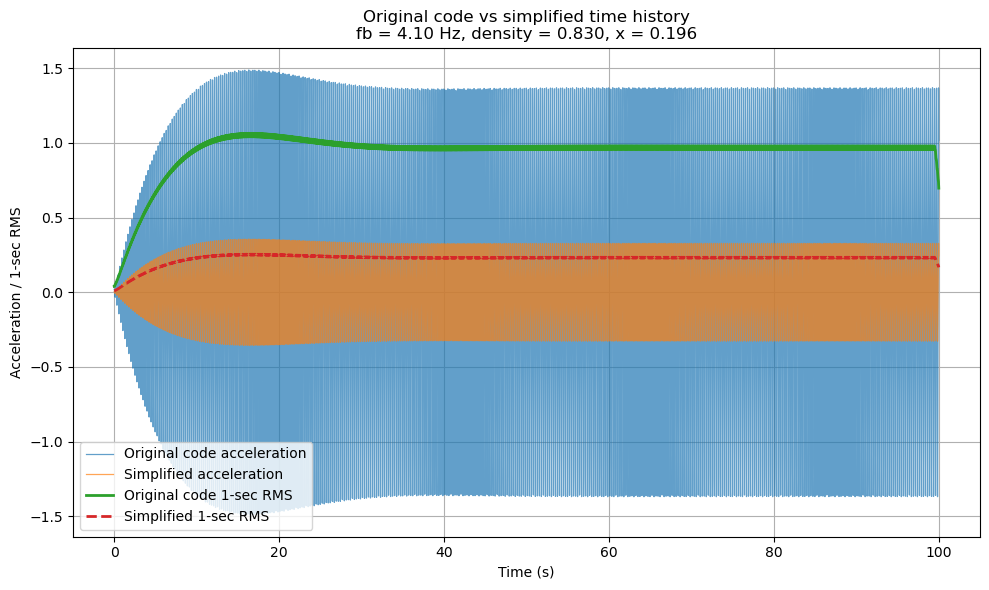

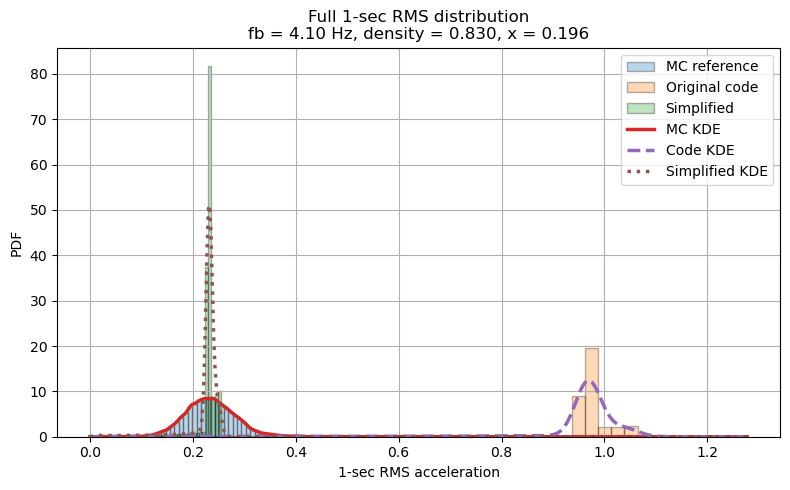


Full 1-sec RMS distribution statistics
--------------------------------------

MC reference
  Mean = 0.234010
  Std  = 0.047892
  5%   = 0.158552
  50%  = 0.232306
  95%  = 0.313829
  Peak = 0.416176

Original code
  Mean = 0.941367
  Std  = 0.143815
  5%   = 0.664849
  50%  = 0.969918
  95%  = 1.042127
  Peak = 1.064358

Simplified
  Mean = 0.225226
  Std  = 0.034408
  5%   = 0.159068
  50%  = 0.232057
  95%  = 0.249333
  Peak = 0.254652

Distribution-based 1-sec RMS bias: MC / model
---------------------------------------------
Original code mean-RMS bias = 0.248585
Simplified mean-RMS bias    = 1.039001

Original code 50% RMS bias  = 0.239511
Simplified 50% RMS bias     = 1.001075

Original code 95% RMS bias  = 0.301143
Simplified 95% RMS bias     = 1.258675


In [97]:
# ==================================================
# MC DISTRIBUTIONS + CODE + SIMPLIFIED PREDICTION
# Selected bridge frequency and density
# ==================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
from scipy.stats import gaussian_kde
import pickle

from bias import run_simulation

from biascodefunction import (
    peak_rms_distribution,
    percentile_acc_distribution,
    peak_abs_acc_distribution,
    run_code_response_from_mc_inputs,
    sliding_rms,
    interpolate_force_factor_exact_point
)

# --------------------------------------------------
# USER SETTINGS
# --------------------------------------------------
NUM_SIMULATIONS = 24
NUM_PROCESSES = 12

hht = 0.01
steady_start_time = 10.0
linear_mass = 500.0

peddamp = 0.30
pedBodyF = 3.10

Length = 50.0
Width = 2.0

target_bf = 4.1
target_beamdamp = 0.005
density = 0.83

eps = 1e-12

# Force-factor database
FORCE_FACTOR_FILE = "forcefactors_bridgeF_bridgedamp.pkl"

# Mass-ratio cap for interpolation database
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


# --------------------------------------------------
# Helper: cap MC mass ratio inside interpolation range
# --------------------------------------------------
def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# Load force-factor database
# --------------------------------------------------
with open(FORCE_FACTOR_FILE, "rb") as f:
    ff_data = pickle.load(f)

ff_results_all = ff_data["results_all"]
ff_densities = ff_data["densities"]
ff_bridge_frequencies = ff_data["bridge_frequencies"]
ff_damping_values = ff_data["damping_values"]
ff_pedBodyF = ff_data["pedBodyF"]

print("Loaded force-factor database.")
print("Available damping values:", ff_damping_values)


# --------------------------------------------------
# Convert density to pedestrian numbers
# --------------------------------------------------
BeamFreq = np.array([target_bf, 4 * target_bf])
Beamdamp = np.array([target_beamdamp])

total_peds_float = density * Length * Width
total_peds_int = int(round(total_peds_float))
total_peds_int = max(1, total_peds_int)

Tocity = total_peds_int // 2
Outcity = total_peds_int - Tocity

actual_density = (Tocity + Outcity) / (Length * Width)

print("\nSelected case")
print("-------------")
print(f"Bridge frequency = {target_bf:.3f} Hz")
print(f"Target density   = {density:.4f} ped/m²")
print(f"Actual density   = {actual_density:.4f} ped/m²")
print(f"Total peds       = {total_peds_int}")
print(f"Tocity, Outcity  = {Tocity}, {Outcity}")


# --------------------------------------------------
# Run MC reference simulations
# --------------------------------------------------
rng = np.random.default_rng(12345)
seeds = rng.integers(0, 2**31 - 1, size=NUM_SIMULATIONS)

args_list = [
    (
        int(seeds[i]),
        peddamp,
        pedBodyF,
        BeamFreq,
        Beamdamp,
        Tocity,
        Outcity,
        Length,
        Width
    )
    for i in range(NUM_SIMULATIONS)
]

try:
    mp.set_start_method("spawn")
except RuntimeError:
    pass

ctx = mp.get_context("spawn")

with ctx.Pool(processes=NUM_PROCESSES) as pool:
    results = pool.map(run_simulation, args_list)


# --------------------------------------------------
# Extract MC acceleration histories and mass ratios
# --------------------------------------------------
accelerations = np.array([r[0] for r in results])
mean_mass_ratios = np.array([r[1] for r in results])

overall_mean_mass_ratio = np.mean(mean_mass_ratios)

print("\nMC output")
print("---------")
print("Acceleration array shape =", accelerations.shape)
print(f"Mean modal mass ratio    = {overall_mean_mass_ratio:.6f}")


# --------------------------------------------------
# Remove initial transient
# --------------------------------------------------
steady_start_idx = int(round(steady_start_time / hht))

if steady_start_idx >= accelerations.shape[1]:
    raise ValueError("steady_start_time is longer than acceleration time history.")

accelerations_ss = accelerations[:, steady_start_idx:]


# --------------------------------------------------
# MC response distributions
# --------------------------------------------------
rms_histories, peak_rms_values = peak_rms_distribution(
    accelerations_ss,
    dt=hht,
    window_sec=1.0
)

peak_abs_values = peak_abs_acc_distribution(
    accelerations_ss
)

p95_abs_values = percentile_acc_distribution(
    accelerations_ss,
    percentile=95,
    use_abs=True
)

mc_distributions = {
    "Peak 1-sec RMS": peak_rms_values,
    "Peak absolute acceleration": peak_abs_values,
    "95% absolute acceleration": p95_abs_values,
}


# --------------------------------------------------
# Original deterministic/code model
# --------------------------------------------------
t_end = accelerations.shape[1] * hht

code_result, code_measures = run_code_response_from_mc_inputs(
    Tocity=Tocity,
    Outcity=Outcity,
    Length=Length,
    Width=Width,
    BeamFreq=BeamFreq,
    Beamdamp=Beamdamp,
    linear_mass=linear_mass,
    hht=hht,
    t_end=t_end,
    mean_mass_ratio=overall_mean_mass_ratio,
    mass_ratio_limit=0.05,
    steady_start_time=steady_start_time,
    numbers=1,
    modify_both_modes=False,
    force_reduction_factor=1.0
)


# --------------------------------------------------
# Simplified model
# Interpolate force factor using MC mean modal mass ratio
# --------------------------------------------------
target_mass_ratio_used = cap_mass_ratio_for_interpolation(
    overall_mean_mass_ratio
)

print("\nForce-factor interpolation input")
print("--------------------------------")
print(f"MC mean modal mass ratio      = {overall_mean_mass_ratio:.6f}")
print(f"Mass ratio used for x-factor  = {target_mass_ratio_used:.6f}")

x_freq_ratio, x_factor, interp_details = interpolate_force_factor_exact_point(
    results_all=ff_results_all,
    target_bf=target_bf/2,
    target_beamdamp=target_beamdamp,
    target_mass_ratio=target_mass_ratio_used,
    damping_values=ff_damping_values,
    densities=ff_densities,
    bridge_frequencies=ff_bridge_frequencies,
    pedBodyF=ff_pedBodyF
)

force_reduction_factor_used = x_factor

Tocity_simplified = Tocity
Outcity_simplified = Outcity

print("\n--- Simplified direct force factor rule ---")
print(f"Bridge frequency              = {target_bf:.6f} Hz")
print(f"Interpolated x_freq_ratio     = {x_freq_ratio:.6f}")
print(f"Interpolated x factor         = {x_factor:.6f}")
print(f"Force reduction factor used   = {force_reduction_factor_used:.6f}")
print(f"Density kept unchanged?       = {True}")
print(f"Tocity, Outcity               = {Tocity_simplified}, {Outcity_simplified}")

simplified_result, simplified_measures = run_code_response_from_mc_inputs(
    Tocity=Tocity_simplified,
    Outcity=Outcity_simplified,
    Length=Length,
    Width=Width,
    BeamFreq=BeamFreq,
    Beamdamp=Beamdamp,
    linear_mass=linear_mass,
    hht=hht,
    t_end=t_end,
    mean_mass_ratio=0.0,
    mass_ratio_limit=0.05,
    steady_start_time=steady_start_time,
    numbers=1,
    modify_both_modes=False,
    force_reduction_factor=force_reduction_factor_used
)


# --------------------------------------------------
# Scalar values from code and simplified models
# --------------------------------------------------
code_values = {
    "Peak 1-sec RMS": code_measures["peak_1sec_rms"],
    "Peak absolute acceleration": code_measures["peak_abs_acc"],
    "95% absolute acceleration": code_measures["p95_abs_acc"],
}

simplified_values = {
    "Peak 1-sec RMS": simplified_measures["peak_1sec_rms"],
    "Peak absolute acceleration": simplified_measures["peak_abs_acc"],
    "95% absolute acceleration": simplified_measures["p95_abs_acc"],
}


# --------------------------------------------------
# Print statistics and bias
# Bias = MC response / model response
# --------------------------------------------------
print("\nResponse statistics")
print("-------------------")

for name, Y in mc_distributions.items():

    Y = np.asarray(Y, dtype=float)
    Y = Y[np.isfinite(Y)]

    code_val = code_values[name]
    simp_val = simplified_values[name]

    B_code = Y / max(code_val, eps)
    B_simp = Y / max(simp_val, eps)

    print(f"\n{name}")
    print(f"  MC mean                 = {np.mean(Y):.6f}")
    print(f"  MC std                  = {np.std(Y):.6f}")
    print(f"  MC 5%                   = {np.percentile(Y, 5):.6f}")
    print(f"  MC median               = {np.percentile(Y, 50):.6f}")
    print(f"  MC 95%                  = {np.percentile(Y, 95):.6f}")

    print(f"  Original code prediction = {code_val:.6f}")
    print(f"  Simplified prediction    = {simp_val:.6f}")

    print(f"  Code mean bias           = {np.mean(B_code):.6f}")
    print(f"  Code 5-95% bias          = [{np.percentile(B_code, 5):.6f}, {np.percentile(B_code, 95):.6f}]")

    print(f"  Simplified mean bias     = {np.mean(B_simp):.6f}")
    print(f"  Simplified 5-95% bias    = [{np.percentile(B_simp, 5):.6f}, {np.percentile(B_simp, 95):.6f}]")


# --------------------------------------------------
# Plot MC distributions with code and simplified lines
# --------------------------------------------------
for name, Y in mc_distributions.items():

    Y = np.asarray(Y, dtype=float)
    Y = Y[np.isfinite(Y)]

    code_val = code_values[name]
    simp_val = simplified_values[name]

    plt.figure(figsize=(8, 5))

    plt.hist(
        Y,
        bins=10,
        density=True,
        alpha=0.35,
        edgecolor="black",
        label="MC histogram"
    )

    if len(Y) >= 2 and np.std(Y) > 0:
        kde = gaussian_kde(Y)

        x_min = max(0.0, min(Y.min(), code_val, simp_val) * 0.8)
        x_max = max(Y.max(), code_val, simp_val) * 1.2

        x_grid = np.linspace(x_min, x_max, 300)

        plt.plot(
            x_grid,
            kde(x_grid),
            linewidth=2,
            label="MC KDE PDF"
        )

    plt.axvline(
        np.mean(Y),
        linestyle="-",
        linewidth=2,
        label=f"MC mean = {np.mean(Y):.4f}"
    )

    plt.axvline(
        code_val,
        linestyle="--",
        linewidth=2.5,
        label=f"Original code = {code_val:.4f}"
    )

    plt.axvline(
        simp_val,
        linestyle=":",
        linewidth=3.0,
        label=f"Simplified = {simp_val:.4f}"
    )

    plt.xlabel(name)
    plt.ylabel("PDF")
    plt.title(
        f"MC distribution vs code and simplified model\n"
        f"{name}, fb = {target_bf:.2f} Hz, density = {actual_density:.3f}, "
        f"mass ratio = {overall_mean_mass_ratio:.3f}"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Plot deterministic time histories:
# original code vs simplified
# --------------------------------------------------
t_code = code_result["t"]
acc_code = code_result["acceleration"]
env_code = code_result["envelope"]

t_simp = simplified_result["t"]
acc_simp = simplified_result["acceleration"]
env_simp = simplified_result["envelope"]

rms_code_1s = sliding_rms(acc_code, dt=hht, window_sec=1.0)
rms_simp_1s = sliding_rms(acc_simp, dt=hht, window_sec=1.0)

t_rms_code = t_code[:len(rms_code_1s)]
t_rms_simp = t_simp[:len(rms_simp_1s)]

plt.figure(figsize=(10, 6))

plt.plot(
    t_code,
    acc_code,
    label="Original code acceleration",
    linewidth=0.9,
    alpha=0.7
)

plt.plot(
    t_simp,
    acc_simp,
    label="Simplified acceleration",
    linewidth=0.9,
    alpha=0.7
)

plt.plot(
    t_rms_code,
    rms_code_1s,
    label="Original code 1-sec RMS",
    linewidth=2.0
)

plt.plot(
    t_rms_simp,
    rms_simp_1s,
    label="Simplified 1-sec RMS",
    linewidth=2.0,
    linestyle="--"
)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration / 1-sec RMS")
plt.title(
    f"Original code vs simplified time history\n"
    f"fb = {target_bf:.2f} Hz, density = {actual_density:.3f}, "
    f"x = {force_reduction_factor_used:.3f}"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Full 1-sec RMS distribution:
# MC reference vs original code vs simplified
# --------------------------------------------------
rms_ref_all = np.asarray(rms_histories, dtype=float).ravel()
rms_ref_all = rms_ref_all[np.isfinite(rms_ref_all)]

rms_code_all = np.asarray(rms_code_1s, dtype=float).ravel()
rms_code_all = rms_code_all[np.isfinite(rms_code_all)]

rms_simp_all = np.asarray(rms_simp_1s, dtype=float).ravel()
rms_simp_all = rms_simp_all[np.isfinite(rms_simp_all)]

plt.figure(figsize=(8, 5))

plt.hist(
    rms_ref_all,
    bins=40,
    density=True,
    alpha=0.30,
    edgecolor="black",
    label="MC reference"
)

plt.hist(
    rms_code_all,
    bins=40,
    density=True,
    alpha=0.30,
    edgecolor="black",
    label="Original code"
)

plt.hist(
    rms_simp_all,
    bins=40,
    density=True,
    alpha=0.30,
    edgecolor="black",
    label="Simplified"
)

x_max = max(
    np.max(rms_ref_all),
    np.max(rms_code_all),
    np.max(rms_simp_all)
) * 1.2

x_grid = np.linspace(0.0, x_max, 500)

if len(rms_ref_all) >= 2 and np.std(rms_ref_all) > 0:
    kde_ref = gaussian_kde(rms_ref_all)
    plt.plot(
        x_grid,
        kde_ref(x_grid),
        linewidth=2.5,
        label="MC KDE"
    )

if len(rms_code_all) >= 2 and np.std(rms_code_all) > 0:
    kde_code = gaussian_kde(rms_code_all)
    plt.plot(
        x_grid,
        kde_code(x_grid),
        linewidth=2.5,
        linestyle="--",
        label="Code KDE"
    )

if len(rms_simp_all) >= 2 and np.std(rms_simp_all) > 0:
    kde_simp = gaussian_kde(rms_simp_all)
    plt.plot(
        x_grid,
        kde_simp(x_grid),
        linewidth=2.5,
        linestyle=":",
        label="Simplified KDE"
    )

plt.xlabel("1-sec RMS acceleration")
plt.ylabel("PDF")
plt.title(
    f"Full 1-sec RMS distribution\n"
    f"fb = {target_bf:.2f} Hz, density = {actual_density:.3f}, "
    f"x = {force_reduction_factor_used:.3f}"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Distribution-based RMS bias
# --------------------------------------------------
B_code_mean = np.mean(rms_ref_all) / max(np.mean(rms_code_all), eps)
B_simp_mean = np.mean(rms_ref_all) / max(np.mean(rms_simp_all), eps)

B_code_p50 = np.percentile(rms_ref_all, 50) / max(np.percentile(rms_code_all, 50), eps)
B_simp_p50 = np.percentile(rms_ref_all, 50) / max(np.percentile(rms_simp_all, 50), eps)

B_code_p95 = np.percentile(rms_ref_all, 95) / max(np.percentile(rms_code_all, 95), eps)
B_simp_p95 = np.percentile(rms_ref_all, 95) / max(np.percentile(rms_simp_all, 95), eps)

print("\nFull 1-sec RMS distribution statistics")
print("--------------------------------------")

for label, arr in [
    ("MC reference", rms_ref_all),
    ("Original code", rms_code_all),
    ("Simplified", rms_simp_all)
]:
    print(f"\n{label}")
    print(f"  Mean = {np.mean(arr):.6f}")
    print(f"  Std  = {np.std(arr):.6f}")
    print(f"  5%   = {np.percentile(arr, 5):.6f}")
    print(f"  50%  = {np.percentile(arr, 50):.6f}")
    print(f"  95%  = {np.percentile(arr, 95):.6f}")
    print(f"  Peak = {np.max(arr):.6f}")

print("\nDistribution-based 1-sec RMS bias: MC / model")
print("---------------------------------------------")
print(f"Original code mean-RMS bias = {B_code_mean:.6f}")
print(f"Simplified mean-RMS bias    = {B_simp_mean:.6f}")

print(f"\nOriginal code 50% RMS bias  = {B_code_p50:.6f}")
print(f"Simplified 50% RMS bias     = {B_simp_p50:.6f}")

print(f"\nOriginal code 95% RMS bias  = {B_code_p95:.6f}")
print(f"Simplified 95% RMS bias     = {B_simp_p95:.6f}")

In [78]:
# ==================================================
# INTERPOLATE FORCE MODIFICATION FACTOR
# for selected bridge frequency and mass ratio
# ==================================================

import pickle
import numpy as np

from biascodefunction import interpolate_force_factor_exact_point

# --------------------------------------------------
# USER INPUTS
# --------------------------------------------------
FORCE_FACTOR_FILE = "forcefactors_bridgeF_bridgedamp.pkl"

selected_bf = 2.00          # bridge frequency you want
selected_beamdamp = 0.005   # damping ratio you want
selected_mass_ratio = 0.2  # mean modal mass ratio you want

# --------------------------------------------------
# MASS RATIO CAPS
# use the same limits as your database
# --------------------------------------------------
MR_MIN_DATABASE = 0.0089
MR_MIN_USED = 0.0090
MR_MAX_DATABASE = 0.2954
MR_MAX_USED = 0.29


def cap_mass_ratio_for_interpolation(mc_mass_ratio):
    mc_mass_ratio = float(mc_mass_ratio)

    if mc_mass_ratio < MR_MIN_DATABASE:
        return MR_MIN_USED
    elif mc_mass_ratio > MR_MAX_DATABASE:
        return MR_MAX_USED
    else:
        return mc_mass_ratio


# --------------------------------------------------
# LOAD FORCE FACTOR DATABASE
# --------------------------------------------------
with open(FORCE_FACTOR_FILE, "rb") as f:
    ff_data = pickle.load(f)

ff_results_all = ff_data["results_all"]
ff_densities = ff_data["densities"]
ff_bridge_frequencies = ff_data["bridge_frequencies"]
ff_damping_values = ff_data["damping_values"]
ff_pedBodyF = ff_data["pedBodyF"]

# --------------------------------------------------
# APPLY MASS RATIO CAP
# --------------------------------------------------
selected_mass_ratio_used = cap_mass_ratio_for_interpolation(
    selected_mass_ratio
)

# --------------------------------------------------
# INTERPOLATE FACTOR
# --------------------------------------------------
x_freq_ratio, x_factor, interp_details = interpolate_force_factor_exact_point(
    results_all=ff_results_all,
    target_bf=selected_bf,
    target_beamdamp=selected_beamdamp,
    target_mass_ratio=selected_mass_ratio_used,
    damping_values=ff_damping_values,
    densities=ff_densities,
    bridge_frequencies=ff_bridge_frequencies,
    pedBodyF=ff_pedBodyF
)

# --------------------------------------------------
# PRINT RESULT
# --------------------------------------------------
print("\n--- Interpolated force modification factor ---")
print(f"Selected bridge frequency       = {selected_bf:.6f} Hz")
print(f"Selected damping ratio          = {selected_beamdamp:.6f}")
print(f"Input mass ratio                = {selected_mass_ratio:.6f}")
print(f"Mass ratio used for interp.     = {selected_mass_ratio_used:.6f}")
print(f"x_freq_ratio = pedBodyF / bf    = {x_freq_ratio:.6f}")
print(f"Interpolated x factor           = {x_factor:.6f}")

print("\nInterpolation details:")
print(interp_details)


--- Interpolated force modification factor ---
Selected bridge frequency       = 2.000000 Hz
Selected damping ratio          = 0.005000
Input mass ratio                = 0.200000
Mass ratio used for interp.     = 0.200000
x_freq_ratio = pedBodyF / bf    = 1.550000
Interpolated x factor           = 0.218827

Interpolation details:
{'lower_damp': np.float64(0.005), 'upper_damp': np.float64(0.005), 'ff_lower': np.float64(0.21882689538143218), 'ff_upper': np.float64(0.21882689538143218), 'damping_weight': 0.0, 'mr_grid_lower': array([0.008862  , 0.05299385, 0.1003857 , 0.1477    , 0.2008594 ,
       0.24812774, 0.2954    ]), 'ff_grid_lower': array([0.78931652, 0.42056948, 0.30505139, 0.25177592, 0.21828547,
       0.19946886, 0.18624571]), 'mr_grid_upper': array([0.008862  , 0.05299385, 0.1003857 , 0.1477    , 0.2008594 ,
       0.24812774, 0.2954    ]), 'ff_grid_upper': array([0.78931652, 0.42056948, 0.30505139, 0.25177592, 0.21828547,
       0.19946886, 0.18624571])}


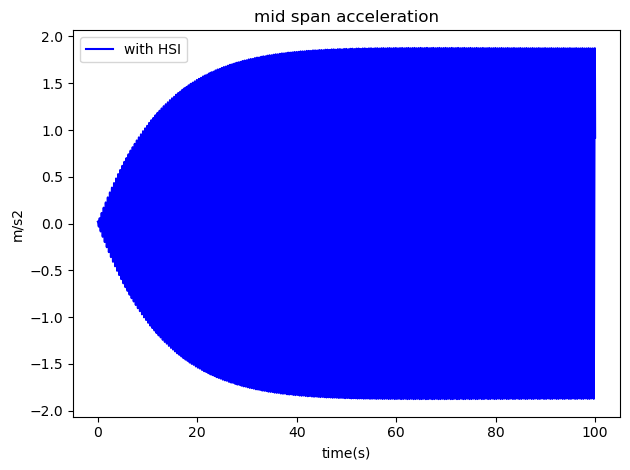

In [68]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import math
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq = np.array([2.4,9.6])  #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2



numbers = 2 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

ModalMass = 1.24* linearMass*length/2


def curve1(x):
    return np.sin(np.pi*x/length)

def curve2(x):
    return np.sin(2*np.pi*x/length)

hht = 0.01
t_end = 100 
func_list=[curve1,curve2] 
modalmass = [ModalMass,ModalMass]
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12


Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,
    freq = beamFreq,
      )                   #modes


         
density = 0.83

t, u, du, ddu = Newmarksuper_Code(
    Bridge,
    numbers,
    length,
    hht,
    t_end,
    width,
    beamFreq,        # walking frequency fs
    density,            # density ped/m²
    modalDampingRatio,
    density*length*width,
    length * width, # deck area S
    modalmass,
    func_list
)
accn_hsi = accdyn_super_social(Bridge,ddu ,x_interested,modalmass,func_list)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


plt.plot(t,accn_hsi,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
plt.tight_layout()
#plt.savefig("All In one", format='pdf', dpi=300)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)'''

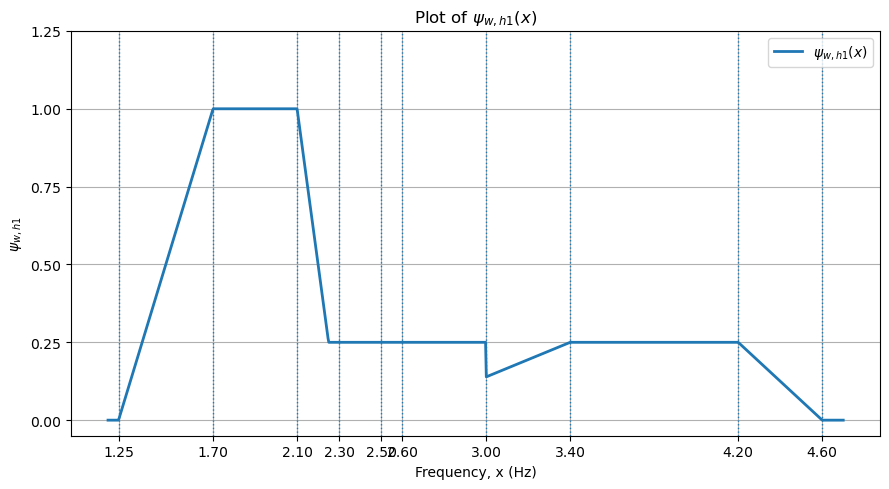

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def psi_w_h1(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Minimum rule:
    # If first vertical frequency is between 2.25 and 3.0 Hz,
    # psi_w should not be less than 0.25.
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# x range for plotting
x_vals = np.linspace(1.2, 4.7, 1000)
y_vals = psi_w_h1(x_vals)

# plot
plt.figure(figsize=(9, 5))
plt.plot(x_vals, y_vals, linewidth=2, label=r'$\psi_{w,h1}(x)$')



plt.axvline(1.25, linestyle=':', linewidth=1)
plt.axvline(1.70, linestyle=':', linewidth=1)
plt.axvline(2.10, linestyle=':', linewidth=1)
plt.axvline(2.30, linestyle=':', linewidth=1)
plt.axvline(2.50, linestyle=':', linewidth=1)
plt.axvline(2.60, linestyle=':', linewidth=1)
plt.axvline(3.00, linestyle=':', linewidth=1)
plt.axvline(3.40, linestyle=':', linewidth=1)
plt.axvline(4.20, linestyle=':', linewidth=1)
plt.axvline(4.60, linestyle=':', linewidth=1)

# X-axis labels only at your selected frequencies
x_ticks = [1.25, 1.70, 2.10, 2.30, 2.50, 2.60, 3.00, 3.40, 4.20, 4.60]
plt.xticks(x_ticks, [f"{x:.2f}" for x in x_ticks])

# Y-axis labels at 0.25 intervals
plt.yticks(np.arange(0, 1.25 + 0.25, 0.25))

plt.xlabel('Frequency, x (Hz)')
plt.ylabel(r'$\psi_{w,h1}$')
plt.title(r'Plot of $\psi_{w,h1}(x)$')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Loading new factor file: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.015_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.025_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.030_0S_bias_summary.pkl
Loading new factor file: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.1667_damp

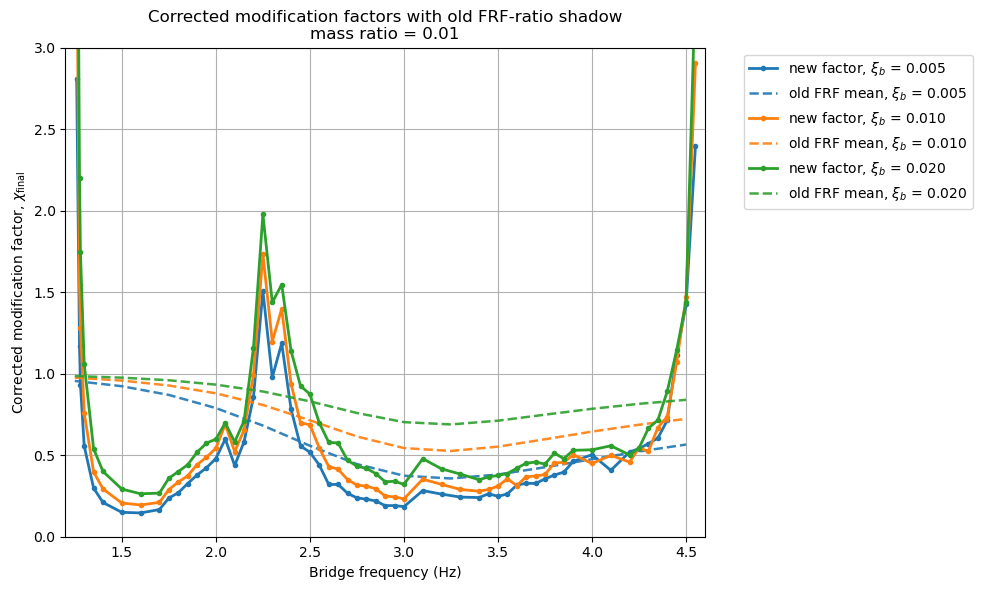

Saved: compare_damping_old_FRF_shadow_massratio0.05.png


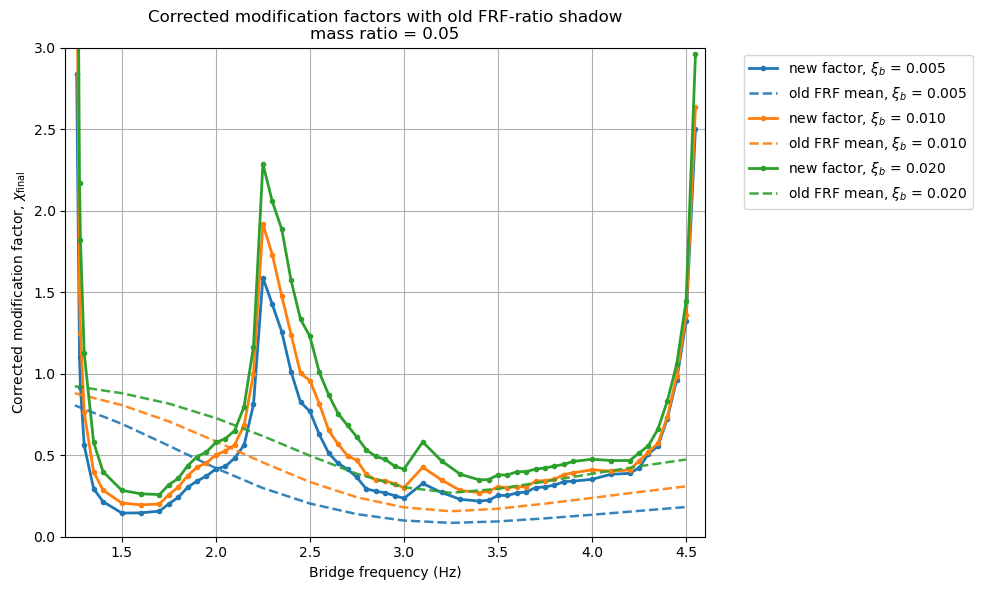

Saved: compare_damping_old_FRF_shadow_massratio0.10.png


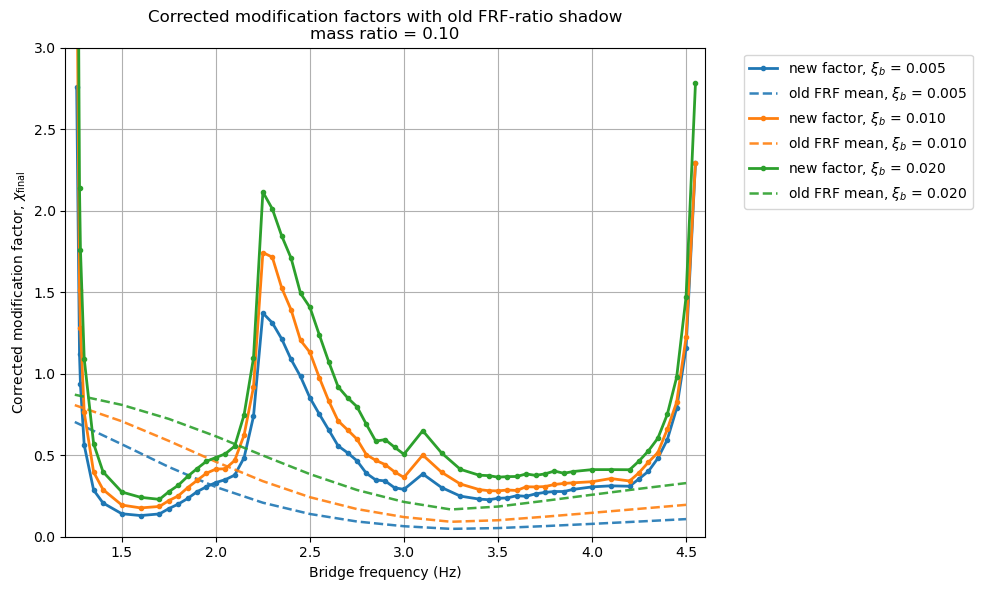

Saved: compare_damping_old_FRF_shadow_massratio0.15.png


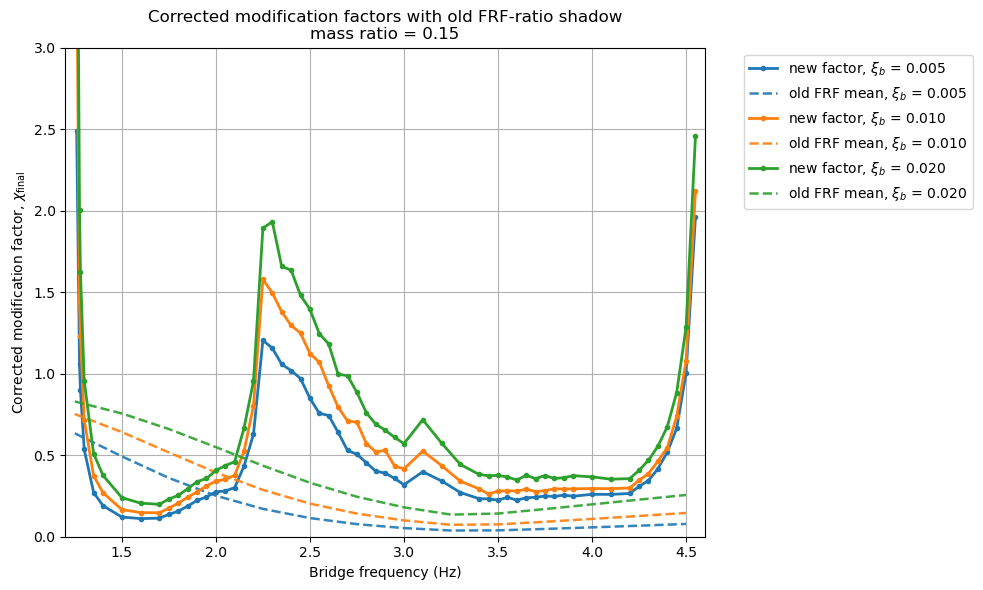

Saved: compare_damping_old_FRF_shadow_massratio0.20.png


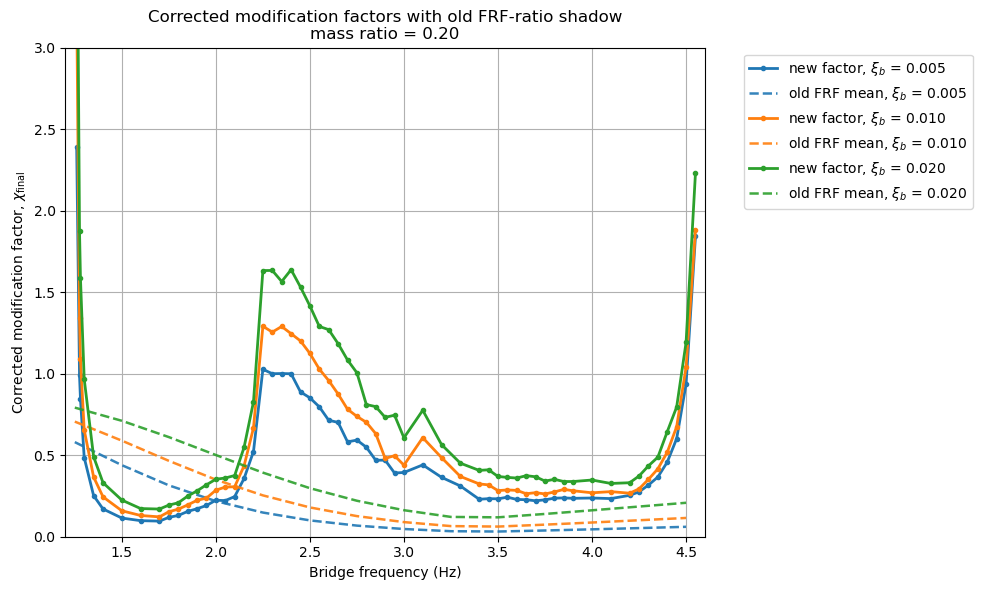

Saved: compare_damping_old_FRF_shadow_massratio0.25.png


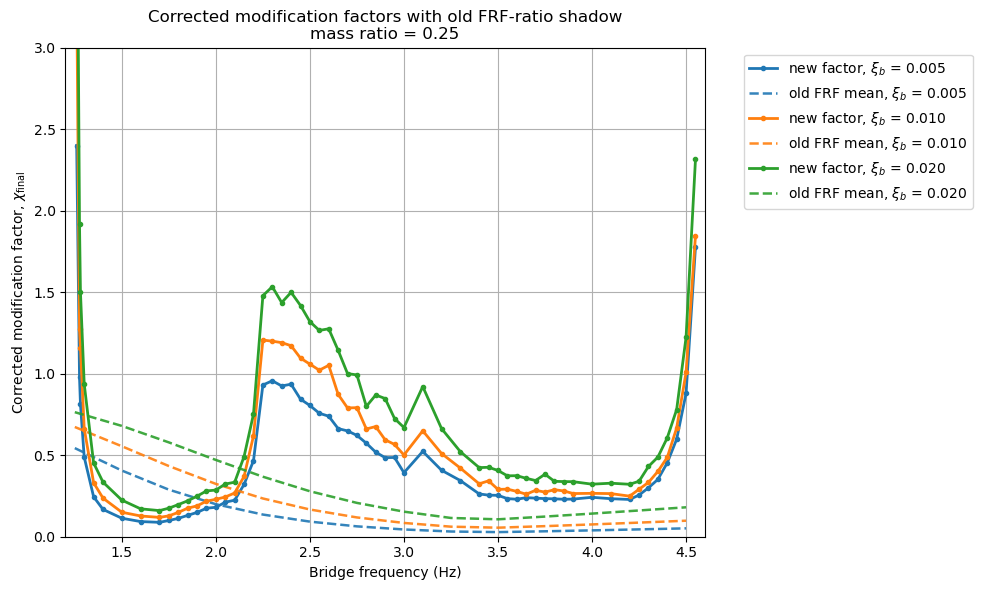

In [7]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

PLOT_COLUMN = "final_modification_factor"
MEASURE_TO_PLOT = None

OLD_FRF_PKL = folder / "forcefactors_bridgeF_bridgedamp.pkl"

DAMPINGS_TO_COMPARE = [0.005, 0.010, 0.020]

# Old FRF suggestion only for densities < 1
MAX_DENSITY_FOR_OLD_FRF = 1.0

SAVE_PLOTS = True

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

ylabel_map = {
    "final_modification_factor": r"Corrected modification factor, $\chi_{\mathrm{final}}$",
    "initial_modification_factor": r"Initial modification factor, $\chi_0$",
    "residual_correction_factor": r"Residual correction factor, $\lambda$",
    "code_bias_mean": "Mean code bias",
    "simplified_bias_mean": "Mean simplified bias",
    "corrected_bias_mean": "Mean corrected bias",
}

ylabel = ylabel_map.get(PLOT_COLUMN, PLOT_COLUMN.replace("_", " "))

# ==================================================
# LOAD NEW CORRECTED MODIFICATION FACTORS
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading new factor file:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching new modification-factor summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    PLOT_COLUMN,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

if MEASURE_TO_PLOT is not None:
    if "measure" not in corrected_df.columns:
        raise KeyError("MEASURE_TO_PLOT is set, but dataframe has no 'measure' column.")

    corrected_df = corrected_df[
        corrected_df["measure"].astype(str) == MEASURE_TO_PLOT
    ].copy()

    if corrected_df.empty:
        raise ValueError(f"No rows found for measure: {MEASURE_TO_PLOT}")

# Keep the intended frequency ranges from 0S, 0S125, and 0S456
region_mask = (
    ((corrected_df["file_region"] == "0S") &
     (corrected_df["bridge_frequency"] >= 1.40) &
     (corrected_df["bridge_frequency"] <= 3.40))
    |
    ((corrected_df["file_region"] == "0S125") &
     (corrected_df["bridge_frequency"] < 1.40))
    |
    ((corrected_df["file_region"] == "0S456") &
     (corrected_df["bridge_frequency"] > 3.40))
)

corrected_df = corrected_df[region_mask].copy()

corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "bridge_frequency"]
)

# Remove duplicates from multiple response measures
corrected_df = corrected_df.drop_duplicates(
    subset=["damping_key", "density_key", "bridge_frequency"],
    keep="first"
).copy()

# Keep only the damping ratios we want
corrected_df = corrected_df[
    corrected_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

print("\nNew corrected-factor coverage:")
print(
    corrected_df
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# LOAD OLD FRF-RATIO PKL
# Your saved structure:
# results_all[beamdamp][bf][density]["accel_ratio"]
# ==================================================

if not OLD_FRF_PKL.exists():
    raise FileNotFoundError(f"Old FRF-ratio pkl not found: {OLD_FRF_PKL}")

with open(OLD_FRF_PKL, "rb") as f:
    old_data = pickle.load(f)

results_all = old_data["results_all"]

print("\nLoaded old FRF-ratio file:", OLD_FRF_PKL.name)
print("Saved damping values:", old_data.get("damping_values", "not found"))
print("Saved densities:", old_data.get("densities", "not found"))
print("Saved NUM_SIMULATIONS:", old_data.get("NUM_SIMULATIONS", "not found"))

# ==================================================
# EXTRACT OLD FRF RATIOS DIRECTLY FROM NESTED DICT
# ==================================================

frf_rows = []

for beamdamp, freq_dict in results_all.items():

    beamdamp_float = float(beamdamp)

    for bf, density_dict in freq_dict.items():

        bf_float = float(bf)

        for density, data in density_dict.items():

            density_float = float(density)

            if not isinstance(data, dict):
                print(f"Skipping non-dict entry: damping={beamdamp}, bf={bf}, density={density}")
                continue

            if "accel_ratio" not in data:
                print(f"Skipping entry with no accel_ratio: damping={beamdamp}, bf={bf}, density={density}")
                continue

            accel_values = np.asarray(data["accel_ratio"], dtype=float).ravel()

            for sim_id, accel_ratio in enumerate(accel_values):
                if np.isfinite(accel_ratio):
                    frf_rows.append({
                        "target_beamdamp": beamdamp_float,
                        "bridge_frequency": bf_float,
                        "target_density": density_float,
                        "simulation": sim_id,
                        "accel_ratio": float(accel_ratio),
                    })

frf_df = pd.DataFrame(frf_rows)

if frf_df.empty:
    raise ValueError("No old FRF accel_ratio values were extracted.")

frf_df["density_key"] = frf_df["target_density"].round(4)
frf_df["damping_key"] = frf_df["target_beamdamp"].round(3)

# Keep only the damping ratios we want
frf_df = frf_df[
    frf_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

# Old FRF overlay only for densities < 1
frf_df = frf_df[
    frf_df["target_density"] < MAX_DENSITY_FOR_OLD_FRF
].copy()

frf_summary = (
    frf_df
    .groupby(["damping_key", "density_key", "bridge_frequency"])["accel_ratio"]
    .agg(
        frf_mean="mean",
        frf_p5=lambda x: np.percentile(x, 5),
        frf_p50="median",
        frf_p95=lambda x: np.percentile(x, 95),
        n="count",
    )
    .reset_index()
)

print("\nOld FRF-ratio summary coverage:")
print(
    frf_summary
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# PLOT: ONE FIGURE PER MASS RATIO, COMPARE 3 DAMPINGS
# ==================================================

for density in sorted(corrected_df["density_key"].dropna().unique()):

    # You said the FRF comparison is for densities less than 1
    if density >= MAX_DENSITY_FOR_OLD_FRF:
        continue

    mr = density_to_mass_ratio.get(round(float(density), 4), None)

    if mr is not None:
        title_density = f"mass ratio = {mr:.2f}"
        out_density = f"massratio{mr:.2f}"
    else:
        title_density = f"density = {density:.4f}"
        out_density = f"density{density:.4f}"

    plt.figure(figsize=(10, 6))

    for damp in DAMPINGS_TO_COMPARE:

        damp_key = round(damp, 3)

        # ---------------- New corrected factor ----------------
        sub = corrected_df[
            np.isclose(corrected_df["density_key"], density) &
            np.isclose(corrected_df["damping_key"], damp_key)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        if sub.empty:
            print(f"No corrected factor data for density={density:.4f}, damping={damp:.3f}")
            continue

        line = plt.plot(
            sub["bridge_frequency"].values,
            sub[PLOT_COLUMN].values,
            marker="o",
            markersize=3,
            linewidth=2,
            label=rf"new factor, $\xi_b$ = {damp:.3f}",
        )[0]

        line_color = line.get_color()

        # ---------------- Old FRF-ratio shadow ----------------
        frf_sub = frf_summary[
            np.isclose(frf_summary["density_key"], density) &
            np.isclose(frf_summary["damping_key"], damp_key)
        ].copy()

        # Limit old FRF to the plot frequency range
        frf_sub = frf_sub[
            (frf_sub["bridge_frequency"] >= 1.2) &
            (frf_sub["bridge_frequency"] <= 4.6)
        ].copy()

        frf_sub = frf_sub.sort_values("bridge_frequency")

        if not frf_sub.empty:
            plt.fill_between(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_p5"].values,
                frf_sub["frf_p95"].values,
                color=line_color,
                alpha=0.15,
                linewidth=0,
            )

            plt.plot(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_mean"].values,
                linestyle="--",
                linewidth=1.8,
                color=line_color,
                alpha=0.9,
                label=rf"old FRF mean, $\xi_b$ = {damp:.3f}",
            )
        else:
            print(f"No old FRF data for density={density:.4f}, damping={damp:.3f}")

    plt.xlabel("Bridge frequency (Hz)")
    plt.xlim(1.2, 4.6)

    plt.ylabel(ylabel)
    plt.ylim(0, 3.0)

    plt.title(
        "Corrected modification factors with old FRF-ratio shadow\n"
        + title_density
    )

    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = f"compare_damping_old_FRF_shadow_{out_density}.png"
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()

Loaded: NMFR_2.pkl
Densities: [0.0333 0.1667 0.3333 0.5    0.6667 0.8333 1.    ]
Damping values: [0.005 0.01  0.015 0.02  0.025 0.03 ]
Bridge frequency range: 1.25 to 4.6
Surface area S: 100.0

Extracted rows: 5670
   target_beamdamp  target_density  bridge_frequency  simulation  frf_ratio  \
0            0.005          0.0333              1.25           0   0.955679   
1            0.005          0.1667              1.25           0   0.805989   
2            0.005          0.3333              1.25           0   0.703846   
3            0.005          0.5000              1.25           0   0.634358   
4            0.005          0.6667              1.25           0   0.580402   

   f_eff_peak  f0_peak  
0       1.244     1.25  
1       1.213     1.25  
2       1.183     1.25  
3       1.155     1.25  
4       1.127     1.25  

Check max difference between direct ratio and simplified ratio:
2.6645352591003757e-15

Summary coverage:
    damping_key  density_key   min  max  count
0     

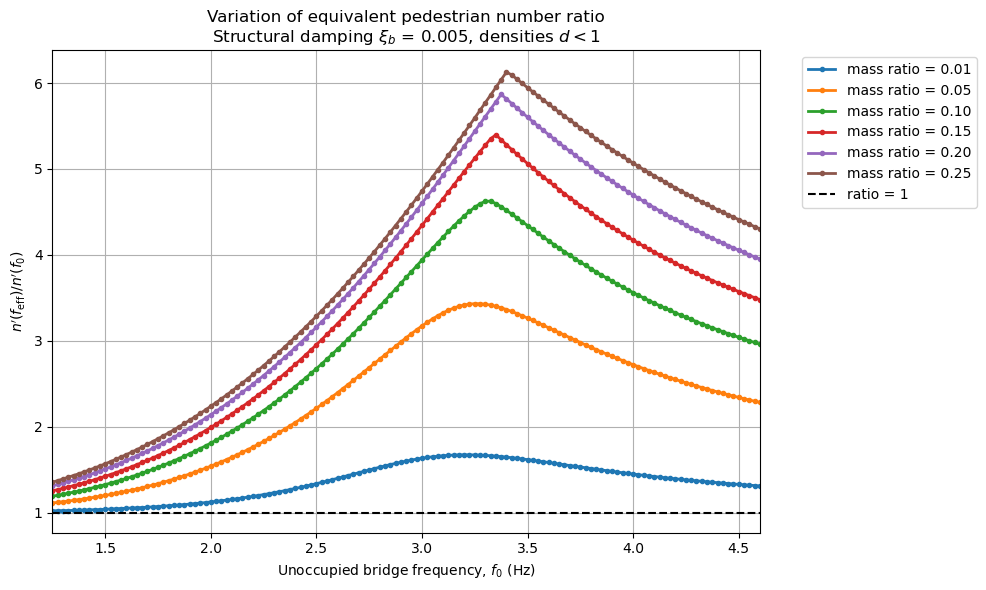

Saved: nprime_ratio_feff_over_f0_damping0.010.png


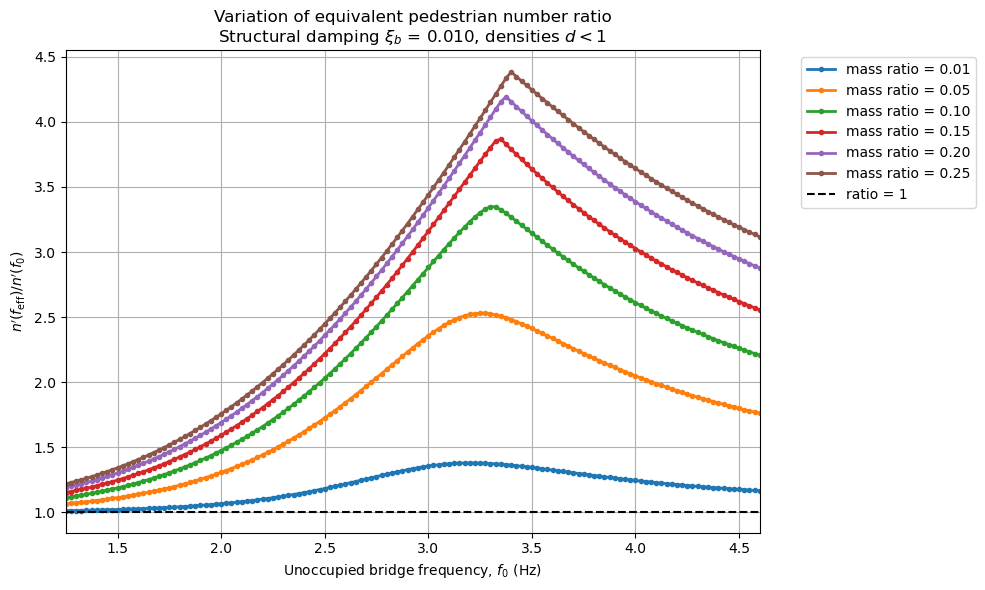

Saved: nprime_ratio_feff_over_f0_damping0.020.png


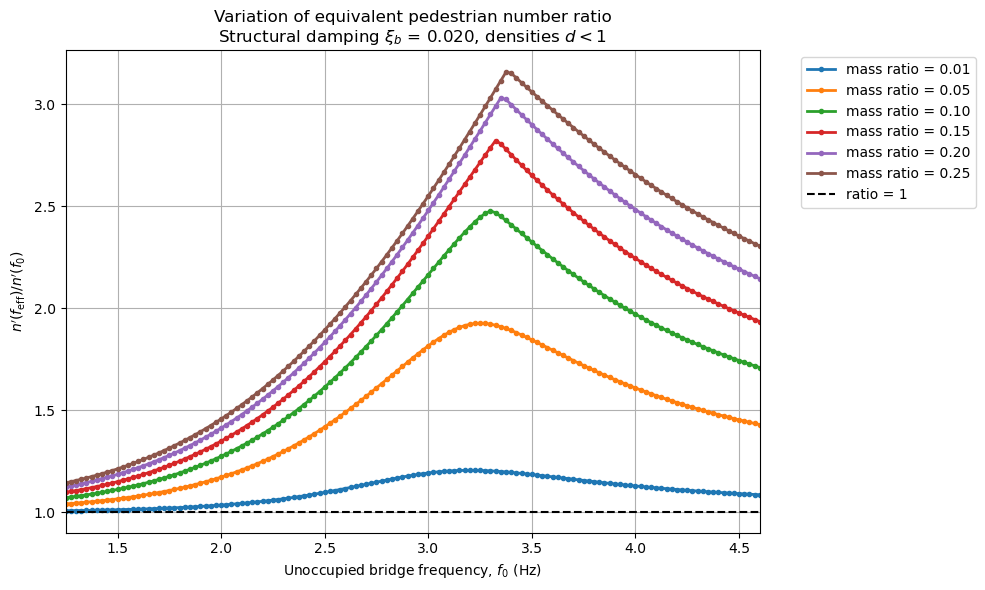

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")
NMFR_FILE = folder / "NMFR_2.pkl"

# Plot only these damping ratios
DAMPINGS_TO_PLOT = [0.005, 0.010, 0.020]

# Only densities less than 1
MAX_DENSITY = 1.0

# If your frf_ratio = |H_HSI|max / |H_MF|max, keep True.
# Then xi_eff = xi_b / frf_ratio
FRF_RATIO_IS_HSI_OVER_MF = True

# Bridge/crowd surface
# If available, these are overwritten by values in NMFR_2.pkl
length = 50.0
width = 2.0

SAVE_PLOTS = False
 
density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

# ==================================================
# LOAD PKL
# ==================================================

with open(NMFR_FILE, "rb") as f:
    data = pickle.load(f)

results_all = data["results_all"]

densities = np.asarray(data["densities"], dtype=float)
damping_values = np.asarray(data["damping_values"], dtype=float)

length = float(data.get("length", length))
width = float(data.get("width", width))
S = length * width

frequency_bands = data.get("frequency_bands", {})

if isinstance(frequency_bands, dict):
    bridge_frequencies = np.unique(
        np.concatenate([np.asarray(v, dtype=float).ravel() for v in frequency_bands.values()])
    )
else:
    bridge_frequencies = np.asarray(data.get("bridge_frequencies", []), dtype=float)

print("Loaded:", NMFR_FILE.name)
print("Densities:", densities)
print("Damping values:", damping_values)
print("Bridge frequency range:", np.nanmin(bridge_frequencies), "to", np.nanmax(bridge_frequencies))
print("Surface area S:", S)

# ==================================================
# HELPER FUNCTIONS
# ==================================================

def is_scalar_number(x):
    try:
        return np.isscalar(x) and np.isfinite(float(x))
    except Exception:
        return False


def as_1d_float_array(x):
    try:
        arr = np.asarray(x, dtype=float).ravel()
        return arr[np.isfinite(arr)]
    except Exception:
        return np.array([], dtype=float)


def get_first_existing(d, candidate_names):
    """
    Get a value from a dict using several possible key names.
    """
    for name in candidate_names:
        if name in d:
            return d[name]

    # fallback: case-insensitive and substring matching
    lower_map = {str(k).lower(): k for k in d.keys()}

    for name in candidate_names:
        name_low = name.lower()
        for k_low, k_real in lower_map.items():
            if name_low == k_low:
                return d[k_real]

    return None


def classify_numeric_key(key):
    """
    Classify numeric nested dictionary keys as damping, density, or bridge frequency.
    This works because the frequency band starts at 1.25, while densities < 1 are below 1.
    """
    try:
        value = float(key)
    except Exception:
        return None, None

    # damping values
    if np.any(np.isclose(value, damping_values, atol=5e-6)):
        return "target_beamdamp", value

    # densities
    if np.any(np.isclose(value, densities, atol=5e-5)):
        return "target_density", value

    # bridge frequencies
    if bridge_frequencies.size > 0 and np.any(np.isclose(value, bridge_frequencies, atol=5e-5)):
        return "bridge_frequency", value

    return None, None


# ==================================================
# RECURSIVELY EXTRACT RESULTS
# ==================================================

rows = []

def walk(obj, context=None):
    if context is None:
        context = {}

    if isinstance(obj, dict):

        # update context if metadata is stored inside the dict
        local_context = context.copy()

        metadata_aliases = {
            "target_beamdamp": ["target_beamdamp", "beamdamp", "damping", "bridge_damping"],
            "target_density": ["target_density", "density"],
            "bridge_frequency": ["bridge_frequency", "beamFreq", "bf", "f0", "f0_peak"],
        }

        for target_name, aliases in metadata_aliases.items():
            val = get_first_existing(obj, aliases)
            if is_scalar_number(val):
                local_context[target_name] = float(val)

        # leaf result values
        frf_ratio_val = get_first_existing(
            obj,
            ["frf_ratio", "frf_ratio_all", "FRF_ratio", "H_ratio", "accel_ratio"]
        )

        f_eff_val = get_first_existing(
            obj,
            ["f_eff_peak", "f_eff_peak_all", "f_eff", "feff"]
        )

        f0_val = get_first_existing(
            obj,
            ["f0_peak", "f0_peak_all", "f0", "bridge_frequency"]
        )

        if frf_ratio_val is not None and all(
            k in local_context for k in ["target_beamdamp", "target_density", "bridge_frequency"]
        ):
            frf_arr = as_1d_float_array(frf_ratio_val)
            f_eff_arr = as_1d_float_array(f_eff_val)
            f0_arr = as_1d_float_array(f0_val)

            n_sims = len(frf_arr)

            for i in range(n_sims):
                row = {
                    "target_beamdamp": float(local_context["target_beamdamp"]),
                    "target_density": float(local_context["target_density"]),
                    "bridge_frequency": float(local_context["bridge_frequency"]),
                    "simulation": i,
                    "frf_ratio": float(frf_arr[i]),
                }

                if len(f_eff_arr) == n_sims:
                    row["f_eff_peak"] = float(f_eff_arr[i])
                elif len(f_eff_arr) == 1:
                    row["f_eff_peak"] = float(f_eff_arr[0])
                else:
                    row["f_eff_peak"] = np.nan

                if len(f0_arr) == n_sims:
                    row["f0_peak"] = float(f0_arr[i])
                elif len(f0_arr) == 1:
                    row["f0_peak"] = float(f0_arr[0])
                else:
                    row["f0_peak"] = float(local_context["bridge_frequency"])

                rows.append(row)

            return

        # continue walking nested dict
        for key, value in obj.items():
            new_context = local_context.copy()

            label, val = classify_numeric_key(key)
            if label is not None:
                new_context[label] = val

            walk(value, new_context)

    elif isinstance(obj, (list, tuple)):
        for value in obj:
            walk(value, context.copy())

    elif isinstance(obj, np.ndarray):
        if obj.dtype == object:
            for value in obj.ravel():
                walk(value, context.copy())


walk(results_all)

df = pd.DataFrame(rows)

if df.empty:
    raise ValueError(
        "No FRF ratio data were extracted. "
        "Print results_all.keys() and one nested entry so we can adjust the extractor."
    )

print("\nExtracted rows:", len(df))
print(df.head())

# ==================================================
# COMPUTE xi_eff AND n' RATIO
# ==================================================

df["target_beamdamp"] = pd.to_numeric(df["target_beamdamp"], errors="coerce")
df["target_density"] = pd.to_numeric(df["target_density"], errors="coerce")
df["bridge_frequency"] = pd.to_numeric(df["bridge_frequency"], errors="coerce")
df["frf_ratio"] = pd.to_numeric(df["frf_ratio"], errors="coerce")

df = df.dropna(subset=["target_beamdamp", "target_density", "bridge_frequency", "frf_ratio"]).copy()

df["density_key"] = df["target_density"].round(4)
df["damping_key"] = df["target_beamdamp"].round(3)

# Keep densities < 1
df = df[df["target_density"] < MAX_DENSITY].copy()

# Keep selected damping ratios
df = df[df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_PLOT])].copy()

# Avoid division by zero or bad FRF ratios
df = df[np.isfinite(df["frf_ratio"]) & (df["frf_ratio"] > 0)].copy()

# If frf_ratio = |H_HSI| / |H_MF|:
# xi_eff = xi_b * |H_MF| / |H_HSI| = xi_b / frf_ratio
if FRF_RATIO_IS_HSI_OVER_MF:
    df["xi_eff"] = df["target_beamdamp"] / df["frf_ratio"]
else:
    df["xi_eff"] = df["target_beamdamp"] * df["frf_ratio"]

# Optional safety clipping to avoid impossible values from numerical artefacts
df["xi_eff"] = df["xi_eff"].clip(lower=1e-8, upper=0.70)

# For density d < 1:
# n' = 10.8 * sqrt(xi * n) / S
# n = density * S
df["n_peds"] = df["target_density"] * S

df["nprime_f0"] = 10.8 * np.sqrt(df["target_beamdamp"] * df["n_peds"]) / S
df["nprime_feff"] = 10.8 * np.sqrt(df["xi_eff"] * df["n_peds"]) / S

df["nprime_ratio"] = df["nprime_feff"] / df["nprime_f0"]

# This should equal sqrt(xi_eff / xi_b)
df["nprime_ratio_check"] = np.sqrt(df["xi_eff"] / df["target_beamdamp"])

print("\nCheck max difference between direct ratio and simplified ratio:")
print(np.nanmax(np.abs(df["nprime_ratio"] - df["nprime_ratio_check"])))

# ==================================================
# SUMMARY FOR PLOTTING
# ==================================================

summary = (
    df
    .groupby(["damping_key", "density_key", "bridge_frequency"])["nprime_ratio"]
    .agg(
        mean="mean",
        p5=lambda x: np.percentile(x, 5),
        p50="median",
        p95=lambda x: np.percentile(x, 95),
        n="count",
    )
    .reset_index()
)

print("\nSummary coverage:")
print(
    summary
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# PLOT: n'(f_eff) / n'(f0)
# One figure per damping ratio
# ==================================================

for damp in DAMPINGS_TO_PLOT:

    damp_key = round(damp, 3)

    sub_damp = summary[np.isclose(summary["damping_key"], damp_key)].copy()

    if sub_damp.empty:
        print(f"No data for damping = {damp:.3f}")
        continue

    plt.figure(figsize=(10, 6))

    for density in sorted(sub_damp["density_key"].unique()):

        sub = sub_damp[np.isclose(sub_damp["density_key"], density)].copy()
        sub = sub.sort_values("bridge_frequency")

        mr = density_to_mass_ratio.get(round(float(density), 4), None)

        if mr is not None:
            label = f"mass ratio = {mr:.2f}"
        else:
            label = f"density = {density:.4f}"

        line = plt.plot(
            sub["bridge_frequency"].values,
            sub["mean"].values,
            marker="o",
            markersize=3,
            linewidth=2,
            label=label,
        )[0]

        color = line.get_color()

        # If NUM_SIMULATIONS = 1, p5 = p95 = mean, so this band will be invisible
        plt.fill_between(
            sub["bridge_frequency"].values,
            sub["p5"].values,
            sub["p95"].values,
            color=color,
            alpha=0.15,
            linewidth=0,
        )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, color="black", label="ratio = 1")

    plt.xlabel("Unoccupied bridge frequency, $f_0$ (Hz)")
    plt.ylabel(r"$n'(f_{\mathrm{eff}}) / n'(f_0)$")
    plt.title(
        r"Variation of equivalent pedestrian number ratio"
        "\n"
        rf"Structural damping $\xi_b$ = {damp:.3f}, densities $d < 1$"
    )

    plt.xlim(1.25, 4.60)
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = f"nprime_ratio_feff_over_f0_damping{damp:.3f}.png"
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()

Top axis uses:
  damping = 0.005
  density = 0.3333
   bridge_frequency  f_eff_peak
0             1.250       1.183
1             1.275       1.206
2             1.300       1.229
3             1.325       1.253
4             1.350       1.276
Loaded: NMFR_2.pkl
Densities: [0.0333 0.1667 0.3333 0.5    0.6667 0.8333 1.    ]
Damping values: [0.005 0.01  0.015 0.02  0.025 0.03 ]
Bridge frequency range: 1.25 to 4.6

Extracted rows: 5670
   target_beamdamp  target_density  bridge_frequency  simulation  f_eff_peak  \
0            0.005          0.0333              1.25           0       1.244   
1            0.005          0.1667              1.25           0       1.213   
2            0.005          0.3333              1.25           0       1.183   
3            0.005          0.5000              1.25           0       1.155   
4            0.005          0.6667              1.25           0       1.127   

   f0_peak  
0     1.25  
1     1.25  
2     1.25  
3     1.25  
4     1.25  

Num

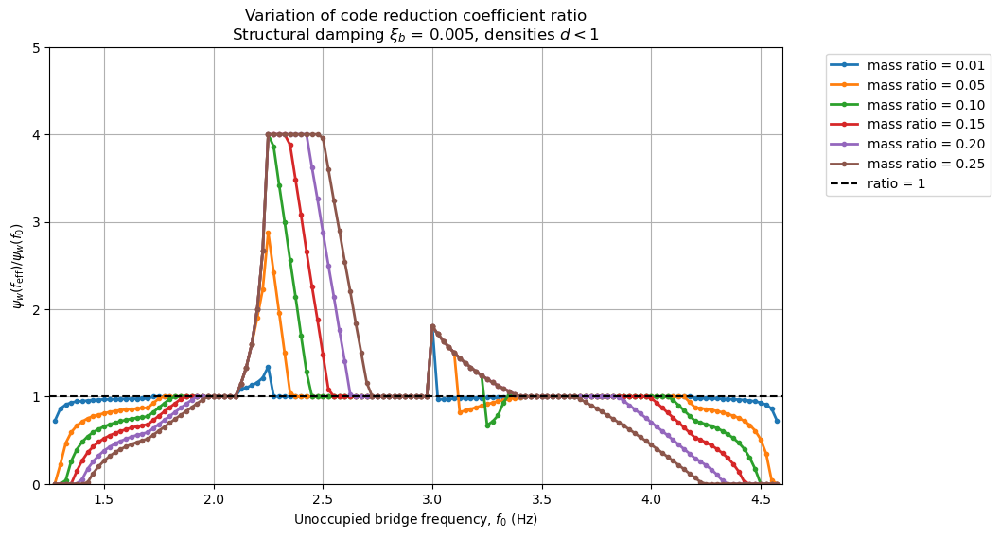

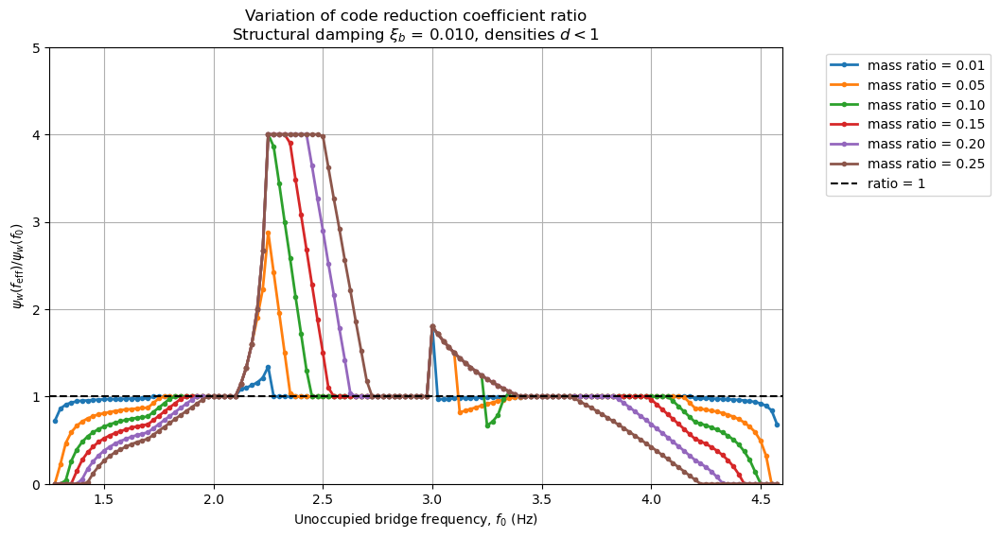

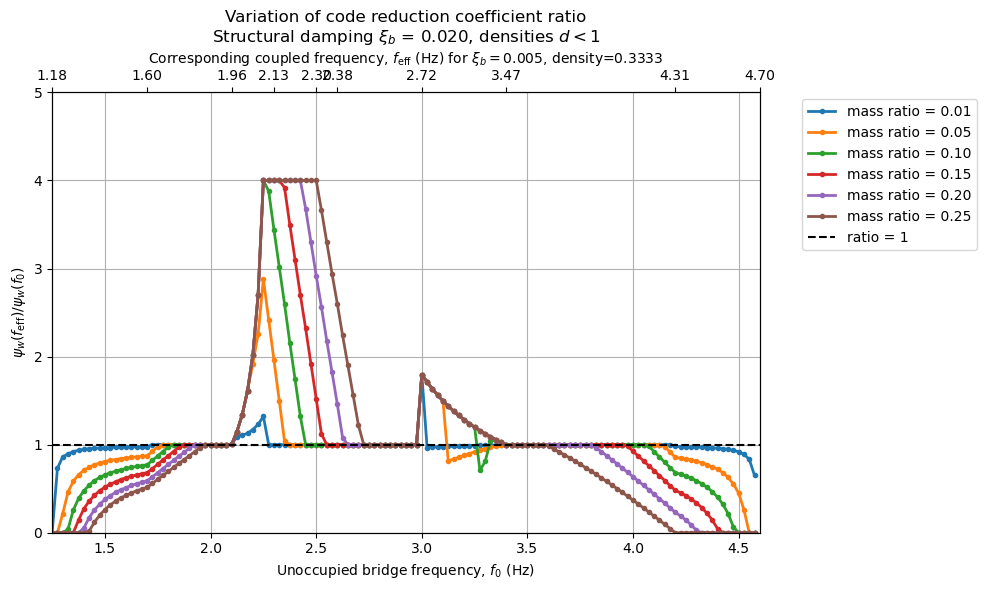

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")
NMFR_FILE = folder / "NMFR_2.pkl"

DAMPINGS_TO_PLOT = [0.005, 0.010, 0.020]

# densities less than 1 only
MAX_DENSITY = 1.0

SAVE_PLOTS = True

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

# ==================================================
# CODE REDUCTION COEFFICIENT psi_w
# ==================================================

def psi_w_h1(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Minimum rule:
    # If first vertical frequency is between 2.25 and 3.0 Hz,
    # psi_w should not be less than 0.25.
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# LOAD NMFR PKL
# ==================================================

with open(NMFR_FILE, "rb") as f:
    data = pickle.load(f)

results_all = data["results_all"]
densities = np.asarray(data["densities"], dtype=float)
damping_values = np.asarray(data["damping_values"], dtype=float)

frequency_bands = data.get("frequency_bands", {})

if isinstance(frequency_bands, dict):
    bridge_frequencies = np.unique(
        np.concatenate([np.asarray(v, dtype=float).ravel() for v in frequency_bands.values()])
    )
else:
    bridge_frequencies = np.asarray(data.get("bridge_frequencies", []), dtype=float)

print("Loaded:", NMFR_FILE.name)
print("Densities:", densities)
print("Damping values:", damping_values)
print("Bridge frequency range:", np.nanmin(bridge_frequencies), "to", np.nanmax(bridge_frequencies))

# ==================================================
# HELPER FUNCTIONS
# ==================================================

def is_scalar_number(x):
    try:
        return np.isscalar(x) and np.isfinite(float(x))
    except Exception:
        return False


def as_1d_float_array(x):
    try:
        arr = np.asarray(x, dtype=float).ravel()
        return arr[np.isfinite(arr)]
    except Exception:
        return np.array([], dtype=float)


def get_first_existing(d, names):
    for name in names:
        if name in d:
            return d[name]

    # fallback: case-insensitive exact match
    lower_map = {str(k).lower(): k for k in d.keys()}
    for name in names:
        key = name.lower()
        if key in lower_map:
            return d[lower_map[key]]

    return None


def classify_numeric_key(key):
    try:
        value = float(key)
    except Exception:
        return None, None

    if np.any(np.isclose(value, damping_values, atol=5e-6)):
        return "target_beamdamp", value

    if np.any(np.isclose(value, densities, atol=5e-5)):
        return "target_density", value

    if bridge_frequencies.size > 0 and np.any(np.isclose(value, bridge_frequencies, atol=5e-5)):
        return "bridge_frequency", value

    return None, None


# ==================================================
# EXTRACT f_eff_peak AND f0_peak FROM RESULTS_ALL
# ==================================================

rows = []

def walk(obj, context=None):
    if context is None:
        context = {}

    if isinstance(obj, dict):

        local_context = context.copy()

        # metadata if stored inside leaf dict
        metadata_aliases = {
            "target_beamdamp": ["target_beamdamp", "beamdamp", "damping", "bridge_damping"],
            "target_density": ["target_density", "density"],
            "bridge_frequency": ["bridge_frequency", "beamFreq", "bf", "f0"],
        }

        for target_name, aliases in metadata_aliases.items():
            val = get_first_existing(obj, aliases)
            if is_scalar_number(val):
                local_context[target_name] = float(val)

        f_eff_val = get_first_existing(
            obj,
            ["f_eff_peak", "f_eff_peak_all", "f_eff", "feff"]
        )

        f0_val = get_first_existing(
            obj,
            ["f0_peak", "f0_peak_all", "f0", "bridge_frequency"]
        )

        # Leaf found
        if f_eff_val is not None and all(
            k in local_context for k in ["target_beamdamp", "target_density", "bridge_frequency"]
        ):
            f_eff_arr = as_1d_float_array(f_eff_val)
            f0_arr = as_1d_float_array(f0_val)

            n_sims = len(f_eff_arr)

            for i in range(n_sims):

                if len(f0_arr) == n_sims:
                    f0_i = float(f0_arr[i])
                elif len(f0_arr) == 1:
                    f0_i = float(f0_arr[0])
                else:
                    f0_i = float(local_context["bridge_frequency"])

                rows.append({
                    "target_beamdamp": float(local_context["target_beamdamp"]),
                    "target_density": float(local_context["target_density"]),
                    "bridge_frequency": float(local_context["bridge_frequency"]),
                    "simulation": i,
                    "f_eff_peak": float(f_eff_arr[i]),
                    "f0_peak": f0_i,
                })

            return

        # Otherwise continue walking
        for key, value in obj.items():
            new_context = local_context.copy()

            label, val = classify_numeric_key(key)
            if label is not None:
                new_context[label] = val

            walk(value, new_context)

    elif isinstance(obj, (list, tuple)):
        for value in obj:
            walk(value, context.copy())

    elif isinstance(obj, np.ndarray):
        if obj.dtype == object:
            for value in obj.ravel():
                walk(value, context.copy())


walk(results_all)

df = pd.DataFrame(rows)

if df.empty:
    raise ValueError(
        "No f_eff_peak data were extracted. "
        "Print results_all.keys() and one nested leaf entry so we can adjust the extractor."
    )

print("\nExtracted rows:", len(df))
print(df.head())

# ==================================================
# COMPUTE psi(f_eff) / psi(f0)
# ==================================================

for col in ["target_beamdamp", "target_density", "bridge_frequency", "f_eff_peak", "f0_peak"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["target_beamdamp", "target_density", "bridge_frequency", "f_eff_peak", "f0_peak"]).copy()

df["density_key"] = df["target_density"].round(4)
df["damping_key"] = df["target_beamdamp"].round(3)

# Densities less than 1
df = df[df["target_density"] < MAX_DENSITY].copy()

# Selected damping ratios
df = df[df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_PLOT])].copy()

df["psi_feff"] = psi_w_h1(df["f_eff_peak"].values)
df["psi_f0"] = psi_w_h1(df["f0_peak"].values)

# Avoid division by zero
df["psi_ratio_valid"] = df["psi_f0"] > 1e-12
df["psi_ratio"] = np.nan

df.loc[df["psi_ratio_valid"], "psi_ratio"] = (
    df.loc[df["psi_ratio_valid"], "psi_feff"]
    / df.loc[df["psi_ratio_valid"], "psi_f0"]
)

# For checking invalid regions
invalid_df = df[~df["psi_ratio_valid"]].copy()

print("\nNumber of invalid psi-ratio points because psi(f0)=0:", len(invalid_df))
if len(invalid_df) > 0:
    print(invalid_df[["damping_key", "density_key", "bridge_frequency", "f0_peak", "f_eff_peak", "psi_f0", "psi_feff"]].head(20))

# Drop invalid ratios for plotting
plot_df = df[df["psi_ratio_valid"] & np.isfinite(df["psi_ratio"])].copy()

# ==================================================
# SUMMARY
# ==================================================

summary = (
    plot_df
    .groupby(["damping_key", "density_key", "bridge_frequency"])["psi_ratio"]
    .agg(
        mean="mean",
        p5=lambda x: np.percentile(x, 5),
        p50="median",
        p95=lambda x: np.percentile(x, 95),
        n="count",
    )
    .reset_index()
)

print("\nSummary coverage:")
print(
    summary
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# PLOT: psi(f_eff) / psi(f0)
# One figure per damping ratio
# ==================================================

for damp in DAMPINGS_TO_PLOT:

    damp_key = round(damp, 3)

    sub_damp = summary[np.isclose(summary["damping_key"], damp_key)].copy()

    if sub_damp.empty:
        print(f"No data for damping = {damp:.3f}")
        continue

    plt.figure(figsize=(10, 6))

    for density in sorted(sub_damp["density_key"].unique()):

        sub = sub_damp[np.isclose(sub_damp["density_key"], density)].copy()
        sub = sub.sort_values("bridge_frequency")

        mr = density_to_mass_ratio.get(round(float(density), 4), None)

        if mr is not None:
            label = f"mass ratio = {mr:.2f}"
        else:
            label = f"density = {density:.4f}"

        line = plt.plot(
            sub["bridge_frequency"].values,
            sub["mean"].values,
            marker="o",
            markersize=3,
            linewidth=2,
            label=label,
        )[0]

        color = line.get_color()

        # If NUM_SIMULATIONS = 1, p5 = p95 = mean, so this band will be invisible
        plt.fill_between(
            sub["bridge_frequency"].values,
            sub["p5"].values,
            sub["p95"].values,
            color=color,
            alpha=0.15,
            linewidth=0,
        )

    plt.axhline(1.0, linestyle="--", linewidth=1.5, color="black", label="ratio = 1")

    plt.xlabel("Unoccupied bridge frequency, $f_0$ (Hz)")
    plt.ylabel(r"$\psi_w(f_{\mathrm{eff}}) / \psi_w(f_0)$")
    plt.title(
        r"Variation of code reduction coefficient ratio"
        "\n"
        rf"Structural damping $\xi_b$ = {damp:.3f}, densities $d < 1$"
    )

    plt.xlim(1.25, 4.60)
    plt.ylim(0, 5.0)
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = f"psi_ratio_feff_over_f0_damping{damp:.3f}.png"
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()

Loading new factor file: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.015_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.025_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.030_0S_bias_summary.pkl
Loading new factor file: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.1667_damp

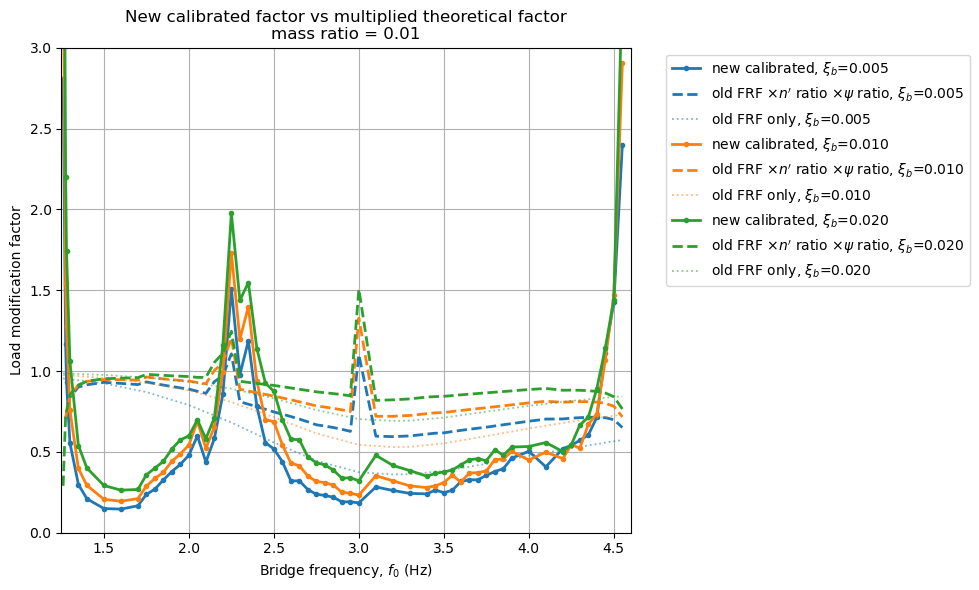

Saved: new_vs_oldFRF_times_nprime_times_psi_massratio0.05.png


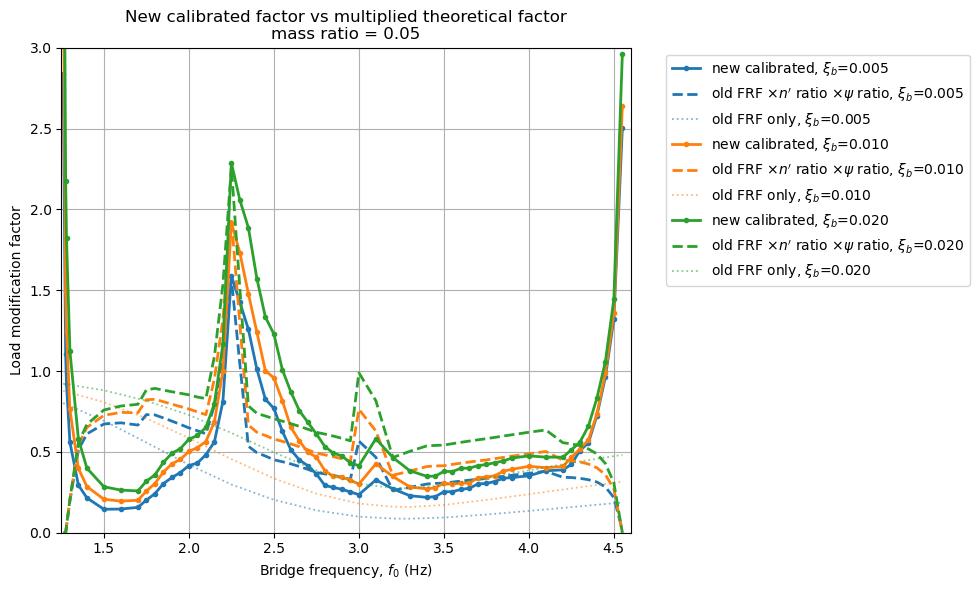

Saved: new_vs_oldFRF_times_nprime_times_psi_massratio0.10.png


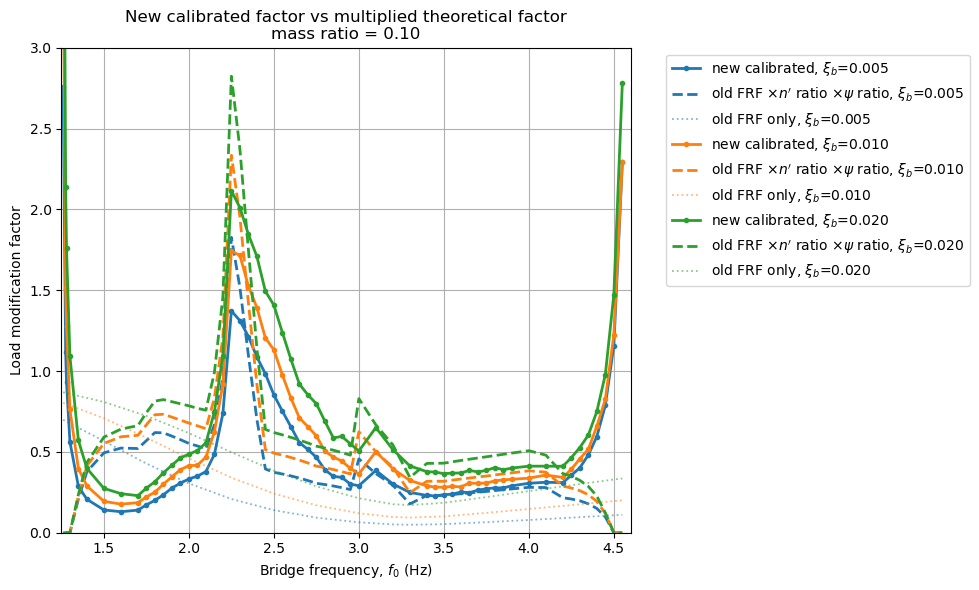

Saved: new_vs_oldFRF_times_nprime_times_psi_massratio0.15.png


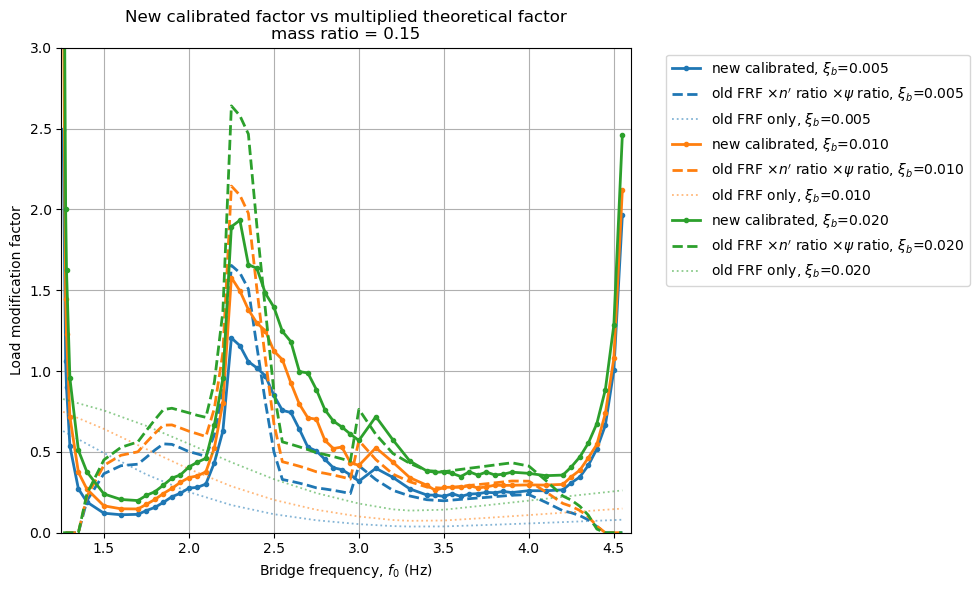

Saved: new_vs_oldFRF_times_nprime_times_psi_massratio0.20.png


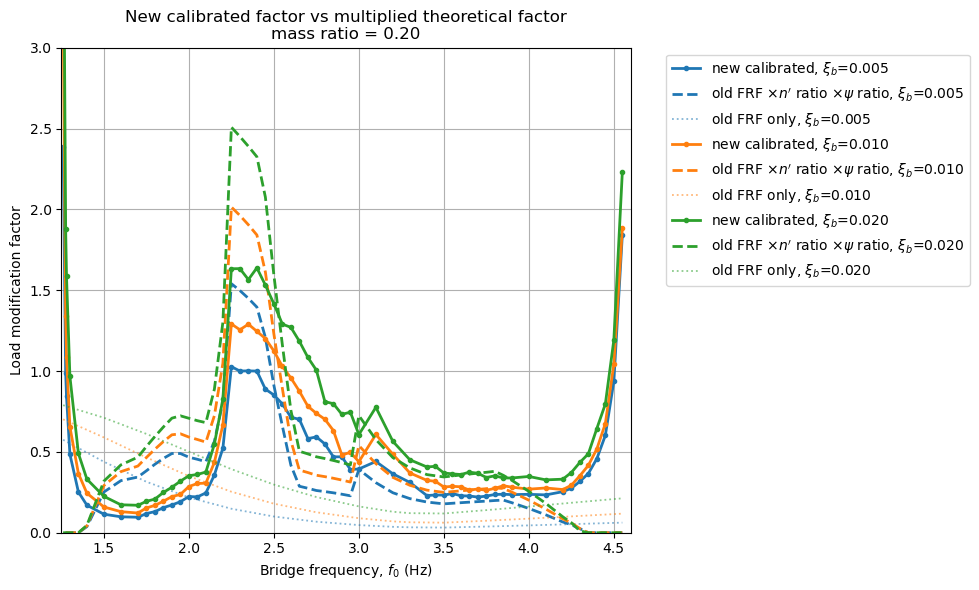

Saved: new_vs_oldFRF_times_nprime_times_psi_massratio0.25.png


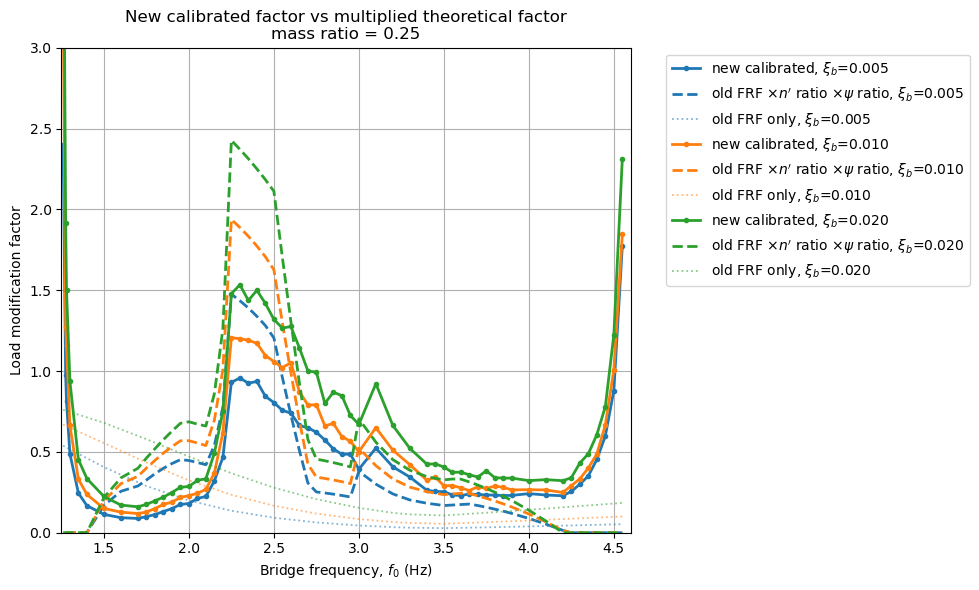

In [8]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

PLOT_COLUMN = "final_modification_factor"
MEASURE_TO_PLOT = None

OLD_FRF_PKL = folder / "forcefactors_bridgeF_bridgedamp.pkl"
NMFR_FILE = folder / "NMFR_2.pkl"

DAMPINGS_TO_COMPARE = [0.005, 0.010, 0.020]

# Only densities less than 1
MAX_DENSITY = 1.0

SAVE_PLOTS = True

# If frf_ratio in NMFR_2.pkl is |H_HSI|max / |H_MF|max, keep True
FRF_RATIO_IS_HSI_OVER_MF = True

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

ylabel = r"Load modification factor"

# ==================================================
# psi_w FUNCTION
# ==================================================

def psi_w_h1(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Minimum rule between 2.25 and 3.0 Hz
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# LOAD NEW CORRECTED MODIFICATION FACTORS
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading new factor file:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()
    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching new modification-factor summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    PLOT_COLUMN,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

if MEASURE_TO_PLOT is not None:
    if "measure" not in corrected_df.columns:
        raise KeyError("MEASURE_TO_PLOT is set, but dataframe has no 'measure' column.")

    corrected_df = corrected_df[
        corrected_df["measure"].astype(str) == MEASURE_TO_PLOT
    ].copy()

# Keep intended frequency regions
region_mask = (
    ((corrected_df["file_region"] == "0S") &
     (corrected_df["bridge_frequency"] >= 1.40) &
     (corrected_df["bridge_frequency"] <= 3.40))
    |
    ((corrected_df["file_region"] == "0S125") &
     (corrected_df["bridge_frequency"] < 1.40))
    |
    ((corrected_df["file_region"] == "0S456") &
     (corrected_df["bridge_frequency"] > 3.40))
)

corrected_df = corrected_df[region_mask].copy()

corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "bridge_frequency"]
)

corrected_df = corrected_df.drop_duplicates(
    subset=["damping_key", "density_key", "bridge_frequency"],
    keep="first"
).copy()

corrected_df = corrected_df[
    corrected_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

corrected_df = corrected_df[
    corrected_df["target_density"] < MAX_DENSITY
].copy()

print("\nNew corrected-factor coverage:")
print(
    corrected_df
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)


# ==================================================
# LOAD OLD FRF FACTORS
# Structure:
# results_all[beamdamp][bf][density]["accel_ratio"]
# ==================================================

if not OLD_FRF_PKL.exists():
    raise FileNotFoundError(f"Old FRF-ratio pkl not found: {OLD_FRF_PKL}")

with open(OLD_FRF_PKL, "rb") as f:
    old_data = pickle.load(f)

results_all_old = old_data["results_all"]

old_rows = []

for beamdamp, freq_dict in results_all_old.items():

    beamdamp_float = float(beamdamp)

    for bf, density_dict in freq_dict.items():

        bf_float = float(bf)

        for density, data in density_dict.items():

            density_float = float(density)

            if not isinstance(data, dict):
                continue

            if "accel_ratio" not in data:
                continue

            accel_values = np.asarray(data["accel_ratio"], dtype=float).ravel()

            for sim_id, accel_ratio in enumerate(accel_values):
                if np.isfinite(accel_ratio):
                    old_rows.append({
                        "target_beamdamp": beamdamp_float,
                        "bridge_frequency": bf_float,
                        "target_density": density_float,
                        "simulation": sim_id,
                        "old_frf_factor": float(accel_ratio),
                    })

old_df = pd.DataFrame(old_rows)

if old_df.empty:
    raise ValueError("No old FRF factors were extracted.")

old_df["density_key"] = old_df["target_density"].round(4)
old_df["damping_key"] = old_df["target_beamdamp"].round(3)

old_df = old_df[
    old_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

old_df = old_df[
    old_df["target_density"] < MAX_DENSITY
].copy()

old_summary = (
    old_df
    .groupby(["damping_key", "density_key", "bridge_frequency"])["old_frf_factor"]
    .agg(
        old_mean="mean",
        old_p5=lambda x: np.percentile(x, 5),
        old_p95=lambda x: np.percentile(x, 95),
        n_old="count",
    )
    .reset_index()
)

print("\nOld FRF factor coverage:")
print(
    old_summary
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)


# ==================================================
# LOAD NMFR_2 AND COMPUTE n' RATIO + psi RATIO
# ==================================================

if not NMFR_FILE.exists():
    raise FileNotFoundError(f"NMFR file not found: {NMFR_FILE}")

with open(NMFR_FILE, "rb") as f:
    nmfr_data = pickle.load(f)

results_all_nmfr = nmfr_data["results_all"]
densities = np.asarray(nmfr_data["densities"], dtype=float)
damping_values = np.asarray(nmfr_data["damping_values"], dtype=float)

length = float(nmfr_data.get("length", 50.0))
width = float(nmfr_data.get("width", 2.0))
S = length * width

frequency_bands = nmfr_data.get("frequency_bands", {})

if isinstance(frequency_bands, dict):
    bridge_frequencies = np.unique(
        np.concatenate([np.asarray(v, dtype=float).ravel() for v in frequency_bands.values()])
    )
else:
    bridge_frequencies = np.asarray(nmfr_data.get("bridge_frequencies", []), dtype=float)

print("\nLoaded:", NMFR_FILE.name)
print("Surface area S:", S)


def is_scalar_number(x):
    try:
        return np.isscalar(x) and np.isfinite(float(x))
    except Exception:
        return False


def as_1d_float_array(x):
    try:
        arr = np.asarray(x, dtype=float).ravel()
        return arr[np.isfinite(arr)]
    except Exception:
        return np.array([], dtype=float)


def get_first_existing(d, names):
    for name in names:
        if name in d:
            return d[name]

    lower_map = {str(k).lower(): k for k in d.keys()}

    for name in names:
        key = name.lower()
        if key in lower_map:
            return d[lower_map[key]]

    return None


def classify_numeric_key(key):
    try:
        value = float(key)
    except Exception:
        return None, None

    if np.any(np.isclose(value, damping_values, atol=5e-6)):
        return "target_beamdamp", value

    if np.any(np.isclose(value, densities, atol=5e-5)):
        return "target_density", value

    if bridge_frequencies.size > 0 and np.any(np.isclose(value, bridge_frequencies, atol=5e-5)):
        return "bridge_frequency", value

    return None, None


nmfr_rows = []

def walk_nmfr(obj, context=None):
    if context is None:
        context = {}

    if isinstance(obj, dict):

        local_context = context.copy()

        metadata_aliases = {
            "target_beamdamp": ["target_beamdamp", "beamdamp", "damping", "bridge_damping"],
            "target_density": ["target_density", "density"],
            "bridge_frequency": ["bridge_frequency", "beamFreq", "bf", "f0", "f0_peak"],
        }

        for target_name, aliases in metadata_aliases.items():
            val = get_first_existing(obj, aliases)
            if is_scalar_number(val):
                local_context[target_name] = float(val)

        frf_ratio_val = get_first_existing(
            obj,
            ["frf_ratio", "frf_ratio_all", "FRF_ratio", "H_ratio", "accel_ratio"]
        )

        f_eff_val = get_first_existing(
            obj,
            ["f_eff_peak", "f_eff_peak_all", "f_eff", "feff"]
        )

        f0_val = get_first_existing(
            obj,
            ["f0_peak", "f0_peak_all", "f0", "bridge_frequency"]
        )

        if frf_ratio_val is not None and all(
            k in local_context for k in ["target_beamdamp", "target_density", "bridge_frequency"]
        ):
            frf_arr = as_1d_float_array(frf_ratio_val)
            f_eff_arr = as_1d_float_array(f_eff_val)
            f0_arr = as_1d_float_array(f0_val)

            n_sims = len(frf_arr)

            for i in range(n_sims):

                if len(f_eff_arr) == n_sims:
                    f_eff_i = float(f_eff_arr[i])
                elif len(f_eff_arr) == 1:
                    f_eff_i = float(f_eff_arr[0])
                else:
                    f_eff_i = np.nan

                if len(f0_arr) == n_sims:
                    f0_i = float(f0_arr[i])
                elif len(f0_arr) == 1:
                    f0_i = float(f0_arr[0])
                else:
                    f0_i = float(local_context["bridge_frequency"])

                nmfr_rows.append({
                    "target_beamdamp": float(local_context["target_beamdamp"]),
                    "target_density": float(local_context["target_density"]),
                    "bridge_frequency": float(local_context["bridge_frequency"]),
                    "simulation": i,
                    "frf_ratio": float(frf_arr[i]),
                    "f_eff_peak": f_eff_i,
                    "f0_peak": f0_i,
                })

            return

        for key, value in obj.items():
            new_context = local_context.copy()

            label, val = classify_numeric_key(key)
            if label is not None:
                new_context[label] = val

            walk_nmfr(value, new_context)

    elif isinstance(obj, (list, tuple)):
        for value in obj:
            walk_nmfr(value, context.copy())

    elif isinstance(obj, np.ndarray):
        if obj.dtype == object:
            for value in obj.ravel():
                walk_nmfr(value, context.copy())


walk_nmfr(results_all_nmfr)

nmfr_df = pd.DataFrame(nmfr_rows)

if nmfr_df.empty:
    raise ValueError("No NMFR rows were extracted.")

for col in ["target_beamdamp", "target_density", "bridge_frequency", "frf_ratio", "f_eff_peak", "f0_peak"]:
    nmfr_df[col] = pd.to_numeric(nmfr_df[col], errors="coerce")

nmfr_df = nmfr_df.dropna(
    subset=["target_beamdamp", "target_density", "bridge_frequency", "frf_ratio", "f_eff_peak", "f0_peak"]
).copy()

nmfr_df["density_key"] = nmfr_df["target_density"].round(4)
nmfr_df["damping_key"] = nmfr_df["target_beamdamp"].round(3)

nmfr_df = nmfr_df[
    nmfr_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

nmfr_df = nmfr_df[
    nmfr_df["target_density"] < MAX_DENSITY
].copy()

nmfr_df = nmfr_df[
    np.isfinite(nmfr_df["frf_ratio"]) & (nmfr_df["frf_ratio"] > 0)
].copy()

# -----------------------------
# n' ratio
# -----------------------------

if FRF_RATIO_IS_HSI_OVER_MF:
    nmfr_df["xi_eff"] = nmfr_df["target_beamdamp"] / nmfr_df["frf_ratio"]
else:
    nmfr_df["xi_eff"] = nmfr_df["target_beamdamp"] * nmfr_df["frf_ratio"]

nmfr_df["xi_eff"] = nmfr_df["xi_eff"].clip(lower=1e-8, upper=0.70)

nmfr_df["n_peds"] = nmfr_df["target_density"] * S

nmfr_df["nprime_f0"] = 10.8 * np.sqrt(nmfr_df["target_beamdamp"] * nmfr_df["n_peds"]) / S
nmfr_df["nprime_feff"] = 10.8 * np.sqrt(nmfr_df["xi_eff"] * nmfr_df["n_peds"]) / S

nmfr_df["nprime_ratio"] = nmfr_df["nprime_feff"] / nmfr_df["nprime_f0"]

# -----------------------------
# psi ratio
# -----------------------------

nmfr_df["psi_feff"] = psi_w_h1(nmfr_df["f_eff_peak"].values)
nmfr_df["psi_f0"] = psi_w_h1(nmfr_df["f0_peak"].values)

nmfr_df["psi_ratio"] = np.nan
valid_psi = nmfr_df["psi_f0"] > 1e-12

nmfr_df.loc[valid_psi, "psi_ratio"] = (
    nmfr_df.loc[valid_psi, "psi_feff"]
    / nmfr_df.loc[valid_psi, "psi_f0"]
)

nmfr_df = nmfr_df[
    np.isfinite(nmfr_df["nprime_ratio"])
    & np.isfinite(nmfr_df["psi_ratio"])
].copy()

ratio_summary = (
    nmfr_df
    .groupby(["damping_key", "density_key", "bridge_frequency"])
    .agg(
        nprime_ratio_mean=("nprime_ratio", "mean"),
        nprime_ratio_p5=("nprime_ratio", lambda x: np.percentile(x, 5)),
        nprime_ratio_p95=("nprime_ratio", lambda x: np.percentile(x, 95)),
        psi_ratio_mean=("psi_ratio", "mean"),
        psi_ratio_p5=("psi_ratio", lambda x: np.percentile(x, 5)),
        psi_ratio_p95=("psi_ratio", lambda x: np.percentile(x, 95)),
        n_nmfr=("psi_ratio", "count"),
    )
    .reset_index()
)

print("\nNMFR ratio coverage:")
print(
    ratio_summary
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)


# ==================================================
# INTERPOLATION HELPER
# ==================================================

def interpolate_to_x(source_x, source_y, target_x):
    source_x = np.asarray(source_x, dtype=float)
    source_y = np.asarray(source_y, dtype=float)
    target_x = np.asarray(target_x, dtype=float)

    mask = np.isfinite(source_x) & np.isfinite(source_y)

    source_x = source_x[mask]
    source_y = source_y[mask]

    if len(source_x) < 2:
        return np.full_like(target_x, np.nan, dtype=float)

    order = np.argsort(source_x)
    source_x = source_x[order]
    source_y = source_y[order]

    # Remove duplicate source x values
    unique_x, unique_idx = np.unique(source_x, return_index=True)
    unique_y = source_y[unique_idx]

    if len(unique_x) < 2:
        return np.full_like(target_x, np.nan, dtype=float)

    return np.interp(target_x, unique_x, unique_y, left=np.nan, right=np.nan)


# ==================================================
# BUILD COMBINED FACTOR ON THE NEW FACTOR FREQUENCY GRID
# ==================================================

combined_rows = []

for (damp_key, density_key), new_sub in corrected_df.groupby(["damping_key", "density_key"]):

    new_sub = new_sub.sort_values("bridge_frequency").copy()

    x_new = new_sub["bridge_frequency"].values

    old_sub = old_summary[
        np.isclose(old_summary["damping_key"], damp_key)
        & np.isclose(old_summary["density_key"], density_key)
    ].copy()

    ratio_sub = ratio_summary[
        np.isclose(ratio_summary["damping_key"], damp_key)
        & np.isclose(ratio_summary["density_key"], density_key)
    ].copy()

    if old_sub.empty or ratio_sub.empty:
        print(f"Missing old or ratio data for damping={damp_key:.3f}, density={density_key:.4f}")
        continue

    old_interp = interpolate_to_x(
        old_sub["bridge_frequency"].values,
        old_sub["old_mean"].values,
        x_new
    )

    nprime_interp = interpolate_to_x(
        ratio_sub["bridge_frequency"].values,
        ratio_sub["nprime_ratio_mean"].values,
        x_new
    )

    psi_interp = interpolate_to_x(
        ratio_sub["bridge_frequency"].values,
        ratio_sub["psi_ratio_mean"].values,
        x_new
    )

    theoretical_combined = old_interp * nprime_interp * psi_interp

    temp = pd.DataFrame({
        "damping_key": damp_key,
        "density_key": density_key,
        "bridge_frequency": x_new,
        "new_factor": new_sub[PLOT_COLUMN].values,
        "old_frf_factor": old_interp,
        "nprime_ratio": nprime_interp,
        "psi_ratio": psi_interp,
        "combined_theoretical_factor": theoretical_combined,
    })

    combined_rows.append(temp)

combined_df = pd.concat(combined_rows, ignore_index=True)

print("\nCombined factor preview:")
print(combined_df.head())

print("\nCombined factor coverage:")
print(
    combined_df
    .dropna(subset=["combined_theoretical_factor"])
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)


# ==================================================
# PLOT: NEW FACTOR VS OLD * n' RATIO * psi RATIO
# One figure per mass ratio, compare 3 damping ratios
# ==================================================

for density in sorted(combined_df["density_key"].dropna().unique()):

    if density >= MAX_DENSITY:
        continue

    mr = density_to_mass_ratio.get(round(float(density), 4), None)

    if mr is not None:
        title_density = f"mass ratio = {mr:.2f}"
        out_density = f"massratio{mr:.2f}"
    else:
        title_density = f"density = {density:.4f}"
        out_density = f"density{density:.4f}"

    plt.figure(figsize=(10, 6))

    for damp in DAMPINGS_TO_COMPARE:

        damp_key = round(damp, 3)

        sub = combined_df[
            np.isclose(combined_df["density_key"], density)
            & np.isclose(combined_df["damping_key"], damp_key)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        if sub.empty:
            print(f"No combined data for density={density:.4f}, damping={damp:.3f}")
            continue

        # New calibrated factor
        line = plt.plot(
            sub["bridge_frequency"].values,
            sub["new_factor"].values,
            marker="o",
            markersize=3,
            linewidth=2,
            label=rf"new calibrated, $\xi_b$={damp:.3f}",
        )[0]

        color = line.get_color()

        # Combined theoretical factor
        plt.plot(
            sub["bridge_frequency"].values,
            sub["combined_theoretical_factor"].values,
            linestyle="--",
            linewidth=2,
            color=color,
            label=rf"old FRF $\times n'$ ratio $\times \psi$ ratio, $\xi_b$={damp:.3f}",
        )

        # Optional: show old FRF only as faint dotted line
        plt.plot(
            sub["bridge_frequency"].values,
            sub["old_frf_factor"].values,
            linestyle=":",
            linewidth=1.3,
            color=color,
            alpha=0.55,
            label=rf"old FRF only, $\xi_b$={damp:.3f}",
        )

    plt.xlabel("Bridge frequency, $f_0$ (Hz)")
    plt.ylabel(ylabel)
    plt.xlim(1.25, 4.60)
    plt.ylim(0, 3.0)

    plt.title(
        "New calibrated factor vs multiplied theoretical factor\n"
        + title_density
    )

    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = f"new_vs_oldFRF_times_nprime_times_psi_{out_density}.png"
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()

Top axis uses:
  damping = 0.005
  density = 0.3333
   bridge_frequency  f_eff_peak
0             1.250       1.183
1             1.275       1.206
2             1.300       1.229
3             1.325       1.253
4             1.350       1.276
For excitation frequency 2.00 Hz, resonance occurs at empty bridge frequency f0 ≈ 2.151 Hz


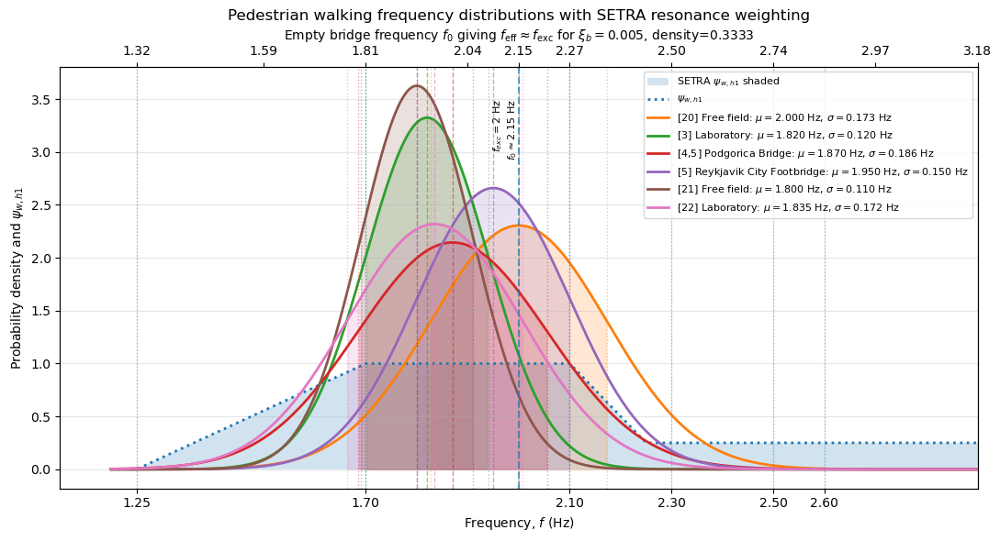

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# Normal distribution data
# --------------------------------------------------

data = [
    {"label": "[20] Free field",                 "mean": 2.000, "sd": 0.173},
    {"label": "[3] Laboratory",                  "mean": 1.820, "sd": 0.120},
    {"label": "[4,5] Podgorica Bridge",          "mean": 1.870, "sd": 0.186},
    {"label": "[5] Reykjavik City Footbridge",   "mean": 1.950, "sd": 0.150},
    {"label": "[21] Free field",                 "mean": 1.800, "sd": 0.110},
    {"label": "[22] Laboratory",                 "mean": 1.835, "sd": 0.172},
]

def normal_pdf(x, mean, sd):
    return (1 / (sd * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / sd) ** 2)


# --------------------------------------------------
# SETRA psi function
# --------------------------------------------------

def psi_w_h1(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Minimum rule between 2.25 and 3.0 Hz
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi
# --------------------------------------------------
# LOAD f_eff FROM NMFR_2.pkl FOR SECONDARY X AXIS
# --------------------------------------------------

NMFR_FILE = Path("NMFR_2.pkl")

# Choose which coupled-system case the top axis represents
DAMPING_FOR_TOP_AXIS = 0.005
DENSITY_FOR_TOP_AXIS = 0.3333   # mass ratio = 0.10 in your mapping

def as_1d_float_array(x):
    try:
        arr = np.asarray(x, dtype=float).ravel()
        return arr[np.isfinite(arr)]
    except Exception:
        return np.array([], dtype=float)

def get_first_existing(d, names):
    for name in names:
        if name in d:
            return d[name]
    lower_map = {str(k).lower(): k for k in d.keys()}
    for name in names:
        key = name.lower()
        if key in lower_map:
            return d[lower_map[key]]
    return None

with open(NMFR_FILE, "rb") as f:
    nmfr_data = pickle.load(f)

results_all = nmfr_data["results_all"]
densities = np.asarray(nmfr_data["densities"], dtype=float)
damping_values = np.asarray(nmfr_data["damping_values"], dtype=float)

frequency_bands = nmfr_data.get("frequency_bands", {})

if isinstance(frequency_bands, dict):
    bridge_frequencies = np.unique(
        np.concatenate([np.asarray(v, dtype=float).ravel() for v in frequency_bands.values()])
    )
else:
    bridge_frequencies = np.asarray(nmfr_data.get("bridge_frequencies", []), dtype=float)

def classify_numeric_key(key):
    try:
        value = float(key)
    except Exception:
        return None, None

    if np.any(np.isclose(value, damping_values, atol=5e-6)):
        return "target_beamdamp", value

    if np.any(np.isclose(value, densities, atol=5e-5)):
        return "target_density", value

    if bridge_frequencies.size > 0 and np.any(np.isclose(value, bridge_frequencies, atol=5e-5)):
        return "bridge_frequency", value

    return None, None

feff_rows = []

def walk_feff(obj, context=None):
    if context is None:
        context = {}

    if isinstance(obj, dict):
        local_context = context.copy()

        # metadata if stored inside leaf dict
        metadata_aliases = {
            "target_beamdamp": ["target_beamdamp", "beamdamp", "damping", "bridge_damping"],
            "target_density": ["target_density", "density"],
            "bridge_frequency": ["bridge_frequency", "beamFreq", "bf", "f0"],
        }

        for target_name, aliases in metadata_aliases.items():
            val = get_first_existing(obj, aliases)
            try:
                if np.isscalar(val) and np.isfinite(float(val)):
                    local_context[target_name] = float(val)
            except Exception:
                pass

        f_eff_val = get_first_existing(
            obj,
            ["f_eff_peak", "f_eff_peak_all", "f_eff", "feff"]
        )

        f0_val = get_first_existing(
            obj,
            ["f0_peak", "f0_peak_all", "f0", "bridge_frequency"]
        )

        # leaf found
        if f_eff_val is not None and all(
            k in local_context for k in ["target_beamdamp", "target_density", "bridge_frequency"]
        ):
            f_eff_arr = as_1d_float_array(f_eff_val)
            f0_arr = as_1d_float_array(f0_val)

            for i, f_eff_i in enumerate(f_eff_arr):

                if len(f0_arr) == len(f_eff_arr):
                    f0_i = float(f0_arr[i])
                elif len(f0_arr) == 1:
                    f0_i = float(f0_arr[0])
                else:
                    f0_i = float(local_context["bridge_frequency"])

                feff_rows.append({
                    "target_beamdamp": float(local_context["target_beamdamp"]),
                    "target_density": float(local_context["target_density"]),
                    "bridge_frequency": float(local_context["bridge_frequency"]),
                    "f0_peak": f0_i,
                    "f_eff_peak": float(f_eff_i),
                })

            return

        # keep walking nested dictionary
        for key, value in obj.items():
            new_context = local_context.copy()
            label, val = classify_numeric_key(key)

            if label is not None:
                new_context[label] = val

            walk_feff(value, new_context)

    elif isinstance(obj, (list, tuple)):
        for value in obj:
            walk_feff(value, context.copy())

    elif isinstance(obj, np.ndarray):
        if obj.dtype == object:
            for value in obj.ravel():
                walk_feff(value, context.copy())

walk_feff(results_all)

feff_df = pd.DataFrame(feff_rows)

if feff_df.empty:
    raise ValueError("No f_eff_peak values were extracted from NMFR_2.pkl")

feff_df["damping_key"] = feff_df["target_beamdamp"].round(3)
feff_df["density_key"] = feff_df["target_density"].round(4)

feff_case = feff_df[
    np.isclose(feff_df["damping_key"], round(DAMPING_FOR_TOP_AXIS, 3)) &
    np.isclose(feff_df["density_key"], round(DENSITY_FOR_TOP_AXIS, 4))
].copy()

if feff_case.empty:
    raise ValueError(
        f"No f_eff data found for damping={DAMPING_FOR_TOP_AXIS}, "
        f"density={DENSITY_FOR_TOP_AXIS}"
    )

feff_map = (
    feff_case
    .groupby("bridge_frequency")["f_eff_peak"]
    .mean()
    .reset_index()
    .sort_values("bridge_frequency")
)

f0_grid = feff_map["bridge_frequency"].values
feff_grid = feff_map["f_eff_peak"].values

print("Top axis uses:")
print(f"  damping = {DAMPING_FOR_TOP_AXIS}")
print(f"  density = {DENSITY_FOR_TOP_AXIS}")
print(feff_map.head())

# --------------------------------------------------
# Frequency range
# --------------------------------------------------

x = np.linspace(1.2, 4.7, 1500)
psi_vals = psi_w_h1(x)

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(11, 6))

# Shade psi on the same axis
plt.fill_between(
    x,
    0,
    psi_vals,
    alpha=0.20,
    label=r"SETRA $\psi_{w,h1}$ shaded"
)

# Optional psi boundary line
plt.plot(
    x,
    psi_vals,
    linestyle=":",
    linewidth=2,
    label=r"$\psi_{w,h1}$"
)

# Plot normal distributions
for item in data:
    mean = item["mean"]
    sd = item["sd"]

    y = normal_pdf(x, mean, sd)

    # Plot PDF line and capture its automatic color
    line, = plt.plot(
        x,
        y,
        linewidth=2,
        label=fr"{item['label']}: $\mu={mean:.3f}$ Hz, $\sigma={sd:.3f}$ Hz"
    )

    line_color = line.get_color()

    # Shade region between mean - 1 sigma and mean + 1 sigma
    m_1sigma = (x >= mean - sd) & (x <= mean + sd)

    plt.fill_between(
        x[m_1sigma],
        0,
        y[m_1sigma],
        color=line_color,
        alpha=0.18
    )

    # Mean line
    plt.axvline(
        mean,
        linestyle="--",
        linewidth=1,
        color=line_color,
        alpha=0.55
    )

    # Optional: boundaries of +/- 1 sigma
    plt.axvline(
        mean - sd,
        linestyle=":",
        linewidth=1,
        color=line_color,
        alpha=0.45
    )

    plt.axvline(
        mean + sd,
        linestyle=":",
        linewidth=1,
        color=line_color,
        alpha=0.45
    )
# --------------------------------------------------
# Vertical frequency markers
# --------------------------------------------------

x_ticks = [1.25, 1.70, 2.10, 2.30, 2.50, 2.60, 3.00, 3.40, 4.20, 4.60]

for freq in x_ticks:
    plt.axvline(freq, linestyle=":", linewidth=1, alpha=0.4)

plt.xticks(x_ticks, [f"{v:.2f}" for v in x_ticks])

# --------------------------------------------------
# Formatting
# --------------------------------------------------

plt.xlabel("Frequency, $f$ (Hz)")
plt.xlim(1.10, 2.9)
plt.ylabel(r"Probability density and $\psi_{w,h1}$")
plt.title("Pedestrian walking frequency distributions with SETRA resonance weighting")

plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, loc="upper right")
plt.tight_layout()
# --------------------------------------------------
# Secondary x-axis:
# bottom axis = excitation frequency f_exc
# top axis    = empty bridge frequency f0 that resonates after HSI
#
# Resonance condition:
#     f_eff(f0) = f_exc
# --------------------------------------------------

ax = plt.gca()

# Build inverse map: f_eff -> f0
inverse_map = (
    feff_map[["bridge_frequency", "f_eff_peak"]]
    .dropna()
    .copy()
)

# Sort by f_eff because np.interp needs increasing x values
inverse_map = inverse_map.sort_values("f_eff_peak")

# If duplicate f_eff values exist, average the corresponding f0 values
inverse_map = (
    inverse_map
    .groupby("f_eff_peak", as_index=False)["bridge_frequency"]
    .mean()
    .sort_values("f_eff_peak")
)

feff_unique = inverse_map["f_eff_peak"].values       # this is f_exc axis input
f0_required = inverse_map["bridge_frequency"].values # this is top-axis label

# Bottom ticks are excitation frequencies
exc_ticks = np.array([1.25, 1.50, 1.70, 1.90, 2.00, 2.10, 2.30, 2.50, 2.70, 2.90])

exc_ticks = exc_ticks[
    (exc_ticks >= ax.get_xlim()[0]) &
    (exc_ticks <= ax.get_xlim()[1])
]

# For each excitation frequency, find the bridge frequency whose f_eff matches it
top_bridge_freqs = np.interp(
    exc_ticks,
    feff_unique,
    f0_required,
    left=np.nan,
    right=np.nan
)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(exc_ticks)

ax_top.set_xticklabels([
    f"{v:.2f}" if np.isfinite(v) else ""
    for v in top_bridge_freqs
])

ax_top.set_xlabel(
    rf"Empty bridge frequency $f_0$ giving $f_{{\mathrm{{eff}}}}\approx f_{{\mathrm{{exc}}}}$ "
    rf"for $\xi_b={DAMPING_FOR_TOP_AXIS:.3f}$, density={DENSITY_FOR_TOP_AXIS:.4f}"
)

# Optional: print the important value for 2 Hz excitation
target_exc = 2.00
target_f0 = np.interp(
    target_exc,
    feff_unique,
    f0_required,
    left=np.nan,
    right=np.nan
)

print(f"For excitation frequency {target_exc:.2f} Hz, resonance occurs at empty bridge frequency f0 ≈ {target_f0:.3f} Hz")

# Optional visual marker for 2 Hz excitation
if np.isfinite(target_f0):
    ax.axvline(target_exc, linestyle="--", linewidth=1.5, alpha=0.7)
    ax.text(
        target_exc,
        ax.get_ylim()[1] * 0.92,
        rf"$f_{{exc}}=2$ Hz" + "\n" + rf"$f_0\approx {target_f0:.2f}$ Hz",
        rotation=90,
        va="top",
        ha="right",
        fontsize=8
    )

plt.tight_layout()
plt.show()
plt.show()

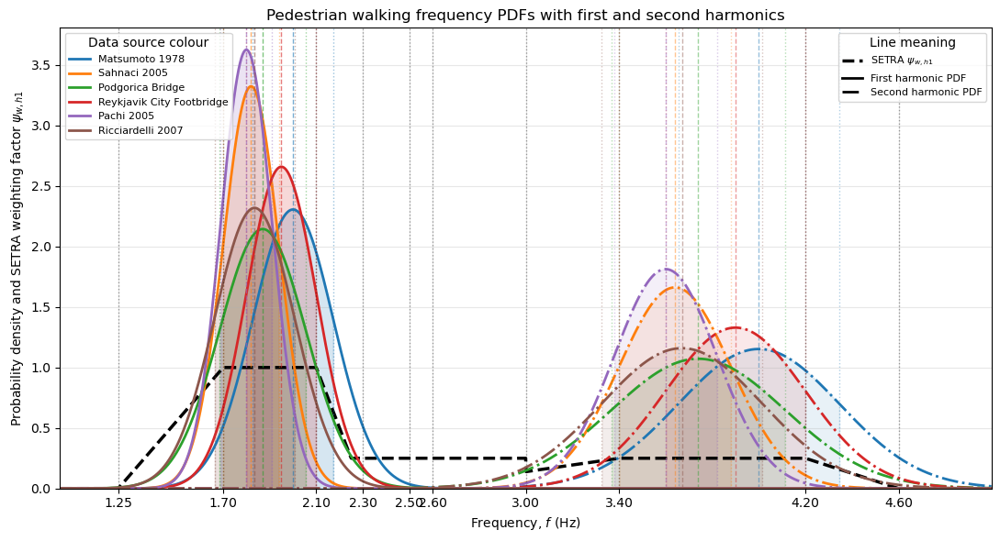

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --------------------------------------------------
# Normal distribution data
# --------------------------------------------------

data = [
    {"label": "Matsumoto 1978",              "mean": 2.000, "sd": 0.173},
    {"label": "Sahnaci 2005",                "mean": 1.820, "sd": 0.120},
    {"label": "Podgorica Bridge",            "mean": 1.870, "sd": 0.186},
    {"label": "Reykjavik City Footbridge",   "mean": 1.950, "sd": 0.150},
    {"label": "Pachi 2005",                  "mean": 1.800, "sd": 0.110},
    {"label": "Ricciardelli 2007",           "mean": 1.835, "sd": 0.172},
]

def normal_pdf(x, mean, sd):
    return (1 / (sd * np.sqrt(2 * np.pi))) * np.exp(
        -0.5 * ((x - mean) / sd) ** 2
    )

# --------------------------------------------------
# SETRA psi function
# --------------------------------------------------

def psi_w_h1(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Minimum rule between 2.25 and 3.0 Hz
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi

# --------------------------------------------------
# Frequency range
# --------------------------------------------------

x = np.linspace(1.0, 5.0, 2000)
psi_vals = psi_w_h1(x)

# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

# --------------------------------------------------
# SETRA psi line
# --------------------------------------------------

psi_line, = ax.plot(
    x,
    psi_vals,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=r"SETRA $\psi_{w,h1}$"
)

# --------------------------------------------------
# Plot first and second harmonic PDFs
# --------------------------------------------------

source_handles = []

for item in data:
    label = item["label"]

    mean_1 = item["mean"]
    sd_1 = item["sd"]

    mean_2 = 2.0 * mean_1
    sd_2 = 2.0 * sd_1

    # First harmonic PDF
    y1 = normal_pdf(x, mean_1, sd_1)

    line1, = ax.plot(
        x,
        y1,
        linewidth=2,
        linestyle="-",
        label=label
    )

    line_color = line1.get_color()

    # Save source colour for separate legend
    source_handles.append(
        Line2D(
            [0], [0],
            color=line_color,
            linewidth=2,
            label=label
        )
    )

    # Shade first harmonic mean ± 1 sigma
    m1_sigma = (x >= mean_1 - sd_1) & (x <= mean_1 + sd_1)

    ax.fill_between(
        x[m1_sigma],
        0,
        y1[m1_sigma],
        color=line_color,
        alpha=0.18
    )

    # First harmonic mean and ±1 sigma lines
    ax.axvline(mean_1, linestyle="--", linewidth=1, color=line_color, alpha=0.60)
    ax.axvline(mean_1 - sd_1, linestyle=":", linewidth=1, color=line_color, alpha=0.45)
    ax.axvline(mean_1 + sd_1, linestyle=":", linewidth=1, color=line_color, alpha=0.45)

    # Second harmonic PDF
    y2 = normal_pdf(x, mean_2, sd_2)

    ax.plot(
        x,
        y2,
        linewidth=2,
        linestyle="-.",
        color=line_color
    )

    # Shade second harmonic mean ± 1 sigma
    m2_sigma = (x >= mean_2 - sd_2) & (x <= mean_2 + sd_2)

    ax.fill_between(
        x[m2_sigma],
        0,
        y2[m2_sigma],
        color=line_color,
        alpha=0.10
    )

    # Second harmonic mean and ±1 sigma lines
    ax.axvline(mean_2, linestyle="--", linewidth=1, color=line_color, alpha=0.45)
    ax.axvline(mean_2 - sd_2, linestyle=":", linewidth=1, color=line_color, alpha=0.35)
    ax.axvline(mean_2 + sd_2, linestyle=":", linewidth=1, color=line_color, alpha=0.35)

# --------------------------------------------------
# Vertical frequency markers
# --------------------------------------------------

x_ticks = [1.25, 1.70, 2.10, 2.30, 2.50, 2.60, 3.00, 3.40, 4.20, 4.60]

for freq in x_ticks:
    ax.axvline(
        freq,
        linestyle=":",
        linewidth=1,
        color="black",
        alpha=0.35
    )

ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{v:.2f}" for v in x_ticks])

# --------------------------------------------------
# Legends
# --------------------------------------------------

harmonic_handles = [
    Line2D([0], [0], color="black", linestyle="--", linewidth=2.5,
           label=r"SETRA $\psi_{w,h1}$"),
    Line2D([0], [0], color="black", linestyle="-", linewidth=2,
           label="First harmonic PDF"),
    Line2D([0], [0], color="black", linestyle="-.", linewidth=2,
           label="Second harmonic PDF"),
]

legend1 = ax.legend(
    handles=harmonic_handles,
    fontsize=8,
    loc="upper right",
    frameon=True,
    title="Line meaning"
)

ax.add_artist(legend1)

ax.legend(
    handles=source_handles,
    fontsize=8,
    loc="upper left",
    frameon=True,
    title="Data source colour"
)

# --------------------------------------------------
# Formatting
# --------------------------------------------------

ax.set_xlabel("Frequency, $f$ (Hz)")
ax.set_ylabel(r"Probability density and SETRA weighting factor $\psi_{w,h1}$")
ax.set_title("Pedestrian walking frequency PDFs with first and second harmonics")

ax.set_xlim(1.0, 5.0)
ax.set_ylim(bottom=0)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# --------------------------------------------------
# INVERSE TABLE:
# For each target excitation/coupled frequency f_exc,
# find the empty bridge frequency f0 such that:
#
#       f_eff(f0, mass_ratio, damping) = f_exc
#
# This is the correct table for:
# "what f0 will reduce to this excitation frequency and resonate?"
# --------------------------------------------------

KEY_EXC_FREQS = [1.25, 1.70, 2.10, 2.30, 2.50, 2.60, 3.00, 3.40, 4.20, 4.60]

DAMPINGS_TO_REPORT = [0.005, 0.010, 0.020]

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

inverse_rows = []

for damping in DAMPINGS_TO_REPORT:

    damp_key = round(damping, 3)

    for density in sorted(feff_df["density_key"].dropna().unique()):

        sub = feff_df[
            np.isclose(feff_df["damping_key"], damp_key) &
            np.isclose(feff_df["density_key"], density)
        ].copy()

        if sub.empty:
            continue

        # Average repeated simulations at each f0
        feff_map_density = (
            sub
            .groupby("bridge_frequency")["f_eff_peak"]
            .mean()
            .reset_index()
            .sort_values("bridge_frequency")
        )

        f0_grid = feff_map_density["bridge_frequency"].values
        feff_grid = feff_map_density["f_eff_peak"].values

        # Build inverse map: f_eff -> f0
        inverse_map = pd.DataFrame({
            "f_eff": feff_grid,
            "f0": f0_grid
        }).dropna()

        # Sort by f_eff because np.interp needs increasing x values
        inverse_map = inverse_map.sort_values("f_eff")

        # If duplicate f_eff values exist, average corresponding f0 values
        inverse_map = (
            inverse_map
            .groupby("f_eff", as_index=False)["f0"]
            .mean()
            .sort_values("f_eff")
        )

        feff_unique = inverse_map["f_eff"].values
        f0_required_grid = inverse_map["f0"].values

        mass_ratio = density_to_mass_ratio.get(round(float(density), 4), np.nan)

        for f_exc in KEY_EXC_FREQS:

            # Find f0 such that f_eff(f0) = f_exc
            f0_required = np.interp(
                f_exc,
                feff_unique,
                f0_required_grid,
                left=np.nan,
                right=np.nan
            )

            inverse_rows.append({
                "damping": damping,
                "density": round(float(density), 4),
                "mass_ratio": mass_ratio,
                "target_excitation_or_feff": f_exc,
                "required_empty_bridge_frequency_f0": f0_required,
            })

inverse_f0_table = pd.DataFrame(inverse_rows)

print("\nInverse table:")
print("For each target excitation frequency f_exc, this gives f0 such that f_eff(f0) ≈ f_exc.")
print(inverse_f0_table.round(4).to_string(index=False))

# Save long-format table
inverse_f0_table.to_csv("inverse_feff_to_f0_all_mass_ratios.csv", index=False)


Inverse table:
For each target excitation frequency f_exc, this gives f0 such that f_eff(f0) ≈ f_exc.
 damping  density  mass_ratio  target_excitation_or_feff  required_empty_bridge_frequency_f0
   0.005   0.0333        0.01                       1.25                              1.2562
   0.005   0.0333        0.01                       1.70                              1.7100
   0.005   0.0333        0.01                       2.10                              2.1150
   0.005   0.0333        0.01                       2.30                              2.3177
   0.005   0.0333        0.01                       2.50                              2.5200
   0.005   0.0333        0.01                       2.60                              2.6210
   0.005   0.0333        0.01                       3.00                              3.0173
   0.005   0.0333        0.01                       3.40                              3.4038
   0.005   0.0333        0.01                       4.20    

In [27]:
# --------------------------------------------------
# PIVOT TABLES:
# rows = target excitation/coupled frequency
# columns = mass ratio
# values = required empty bridge frequency f0
# --------------------------------------------------

for damping in DAMPINGS_TO_REPORT:

    damp_sub = inverse_f0_table[
        np.isclose(inverse_f0_table["damping"], damping)
    ].copy()

    pivot = damp_sub.pivot_table(
        index="target_excitation_or_feff",
        columns="mass_ratio",
        values="required_empty_bridge_frequency_f0"
    )

    print("\n" + "=" * 80)
    print(f"Required empty bridge frequency f0 for damping = {damping:.3f}")
    print("Rows: target excitation / coupled resonance frequency")
    print("Columns: mass ratio")
    print(pivot.round(3))

    pivot.to_csv(f"inverse_feff_to_f0_pivot_damping{damping:.3f}.csv")


Required empty bridge frequency f0 for damping = 0.005
Rows: target excitation / coupled resonance frequency
Columns: mass ratio
mass_ratio                  0.01   0.05   0.10   0.15   0.20   0.25   0.30
target_excitation_or_feff                                                 
1.25                       1.256  1.289  1.322  1.355  1.391  1.422  1.452
1.70                       1.710  1.761  1.814  1.865  1.921  1.970  2.017
2.10                       2.115  2.189  2.267  2.342  2.425  2.497  2.568
2.30                       2.318  2.407  2.500  2.594  2.696  2.785  2.872
2.50                       2.520  2.624  2.738  2.854  2.983  3.097  3.207
2.60                       2.621  2.732  2.857  2.987  3.133  3.262  3.389
3.00                       3.017  3.115  3.248  3.329  3.380  3.406  3.431
3.40                       3.404  3.405  3.363  3.342  3.389  3.413  3.437
4.20                       4.193  4.150  4.084  3.993  3.847  3.654  3.449
4.60                       4.593  4.552  4.49

Original psi values at key f_eff points:
f_eff = 1.25 Hz -> psi = 0.000
f_eff = 1.70 Hz -> psi = 1.000
f_eff = 2.10 Hz -> psi = 1.000
f_eff = 2.30 Hz -> psi = 0.250
f_eff = 2.50 Hz -> psi = 0.250
f_eff = 2.60 Hz -> psi = 0.250
f_eff = 3.00 Hz -> psi = 0.250
f_eff = 3.40 Hz -> psi = 0.250
f_eff = 4.20 Hz -> psi = 0.250
f_eff = 4.60 Hz -> psi = 0.000


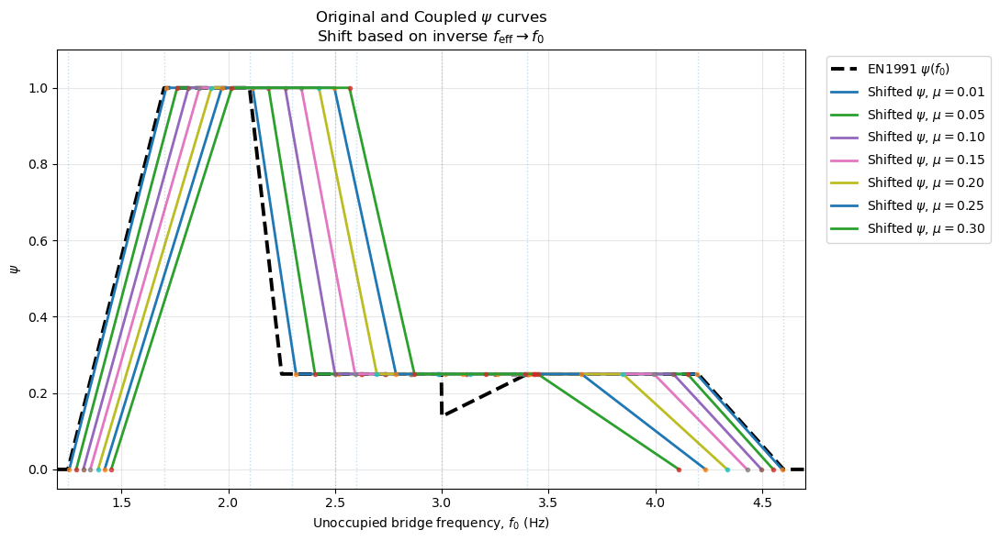

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# SETTINGS
# ==================================================

DAMPING_TO_PLOT = 0.005   # change to 0.010 or 0.020
SAVE_PLOT = False

MASS_RATIOS_TO_PLOT = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# These are the target f_eff / excitation frequencies used in your inverse table
KEY_FEFF_POINTS = np.array([1.25, 1.70, 2.10, 2.30, 2.50, 2.60, 3.00, 3.40, 4.20, 4.60])

# Smooth x-axis in terms of empty bridge frequency f0
x_plot = np.linspace(1.20, 4.70, 1500)


# ==================================================
# ORIGINAL SETRA psi FUNCTION
# ==================================================

def psi_w_h1(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Minimum rule between 2.25 and 3.0 Hz
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# ORIGINAL psi VALUES AT THE KEY f_eff POINTS
# ==================================================

psi_key_values = psi_w_h1(KEY_FEFF_POINTS)

print("Original psi values at key f_eff points:")
for f, p in zip(KEY_FEFF_POINTS, psi_key_values):
    print(f"f_eff = {f:.2f} Hz -> psi = {p:.3f}")


# ==================================================
# PLOT ORIGINAL AND SHIFTED CURVES
# ==================================================

plt.figure(figsize=(11, 6))

# Original psi curve on unshifted f0 axis
psi_original = psi_w_h1(x_plot)

plt.plot(
    x_plot,
    psi_original,
    linestyle="--",
    linewidth=2.8,
    color="black",
    label=r"EN1991 $\psi(f_0)$"
)

# Shifted curves
for mr in MASS_RATIOS_TO_PLOT:

    sub = inverse_f0_table[
        np.isclose(inverse_f0_table["damping"], DAMPING_TO_PLOT) &
        np.isclose(inverse_f0_table["mass_ratio"], mr)
    ].copy()

    if sub.empty:
        print(f"No inverse data for damping={DAMPING_TO_PLOT:.3f}, mass ratio={mr:.2f}")
        continue

    sub = sub.sort_values("target_excitation_or_feff")

    # x locations after shifting:
    # these are f0 values such that f_eff(f0) = key f_eff
    shifted_f0 = sub["required_empty_bridge_frequency_f0"].to_numpy(dtype=float)
    target_feff = sub["target_excitation_or_feff"].to_numpy(dtype=float)

    # Evaluate original psi at the target f_eff values
    shifted_psi_values = psi_w_h1(target_feff)

    # Sort by shifted f0 for interpolation
    order = np.argsort(shifted_f0)
    shifted_f0 = shifted_f0[order]
    shifted_psi_values = shifted_psi_values[order]

    # Interpolate shifted curve on smooth f0 axis
    psi_shifted = np.interp(
        x_plot,
        shifted_f0,
        shifted_psi_values,
        left=np.nan,
        right=np.nan
    )

    plt.plot(
        x_plot,
        psi_shifted,
        linewidth=2,
        label=rf"Shifted $\psi$, $\mu={mr:.2f}$"
    )

    # Optional markers showing shifted breakpoint locations
    plt.plot(
        shifted_f0,
        shifted_psi_values,
        "o",
        markersize=3,
        alpha=0.7
    )

# Original SETRA breakpoints
for f in KEY_FEFF_POINTS:
    plt.axvline(f, linestyle=":", linewidth=1, alpha=0.25)

plt.xlabel(r"Unoccupied bridge frequency, $f_0$ (Hz)")
plt.ylabel(r"$\psi$")
plt.title(
    r"Original and Coupled $\psi$ curves"
    "\n"
    rf"Shift based on inverse $f_{{\mathrm{{eff}}}}\rightarrow f_0$"
)

plt.xlim(1.20, 4.70)
plt.ylim(-0.05, 1.10)

plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

if SAVE_PLOT:
    outname = f"shifted_SETRA_psi_curves_damping{DAMPING_TO_PLOT:.3f}.png"
    plt.savefig(outname, dpi=300, bbox_inches="tight")
    print("Saved:", outname)

plt.show()

Original psi values at key f_eff points:
f_eff = 1.25 Hz -> psi = 0.000
f_eff = 1.70 Hz -> psi = 1.000
f_eff = 2.10 Hz -> psi = 1.000
f_eff = 2.30 Hz -> psi = 0.250
f_eff = 2.50 Hz -> psi = 0.250
f_eff = 2.60 Hz -> psi = 0.250
f_eff = 3.00 Hz -> psi = 0.250
f_eff = 3.40 Hz -> psi = 0.250
f_eff = 4.20 Hz -> psi = 0.250
f_eff = 4.60 Hz -> psi = 0.000


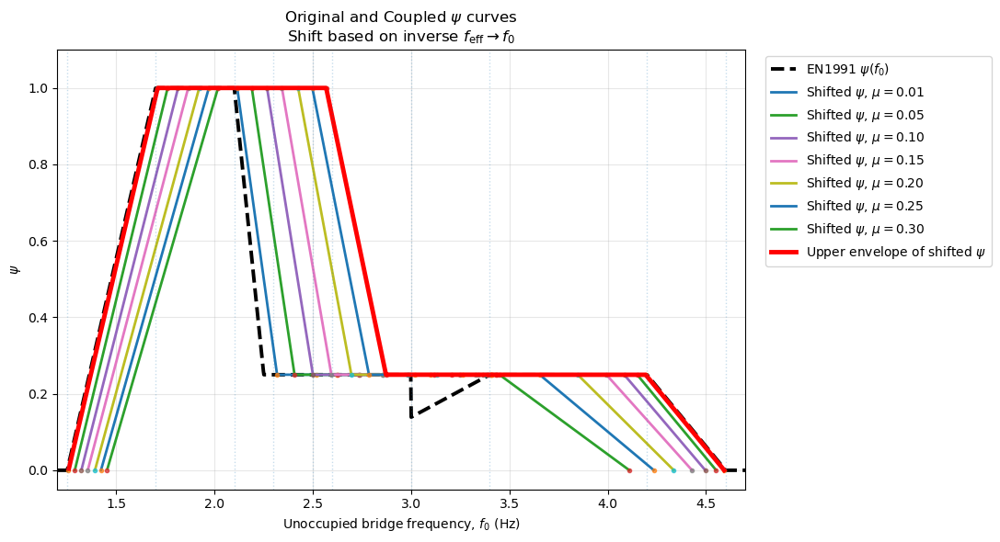


Piecewise equation for upper envelope of shifted psi:
--------------------------------------------------
1.258 <= f0 <= 1.709: psi_env = 2.2039 f0 - 2.7686
1.709 <= f0 <= 1.711: psi_env = 0.9382 f0 - 0.6056
1.711 <= f0 <= 2.566: psi_env = 1.000
2.566 <= f0 <= 2.568: psi_env = -0.6319 f0 + 2.6213
2.568 <= f0 <= 2.872: psi_env = -2.4653 f0 + 7.3299
2.872 <= f0 <= 2.874: psi_env = -0.0991 f0 + 0.5347
2.874 <= f0 <= 4.191: psi_env = 0.250
4.191 <= f0 <= 4.193: psi_env = -0.0880 f0 + 0.6190
4.193 <= f0 <= 4.593: psi_env = -0.6250 f0 + 2.8706


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# SETTINGS
# ==================================================

DAMPING_TO_PLOT = 0.005   # change to 0.010 or 0.020
SAVE_PLOT = False

MASS_RATIOS_TO_PLOT = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# These are the target f_eff / excitation frequencies used in your inverse table
KEY_FEFF_POINTS = np.array([1.25, 1.70, 2.10, 2.30, 2.50, 2.60, 3.00, 3.40, 4.20, 4.60])

# Smooth x-axis in terms of empty bridge frequency f0
x_plot = np.linspace(1.20, 4.70, 1500)


# ==================================================
# ORIGINAL SETRA psi FUNCTION
# ==================================================

def psi_w_h1(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Minimum rule between 2.25 and 3.0 Hz
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# ORIGINAL psi VALUES AT THE KEY f_eff POINTS
# ==================================================

psi_key_values = psi_w_h1(KEY_FEFF_POINTS)

print("Original psi values at key f_eff points:")
for f, p in zip(KEY_FEFF_POINTS, psi_key_values):
    print(f"f_eff = {f:.2f} Hz -> psi = {p:.3f}")


# ==================================================
# PLOT ORIGINAL AND SHIFTED CURVES
# ==================================================

plt.figure(figsize=(11, 6))

# Original psi curve on unshifted f0 axis
psi_original = psi_w_h1(x_plot)

plt.plot(
    x_plot,
    psi_original,
    linestyle="--",
    linewidth=2.8,
    color="black",
    label=r"EN1991 $\psi(f_0)$"
)

# Store shifted psi curves for envelope calculation
shifted_curves = []
shifted_curve_labels = []
# Shifted curves
for mr in MASS_RATIOS_TO_PLOT:

    sub = inverse_f0_table[
        np.isclose(inverse_f0_table["damping"], DAMPING_TO_PLOT) &
        np.isclose(inverse_f0_table["mass_ratio"], mr)
    ].copy()

    if sub.empty:
        print(f"No inverse data for damping={DAMPING_TO_PLOT:.3f}, mass ratio={mr:.2f}")
        continue

    sub = sub.sort_values("target_excitation_or_feff")

    # x locations after shifting:
    # these are f0 values such that f_eff(f0) = key f_eff
    shifted_f0 = sub["required_empty_bridge_frequency_f0"].to_numpy(dtype=float)
    target_feff = sub["target_excitation_or_feff"].to_numpy(dtype=float)

    # Evaluate original psi at the target f_eff values
    shifted_psi_values = psi_w_h1(target_feff)

    # Sort by shifted f0 for interpolation
    order = np.argsort(shifted_f0)
    shifted_f0 = shifted_f0[order]
    shifted_psi_values = shifted_psi_values[order]

    # Interpolate shifted curve on smooth f0 axis
    psi_shifted = np.interp(
        x_plot,
        shifted_f0,
        shifted_psi_values,
        left=np.nan,
        right=np.nan
    )
    # Store this shifted curve for envelope
    shifted_curves.append(psi_shifted)
    shifted_curve_labels.append(mr)

    plt.plot(
        x_plot,
        psi_shifted,
        linewidth=2,
        label=rf"Shifted $\psi$, $\mu={mr:.2f}$"
    )

    # Optional markers showing shifted breakpoint locations
    plt.plot(
        shifted_f0,
        shifted_psi_values,
        "o",
        markersize=3,
        alpha=0.7
    )


# ==================================================
# ENVELOPE OF SHIFTED psi CURVES
# ==================================================

# ==================================================
# UPPER ENVELOPE OF SHIFTED psi CURVES ONLY
# ==================================================

if len(shifted_curves) > 0:

    shifted_curves_array = np.vstack(shifted_curves)

    # Valid where at least one shifted curve exists
    valid = np.any(np.isfinite(shifted_curves_array), axis=0)

    psi_upper_envelope = np.full_like(x_plot, np.nan, dtype=float)

    # Upper envelope only
    psi_upper_envelope[valid] = np.nanmax(
        shifted_curves_array[:, valid],
        axis=0
    )

    # Plot upper envelope only
    plt.plot(
        x_plot,
        psi_upper_envelope,
        color="red",
        linewidth=3.5,
        linestyle="-",
        label=r"Upper envelope of shifted $\psi$"
    )
    
# Original SETRA breakpoints
for f in KEY_FEFF_POINTS:
    plt.axvline(f, linestyle=":", linewidth=1, alpha=0.25)

plt.xlabel(r"Unoccupied bridge frequency, $f_0$ (Hz)")
plt.ylabel(r"$\psi$")
plt.title(
    r"Original and Coupled $\psi$ curves"
    "\n"
    rf"Shift based on inverse $f_{{\mathrm{{eff}}}}\rightarrow f_0$"
)

plt.xlim(1.20, 4.70)
plt.ylim(-0.05, 1.10)

plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

if SAVE_PLOT:
    outname = f"shifted_SETRA_psi_curves_damping{DAMPING_TO_PLOT:.3f}.png"
    plt.savefig(outname, dpi=300, bbox_inches="tight")
    print("Saved:", outname)

plt.show()


# ==================================================
# PRINT APPROXIMATE PIECEWISE-LINEAR EQUATION
# FOR THE UPPER ENVELOPE
# ==================================================

def simplify_piecewise_linear(x, y, slope_tol=1e-3):
    """
    Simplifies a piecewise-linear curve by keeping points where the slope changes.
    Returns breakpoints suitable for writing y = m f0 + c between points.
    """

    mask = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x[mask], dtype=float)
    y = np.asarray(y[mask], dtype=float)

    if len(x) < 2:
        return x, y

    # Remove repeated x values
    keep = np.r_[True, np.diff(x) > 1e-10]
    x = x[keep]
    y = y[keep]

    slopes = np.diff(y) / np.diff(x)

    keep_idx = [0]

    for i in range(1, len(slopes)):
        if abs(slopes[i] - slopes[i - 1]) > slope_tol:
            keep_idx.append(i)

    keep_idx.append(len(x) - 1)

    keep_idx = np.unique(keep_idx)

    return x[keep_idx], y[keep_idx]


# Simplify envelope
x_env_pts, y_env_pts = simplify_piecewise_linear(
    x_plot,
    psi_upper_envelope,
    slope_tol=2e-3
)

print("\nPiecewise equation for upper envelope of shifted psi:")
print("--------------------------------------------------")

for i in range(len(x_env_pts) - 1):

    f1 = x_env_pts[i]
    f2 = x_env_pts[i + 1]
    p1 = y_env_pts[i]
    p2 = y_env_pts[i + 1]

    if abs(f2 - f1) < 1e-12:
        continue

    m = (p2 - p1) / (f2 - f1)
    c = p1 - m * f1

    if abs(m) < 1e-6:
        print(
            rf"{f1:.3f} <= f0 <= {f2:.3f}: "
            rf"psi_env = {p1:.3f}"
        )
    else:
        sign = "+" if c >= 0 else "-"
        print(
            rf"{f1:.3f} <= f0 <= {f2:.3f}: "
            rf"psi_env = {m:.4f} f0 {sign} {abs(c):.4f}"
        )